In [2]:
import pickle
from pathlib import Path
import pandas as pd
import numpy as np
import torch.nn as nn

from neuralhydrology.utils.config import Config

import matplotlib.pyplot as plt
import torch
from neuralhydrology.evaluation import metrics
from neuralhydrology.nh_run import start_run, eval_run

from neuralhydrology.evaluation.metrics import nse
import xarray as xr

# dCFE and Snow-dCFE (need work)

# Snow dCFE (Need Fixing)

## Ratio of NSE for Snow-dCFE
Experiements are ran over the `full_basin.txt` basins at daily increments under the dynamic parameters, oracle average parameters, and operational average parameters setting. The results are under the folders:

* `full_basin_snow_dcfe_dynamic_0304_175915`
* tbd
* `full_basin_snow_dcfe_operational_0704_111017`

They are already evaluated on HPC. There are some issues with how NH evaluates NSE from `predict_last_n: 365` setting and we will demonstrate this and fix this issue by sticking four sequences of length 365 predicted flows together. 
### Load Results & Wrong NSE

In [1]:
dynamic_path = Path("runs/full_basin_snow_dcfe_dynamic_0304_175915")
#oracle_path = Path("runs/EXP1_CAMELS_noSnow_HPC_OracleAvg_1612_172828")
operational_path = Path("runs/full_basin_snow_dcfe_operational_0704_111017")

dynamic_NSE = pd.read_csv(dynamic_path / "test" / "model_epoch030" / "test_metrics.csv", index_col=0)
#oracle_NSE = pd.read_csv(oracle_path / "test" / "model_epoch030" / "test_metrics.csv", index_col=0)
operational_NSE = pd.read_csv(operational_path / "test" / "model_epoch030" / "test_metrics.csv", index_col=0)

fig, ax = plt.subplots(1, 3, figsize=(16,4))
ax[0].plot(dynamic_NSE['NSE'], oracle_NSE['NSE'], 'o')
ax[0].set_title("Dynamic vs Oracle Mode NSE")
ax[0].set_xlabel("Dynamic Mode NSE")
ax[0].set_ylabel("Oracle Mode NSE")
lims0 = [np.min([ax[0].get_xlim(), ax[0].get_ylim()]), np.max([ax[0].get_xlim(), ax[0].get_ylim()])]
ax[0].plot(lims0, lims0, 'k--', alpha=0.75, zorder=0)

ax[1].plot(dynamic_NSE['NSE'], operational_NSE['NSE'], 'o')
ax[1].set_title("Dynamic vs Operational Mode NSE")
ax[1].set_xlabel("Dynamic Mode NSE")
ax[1].set_ylabel("Operational Mode NSE")
lims1 = [np.min([ax[1].get_xlim(), ax[1].get_ylim()]), np.max([ax[1].get_xlim(), ax[1].get_ylim()])]
ax[1].plot(lims1, lims1, 'k--', alpha=0.75, zorder=0)

ax[2].plot(oracle_NSE['NSE'], operational_NSE['NSE'], 'o')
ax[2].set_title("Oracle vs Operational Mode NSE")
ax[2].set_xlabel("Oracle Mode NSE")
ax[2].set_ylabel("Operational Mode NSE")
lims2 = [np.min([ax[2].get_xlim(), ax[2].get_ylim()]), np.max([ax[2].get_xlim(), ax[2].get_ylim()])]
ax[2].plot(lims2, lims2, 'k--', alpha=0.75, zorder=0)

NameError: name 'Path' is not defined

In [32]:
with open(dynamic_path / "test" / "model_epoch030" / "test_results.p", "rb") as fp:
    dynamic_results = pickle.load(fp)
with open(oracle_path / "test" / "model_epoch030" / "test_results.p", "rb") as fp:
    oracle_results = pickle.load(fp)
with open(operational_path / "test" / "model_epoch030" / "test_results.p", "rb") as fp:
    operational_results = pickle.load(fp)

Text(0.5, 1.0, 'Dynamic, 30 epoch, Basin 08070000 - NSE 0.616')

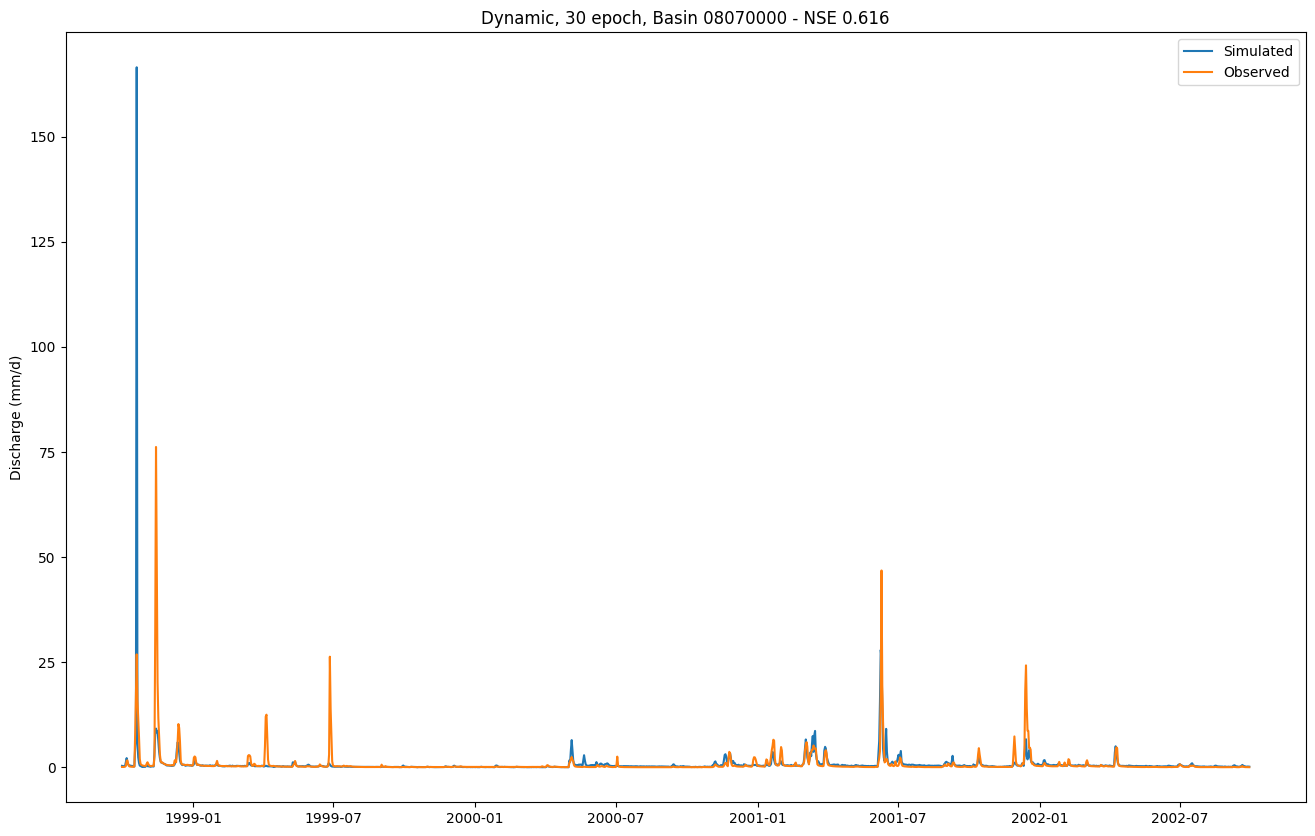

In [4]:
# Stitch them together
basin = '08070000' #'08202700' #'02231000' #'08202700'

dynamic_agg_sim = np.hstack([dynamic_results[basin]['1D']['xr']['QObs(mm/d)_sim'][0], 
         dynamic_results[basin]['1D']['xr']['QObs(mm/d)_sim'][365],
         dynamic_results[basin]['1D']['xr']['QObs(mm/d)_sim'][365*2],
         dynamic_results[basin]['1D']['xr']['QObs(mm/d)_sim'][365*3]])
dynamic_agg_obs = np.hstack([dynamic_results[basin]['1D']['xr']['QObs(mm/d)_obs'][0],
            dynamic_results[basin]['1D']['xr']['QObs(mm/d)_obs'][365],
            dynamic_results[basin]['1D']['xr']['QObs(mm/d)_obs'][365*2],
            dynamic_results[basin]['1D']['xr']['QObs(mm/d)_obs'][365*3]])
dynamic_dates = pd.date_range(start='1998-10-01', periods=len(dynamic_agg_obs), freq='D')
fig, ax = plt.subplots(figsize=(16,10))
ax.plot(dynamic_dates, dynamic_agg_sim, label='Simulated')
ax.plot(dynamic_dates, dynamic_agg_obs, label='Observed')
ax.legend()
ax.set_ylabel("Discharge (mm/d)")
ax.set_title(f"Dynamic, 30 epoch, Basin {basin} - NSE {dynamic_results[basin]['1D']['NSE']:.3f}")

In [5]:
nse(xr.DataArray(dynamic_agg_obs), xr.DataArray(dynamic_agg_sim))

-0.7184476852416992

The NSE is not close: -8.379 vs -6.670

Text(0.5, 1.0, 'Oracle, 30 epoch, Basin 08070000 - NSE 0.398')

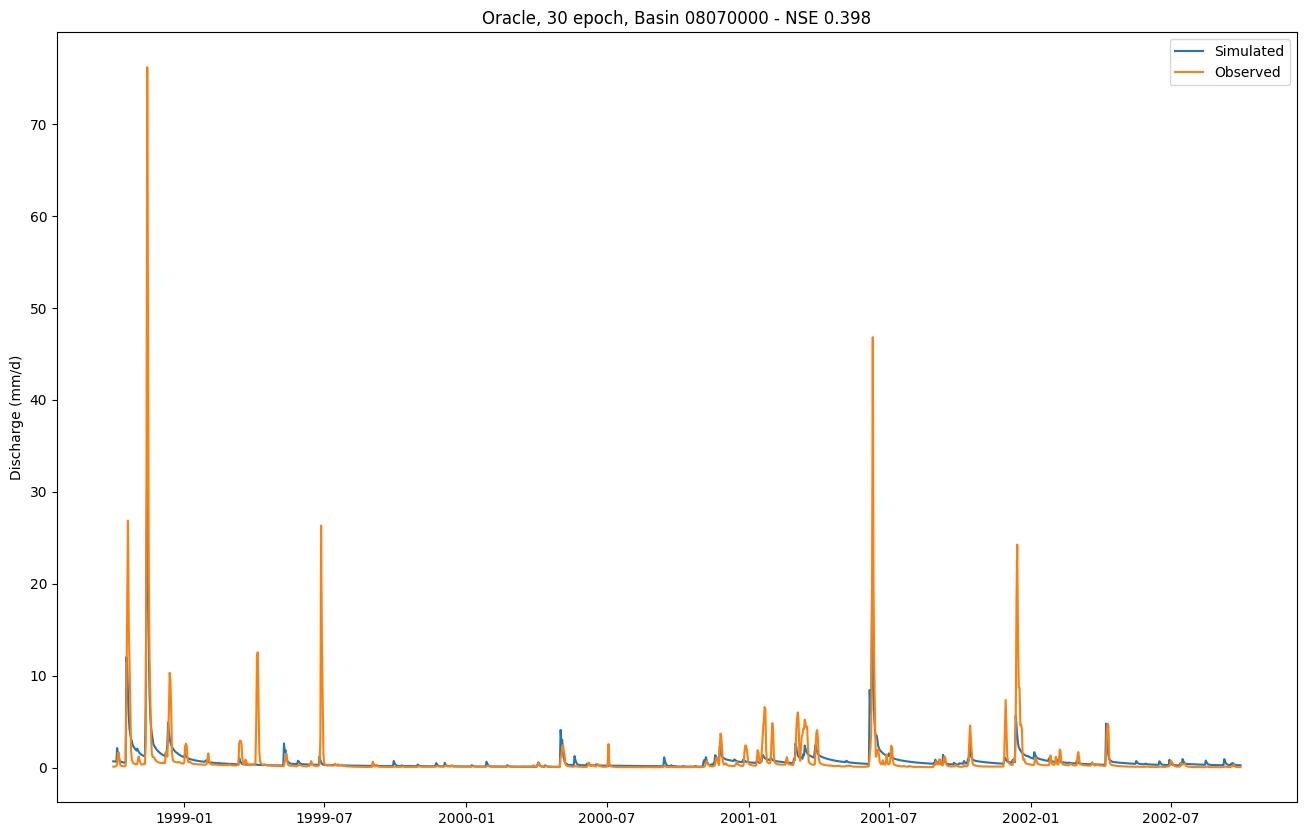

In [6]:
basin = '08070000' #'02231000'

oracle_agg_sim = xr.DataArray(
    np.hstack(
        [oracle_results[basin]['1D']['xr']['QObs(mm/d)_sim'][0], 
         oracle_results[basin]['1D']['xr']['QObs(mm/d)_sim'][365],
         oracle_results[basin]['1D']['xr']['QObs(mm/d)_sim'][365*2],
         oracle_results[basin]['1D']['xr']['QObs(mm/d)_sim'][365*3]]
        )
)
oracle_agg_obs = xr.DataArray(
    np.hstack(
        [oracle_results[basin]['1D']['xr']['QObs(mm/d)_obs'][0],
         oracle_results[basin]['1D']['xr']['QObs(mm/d)_obs'][365],
         oracle_results[basin]['1D']['xr']['QObs(mm/d)_obs'][365*2],
         oracle_results[basin]['1D']['xr']['QObs(mm/d)_obs'][365*3]]
        )
)
oracle_dates = pd.date_range(start='1998-10-01', periods=len(oracle_agg_obs), freq='D')
fig, ax = plt.subplots(figsize=(16,10))
ax.plot(oracle_dates, oracle_agg_sim, label='Simulated')
ax.plot(oracle_dates, oracle_agg_obs, label='Observed')
ax.legend()
ax.set_ylabel("Discharge (mm/d)")
ax.set_title(f"Oracle, 30 epoch, Basin {basin} - NSE {oracle_results[basin]['1D']['NSE']:.3f}")

In [7]:
nse(oracle_agg_obs, oracle_agg_sim)

0.5639779269695282

The NSE is not close here either: -0.639 vs 0.436

## Calculate Correct NSE
We will calculate the correct NSEs for the above methods for each basin. 

In [33]:
basin_keys = list(dynamic_results.keys())

# Create dictionary to store results
nse_results = {'basin': [], 'dynamic_nse': [], 'oracle_nse': [], 'operational_nse': []}

# Dynamic Mode
for basin in basin_keys:
    dynamic_agg_sim = np.hstack([dynamic_results[basin]['1D']['xr']['QObs(mm/d)_sim'][0], 
             dynamic_results[basin]['1D']['xr']['QObs(mm/d)_sim'][365],
             dynamic_results[basin]['1D']['xr']['QObs(mm/d)_sim'][365*2],
             dynamic_results[basin]['1D']['xr']['QObs(mm/d)_sim'][365*3]])
    dynamic_agg_obs = np.hstack([dynamic_results[basin]['1D']['xr']['QObs(mm/d)_obs'][0],
                dynamic_results[basin]['1D']['xr']['QObs(mm/d)_obs'][365],
                dynamic_results[basin]['1D']['xr']['QObs(mm/d)_obs'][365*2],
                dynamic_results[basin]['1D']['xr']['QObs(mm/d)_obs'][365*3]])
    dynamic_nse = nse(xr.DataArray(dynamic_agg_obs), xr.DataArray(dynamic_agg_sim))
    
    # Oracle Mode
    oracle_agg_sim = np.hstack([oracle_results[basin]['1D']['xr']['QObs(mm/d)_sim'][0], 
             oracle_results[basin]['1D']['xr']['QObs(mm/d)_sim'][365],
             oracle_results[basin]['1D']['xr']['QObs(mm/d)_sim'][365*2],
             oracle_results[basin]['1D']['xr']['QObs(mm/d)_sim'][365*3]])
    oracle_agg_obs = np.hstack([oracle_results[basin]['1D']['xr']['QObs(mm/d)_obs'][0],
                oracle_results[basin]['1D']['xr']['QObs(mm/d)_obs'][365],
                oracle_results[basin]['1D']['xr']['QObs(mm/d)_obs'][365*2],
                oracle_results[basin]['1D']['xr']['QObs(mm/d)_obs'][365*3]])
    oracle_nse = nse(xr.DataArray(oracle_agg_obs), xr.DataArray(oracle_agg_sim))
    
    # Operational Mode
    operational_agg_sim = np.hstack([operational_results[basin]['1D']['xr']['QObs(mm/d)_sim'][0], 
             operational_results[basin]['1D']['xr']['QObs(mm/d)_sim'][365],
             operational_results[basin]['1D']['xr']['QObs(mm/d)_sim'][365*2],
             operational_results[basin]['1D']['xr']['QObs(mm/d)_sim'][365*3]])
    operational_agg_obs = np.hstack([operational_results[basin]['1D']['xr']['QObs(mm/d)_obs'][0],
                operational_results[basin]['1D']['xr']['QObs(mm/d)_obs'][365],
                operational_results[basin]['1D']['xr']['QObs(mm/d)_obs'][365*2],
                operational_results[basin]['1D']['xr']['QObs(mm/d)_obs'][365*3]])
    operational_nse = nse(xr.DataArray(operational_agg_obs), xr.DataArray(operational_agg_sim))
    
    # Append to results dictionary
    nse_results['basin'].append(basin)
    nse_results['dynamic_nse'].append(float(dynamic_nse))
    nse_results['oracle_nse'].append(float(oracle_nse))
    nse_results['operational_nse'].append(float(operational_nse))

# Convert to DataFrame with basin as index
corrected_nse_df = pd.DataFrame(nse_results).set_index('basin')
corrected_nse_df

,dynamic_nse,oracle_nse,operational_nse
basin,,,
02092500,0.327146,0.201347,0.279044
02102908,0.133567,0.251740,0.177657
02108000,0.277122,0.204706,0.328980
02193340,0.416943,0.377654,0.345422
02196000,0.544982,0.413077,0.464156
...,...,...,...
14305500,0.812326,0.756514,0.755039
14306340,0.808776,0.801302,0.796532
14306500,0.897162,0.894188,0.892076


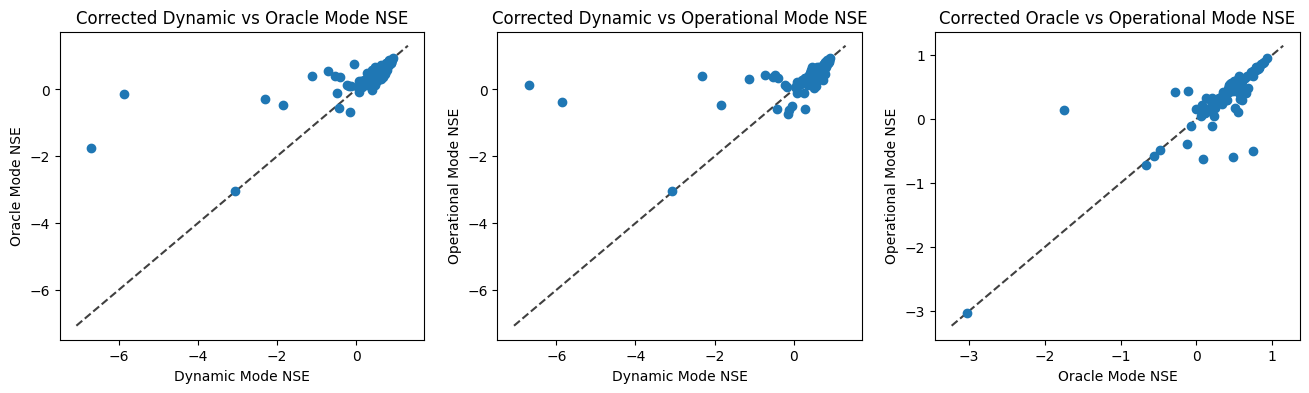

In [9]:
fig, ax = plt.subplots(1, 3, figsize=(16,4))
ax[0].plot(corrected_nse_df['dynamic_nse'], corrected_nse_df['oracle_nse'], 'o')
ax[0].set_title("Corrected Dynamic vs Oracle Mode NSE")
ax[0].set_xlabel("Dynamic Mode NSE")
ax[0].set_ylabel("Oracle Mode NSE")
lims0 = [np.min([ax[0].get_xlim(), ax[0].get_ylim()]), np.max([ax[0].get_xlim(), ax[0].get_ylim()])]
ax[0].plot(lims0, lims0, 'k--', alpha=0.75, zorder=0)

ax[1].plot(corrected_nse_df['dynamic_nse'], corrected_nse_df['operational_nse'], 'o')
ax[1].set_title("Corrected Dynamic vs Operational Mode NSE")
ax[1].set_xlabel("Dynamic Mode NSE")
ax[1].set_ylabel("Operational Mode NSE")
lims1 = [np.min([ax[1].get_xlim(), ax[1].get_ylim()]), np.max([ax[1].get_xlim(), ax[1].get_ylim()])]
ax[1].plot(lims1, lims1, 'k--', alpha=0.75, zorder=0)

ax[2].plot(corrected_nse_df['oracle_nse'], corrected_nse_df['operational_nse'], 'o')
ax[2].set_title("Corrected Oracle vs Operational Mode NSE")
ax[2].set_xlabel("Oracle Mode NSE")
ax[2].set_ylabel("Operational Mode NSE")
lims2 = [np.min([ax[2].get_xlim(), ax[2].get_ylim()]), np.max([ax[2].get_xlim(), ax[2].get_ylim()])]
ax[2].plot(lims2, lims2, 'k--', alpha=0.75, zorder=0)

## Examining Model Performance under Different Modes

In [10]:
# Examine basins with negative dynamic NSE
negative_dynamic = corrected_nse_df[corrected_nse_df['dynamic_nse'] < 0]
print(f"Number of basins with negative dynamic NSE: {len(negative_dynamic)}")
negative_oracle = corrected_nse_df[corrected_nse_df['oracle_nse'] < 0]
print(f"Number of basins with negative oracle NSE: {len(negative_oracle)}")
negative_operational = corrected_nse_df[corrected_nse_df['operational_nse'] < 0]
print(f"Number of basins with negative operational NSE: {len(negative_operational)}")
negative_dynamic

Number of basins with negative dynamic NSE: 16
Number of basins with negative oracle NSE: 10
Number of basins with negative operational NSE: 10


,dynamic_nse,oracle_nse,operational_nse
basin,,,
02202600,-0.155953,-0.666403,-0.724359
08070000,-0.718448,0.563978,0.439348
08086212,-1.124421,0.403104,0.303246
08103900,-2.310379,-0.288088,0.417139
08150800,-0.408493,0.380186,0.336059
08158700,-0.477303,-0.114913,0.444111
08176900,-0.045776,0.748950,-0.492073
08196000,-0.177278,0.095586,0.088009
08202700,-6.689700,-1.748287,0.147186


Interestingly, there are a few observations where the NSE is negative for dynamic mode but better for cle or operational mode. And one basin that performs roughly the same across all modes. There are more negative NSEs in dynamic mode. 

In [11]:
corrected_nse_df['dynamic_nse']['08070000']

-0.7184476852416992

In [ ]:
negative_oracle # 8 basins overlap with negative dynamic NSE

,dynamic_nse,oracle_nse,operational_nse
basin,,,
02202600,-0.155953,-0.666403,-0.724359
07375000,0.390056,-0.008443,0.156161
08082700,0.069758,-0.066150,-0.108458
08103900,-2.310379,-0.288088,0.417139
08158700,-0.477303,-0.114913,0.444111
08202700,-6.689700,-1.748287,0.147186
09447800,-5.864542,-0.122838,-0.382981
09510200,-0.432308,-0.560175,-0.577509
09512280,-1.839701,-0.478152,-0.478142


In [ ]:
negative_operational # 7 overlap with negative dynamic NSE

,dynamic_nse,oracle_nse,operational_nse
basin,,,
02202600,-0.155953,-0.666403,-0.724359
02246000,0.265013,0.207831,-0.100637
08082700,0.069758,-0.066150,-0.108458
08164600,0.271835,0.479358,-0.597269
08176900,-0.045776,0.748950,-0.492073
09447800,-5.864542,-0.122838,-0.382981
09508300,-0.125937,0.093260,-0.627133
09510200,-0.432308,-0.560175,-0.577509
09512280,-1.839701,-0.478152,-0.478142


### Example of Dynamic Mode worse than Averaging

Text(0, 0.5, 'Discharge (mm/d)')

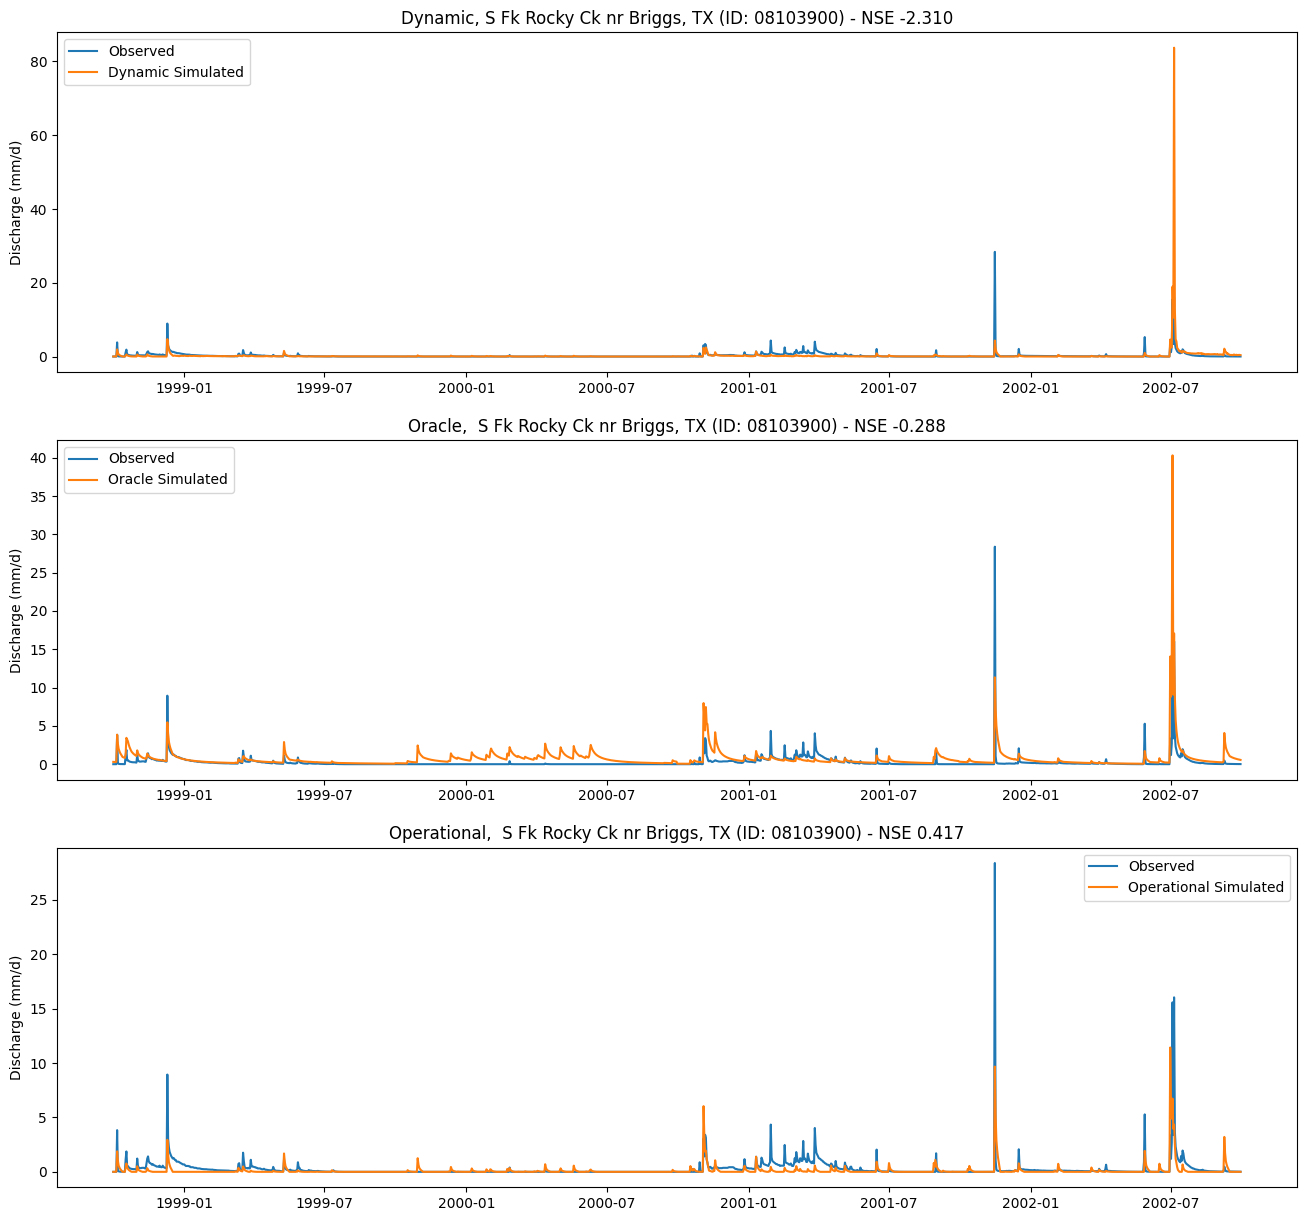

In [ ]:
basin = '08103900' # S Fk Rocky Ck nr Briggs, TX 

# dynamic
dynamic_agg_sim = xr.DataArray(
    np.hstack(
        [dynamic_results[basin]['1D']['xr']['QObs(mm/d)_sim'][0], 
         dynamic_results[basin]['1D']['xr']['QObs(mm/d)_sim'][365],
         dynamic_results[basin]['1D']['xr']['QObs(mm/d)_sim'][365*2],
         dynamic_results[basin]['1D']['xr']['QObs(mm/d)_sim'][365*3]]
        )
)
dynamic_agg_obs = xr.DataArray(
    np.hstack(
        [dynamic_results[basin]['1D']['xr']['QObs(mm/d)_obs'][0],
         dynamic_results[basin]['1D']['xr']['QObs(mm/d)_obs'][365],
         dynamic_results[basin]['1D']['xr']['QObs(mm/d)_obs'][365*2],
         dynamic_results[basin]['1D']['xr']['QObs(mm/d)_obs'][365*3]]
        )
)
# oracle
oracle_agg_sim = xr.DataArray(
    np.hstack(
        [oracle_results[basin]['1D']['xr']['QObs(mm/d)_sim'][0], 
         oracle_results[basin]['1D']['xr']['QObs(mm/d)_sim'][365],
         oracle_results[basin]['1D']['xr']['QObs(mm/d)_sim'][365*2],
         oracle_results[basin]['1D']['xr']['QObs(mm/d)_sim'][365*3]]
        )
)
# operational
operational_agg_sim = xr.DataArray(
    np.hstack(
        [operational_results[basin]['1D']['xr']['QObs(mm/d)_sim'][0], 
         operational_results[basin]['1D']['xr']['QObs(mm/d)_sim'][365],
         operational_results[basin]['1D']['xr']['QObs(mm/d)_sim'][365*2],
         operational_results[basin]['1D']['xr']['QObs(mm/d)_sim'][365*3]]
        )
)
dates = pd.date_range(start='1998-10-01', periods=len(oracle_agg_obs), freq='D')

fig, ax = plt.subplots(3, 1, figsize=(16,15))
ax[0].plot(dates, dynamic_agg_obs, label='Observed')
ax[0].plot(dates, dynamic_agg_sim, label='Dynamic Simulated')
ax[0].set_title(f"Dynamic, S Fk Rocky Ck nr Briggs, TX (ID: {basin}) - NSE {corrected_nse_df['dynamic_nse'][basin]:.3f}")
ax[0].legend()
ax[0].set_ylabel("Discharge (mm/d)")

ax[1].plot(dates, dynamic_agg_obs, label='Observed')
ax[1].plot(dates, oracle_agg_sim, label='Oracle Simulated')
ax[1].set_title(f"Oracle,  S Fk Rocky Ck nr Briggs, TX (ID: {basin}) - NSE {corrected_nse_df['oracle_nse'][basin]:.3f}")
ax[1].legend()
ax[1].set_ylabel("Discharge (mm/d)")

ax[2].plot(dates, dynamic_agg_obs, label='Observed')
ax[2].plot(dates, operational_agg_sim, label='Operational Simulated')
ax[2].set_title(f"Operational,  S Fk Rocky Ck nr Briggs, TX (ID: {basin}) - NSE {corrected_nse_df['operational_nse'][basin]:.3f}")
ax[2].legend()
ax[2].set_ylabel("Discharge (mm/d)")



### Example where all modes perform similarly

Text(0, 0.5, 'Discharge (mm/d)')

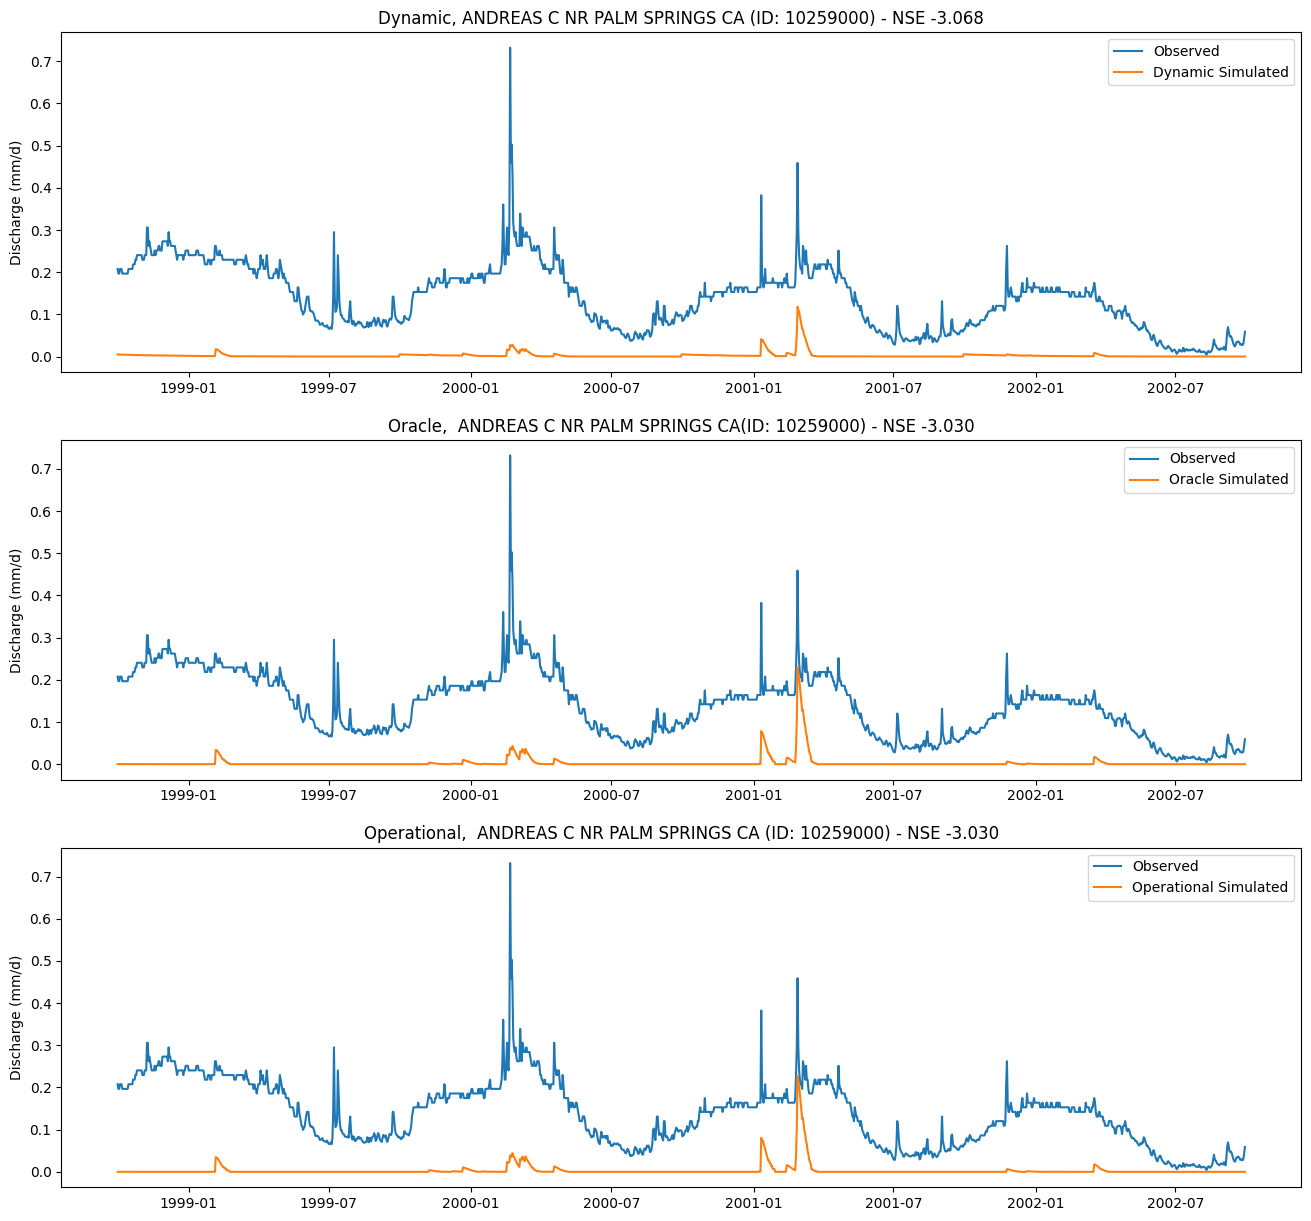

In [62]:
basin = '10259000' # ANDREAS C NR PALM SPRINGS CA

# dynamic
dynamic_agg_sim = xr.DataArray(
    np.hstack(
        [dynamic_results[basin]['1D']['xr']['QObs(mm/d)_sim'][0], 
         dynamic_results[basin]['1D']['xr']['QObs(mm/d)_sim'][365],
         dynamic_results[basin]['1D']['xr']['QObs(mm/d)_sim'][365*2],
         dynamic_results[basin]['1D']['xr']['QObs(mm/d)_sim'][365*3]]
        )
)
dynamic_agg_obs = xr.DataArray(
    np.hstack(
        [dynamic_results[basin]['1D']['xr']['QObs(mm/d)_obs'][0],
         dynamic_results[basin]['1D']['xr']['QObs(mm/d)_obs'][365],
         dynamic_results[basin]['1D']['xr']['QObs(mm/d)_obs'][365*2],
         dynamic_results[basin]['1D']['xr']['QObs(mm/d)_obs'][365*3]]
        )
)
# oracle
oracle_agg_sim = xr.DataArray(
    np.hstack(
        [oracle_results[basin]['1D']['xr']['QObs(mm/d)_sim'][0], 
         oracle_results[basin]['1D']['xr']['QObs(mm/d)_sim'][365],
         oracle_results[basin]['1D']['xr']['QObs(mm/d)_sim'][365*2],
         oracle_results[basin]['1D']['xr']['QObs(mm/d)_sim'][365*3]]
        )
)
# operational
operational_agg_sim = xr.DataArray(
    np.hstack(
        [operational_results[basin]['1D']['xr']['QObs(mm/d)_sim'][0], 
         operational_results[basin]['1D']['xr']['QObs(mm/d)_sim'][365],
         operational_results[basin]['1D']['xr']['QObs(mm/d)_sim'][365*2],
         operational_results[basin]['1D']['xr']['QObs(mm/d)_sim'][365*3]]
        )
)
dates = pd.date_range(start='1998-10-01', periods=len(oracle_agg_obs), freq='D')

fig, ax = plt.subplots(3, 1, figsize=(16,15))
ax[0].plot(dates, dynamic_agg_obs, label='Observed')
ax[0].plot(dates, dynamic_agg_sim, label='Dynamic Simulated')
ax[0].set_title(f"Dynamic, ANDREAS C NR PALM SPRINGS CA (ID: {basin}) - NSE {corrected_nse_df['dynamic_nse'][basin]:.3f}")
ax[0].legend()
ax[0].set_ylabel("Discharge (mm/d)")

ax[1].plot(dates, dynamic_agg_obs, label='Observed')
ax[1].plot(dates, oracle_agg_sim, label='Oracle Simulated')
ax[1].set_title(f"Oracle,  ANDREAS C NR PALM SPRINGS CA(ID: {basin}) - NSE {corrected_nse_df['oracle_nse'][basin]:.3f}")
ax[1].legend()
ax[1].set_ylabel("Discharge (mm/d)")

ax[2].plot(dates, dynamic_agg_obs, label='Observed')
ax[2].plot(dates, operational_agg_sim, label='Operational Simulated')
ax[2].set_title(f"Operational,  ANDREAS C NR PALM SPRINGS CA (ID: {basin}) - NSE {corrected_nse_df['operational_nse'][basin]:.3f}")
ax[2].legend()
ax[2].set_ylabel("Discharge (mm/d)")

### Example of Dynamic Mode Better than Others

Text(0, 0.5, 'Discharge (mm/d)')

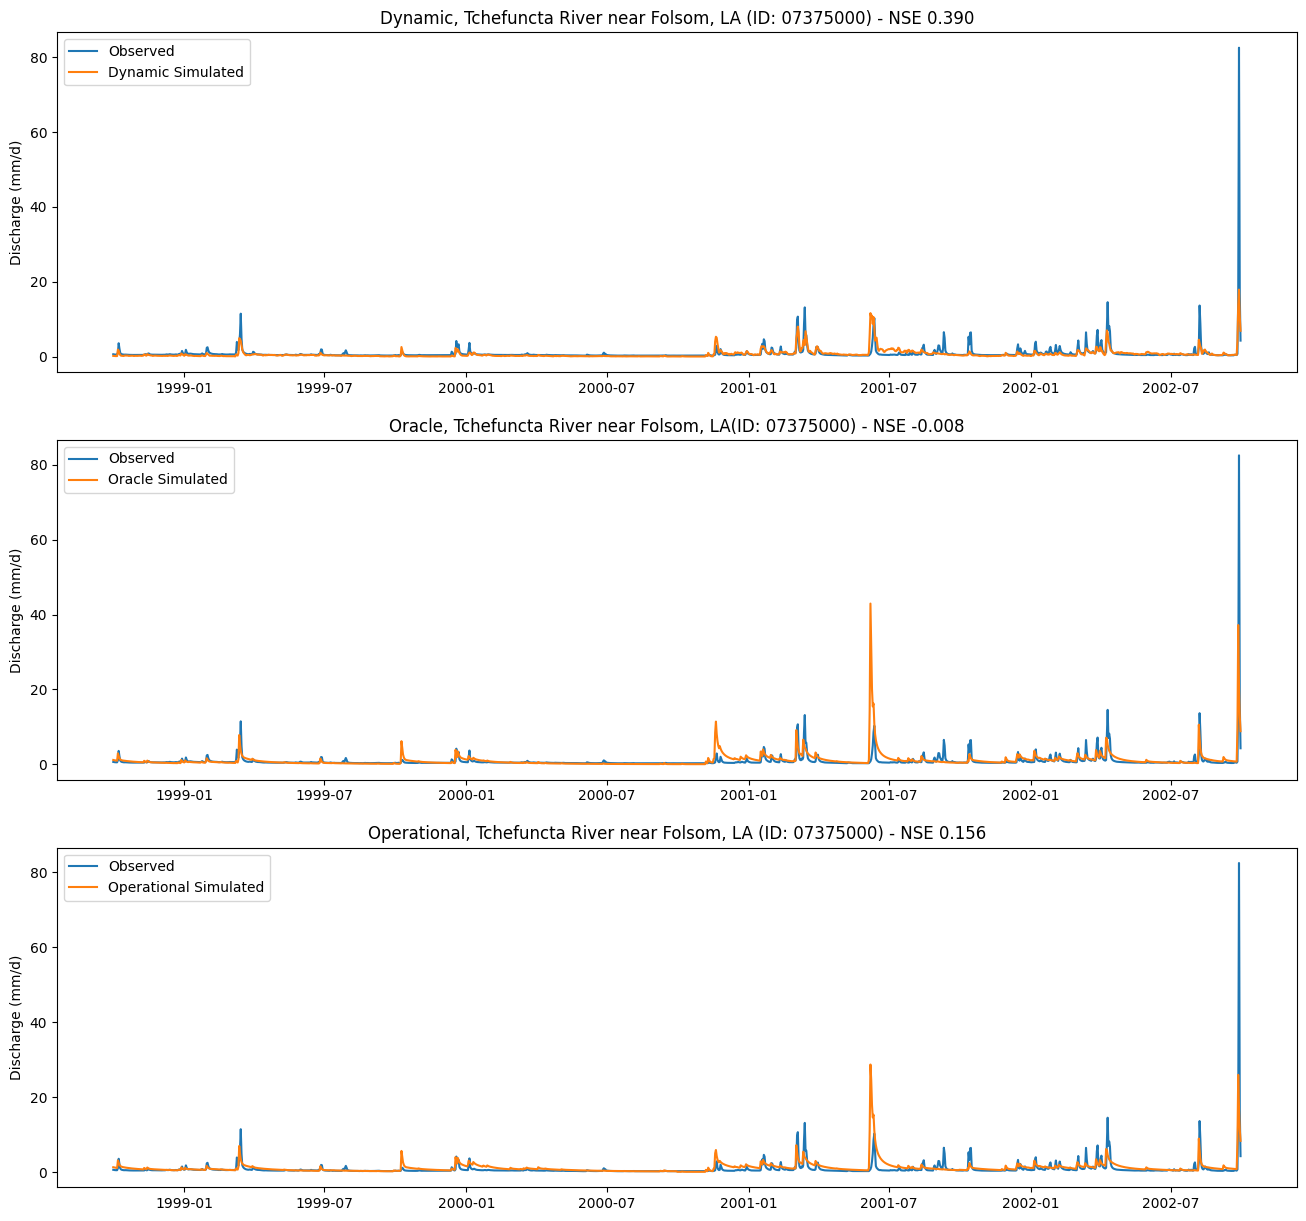

In [64]:
basin = '07375000' # Tchefuncta River near Folsom, LA

# dynamic
dynamic_agg_sim = xr.DataArray(
    np.hstack(
        [dynamic_results[basin]['1D']['xr']['QObs(mm/d)_sim'][0], 
         dynamic_results[basin]['1D']['xr']['QObs(mm/d)_sim'][365],
         dynamic_results[basin]['1D']['xr']['QObs(mm/d)_sim'][365*2],
         dynamic_results[basin]['1D']['xr']['QObs(mm/d)_sim'][365*3]]
        )
)
dynamic_agg_obs = xr.DataArray(
    np.hstack(
        [dynamic_results[basin]['1D']['xr']['QObs(mm/d)_obs'][0],
         dynamic_results[basin]['1D']['xr']['QObs(mm/d)_obs'][365],
         dynamic_results[basin]['1D']['xr']['QObs(mm/d)_obs'][365*2],
         dynamic_results[basin]['1D']['xr']['QObs(mm/d)_obs'][365*3]]
        )
)
# oracle
oracle_agg_sim = xr.DataArray(
    np.hstack(
        [oracle_results[basin]['1D']['xr']['QObs(mm/d)_sim'][0], 
         oracle_results[basin]['1D']['xr']['QObs(mm/d)_sim'][365],
         oracle_results[basin]['1D']['xr']['QObs(mm/d)_sim'][365*2],
         oracle_results[basin]['1D']['xr']['QObs(mm/d)_sim'][365*3]]
        )
)
# operational
operational_agg_sim = xr.DataArray(
    np.hstack(
        [operational_results[basin]['1D']['xr']['QObs(mm/d)_sim'][0], 
         operational_results[basin]['1D']['xr']['QObs(mm/d)_sim'][365],
         operational_results[basin]['1D']['xr']['QObs(mm/d)_sim'][365*2],
         operational_results[basin]['1D']['xr']['QObs(mm/d)_sim'][365*3]]
        )
)
dates = pd.date_range(start='1998-10-01', periods=len(oracle_agg_obs), freq='D')

fig, ax = plt.subplots(3, 1, figsize=(16,15))
ax[0].plot(dates, dynamic_agg_obs, label='Observed')
ax[0].plot(dates, dynamic_agg_sim, label='Dynamic Simulated')
ax[0].set_title(f"Dynamic, Tchefuncta River near Folsom, LA (ID: {basin}) - NSE {corrected_nse_df['dynamic_nse'][basin]:.3f}")
ax[0].legend()
ax[0].set_ylabel("Discharge (mm/d)")

ax[1].plot(dates, dynamic_agg_obs, label='Observed')
ax[1].plot(dates, oracle_agg_sim, label='Oracle Simulated')
ax[1].set_title(f"Oracle, Tchefuncta River near Folsom, LA(ID: {basin}) - NSE {corrected_nse_df['oracle_nse'][basin]:.3f}")
ax[1].legend()
ax[1].set_ylabel("Discharge (mm/d)")

ax[2].plot(dates, dynamic_agg_obs, label='Observed')
ax[2].plot(dates, operational_agg_sim, label='Operational Simulated')
ax[2].set_title(f"Operational, Tchefuncta River near Folsom, LA (ID: {basin}) - NSE {corrected_nse_df['operational_nse'][basin]:.3f}")
ax[2].legend()
ax[2].set_ylabel("Discharge (mm/d)")

### Example of Oracle Better than Operational

Text(0, 0.5, 'Discharge (mm/d)')

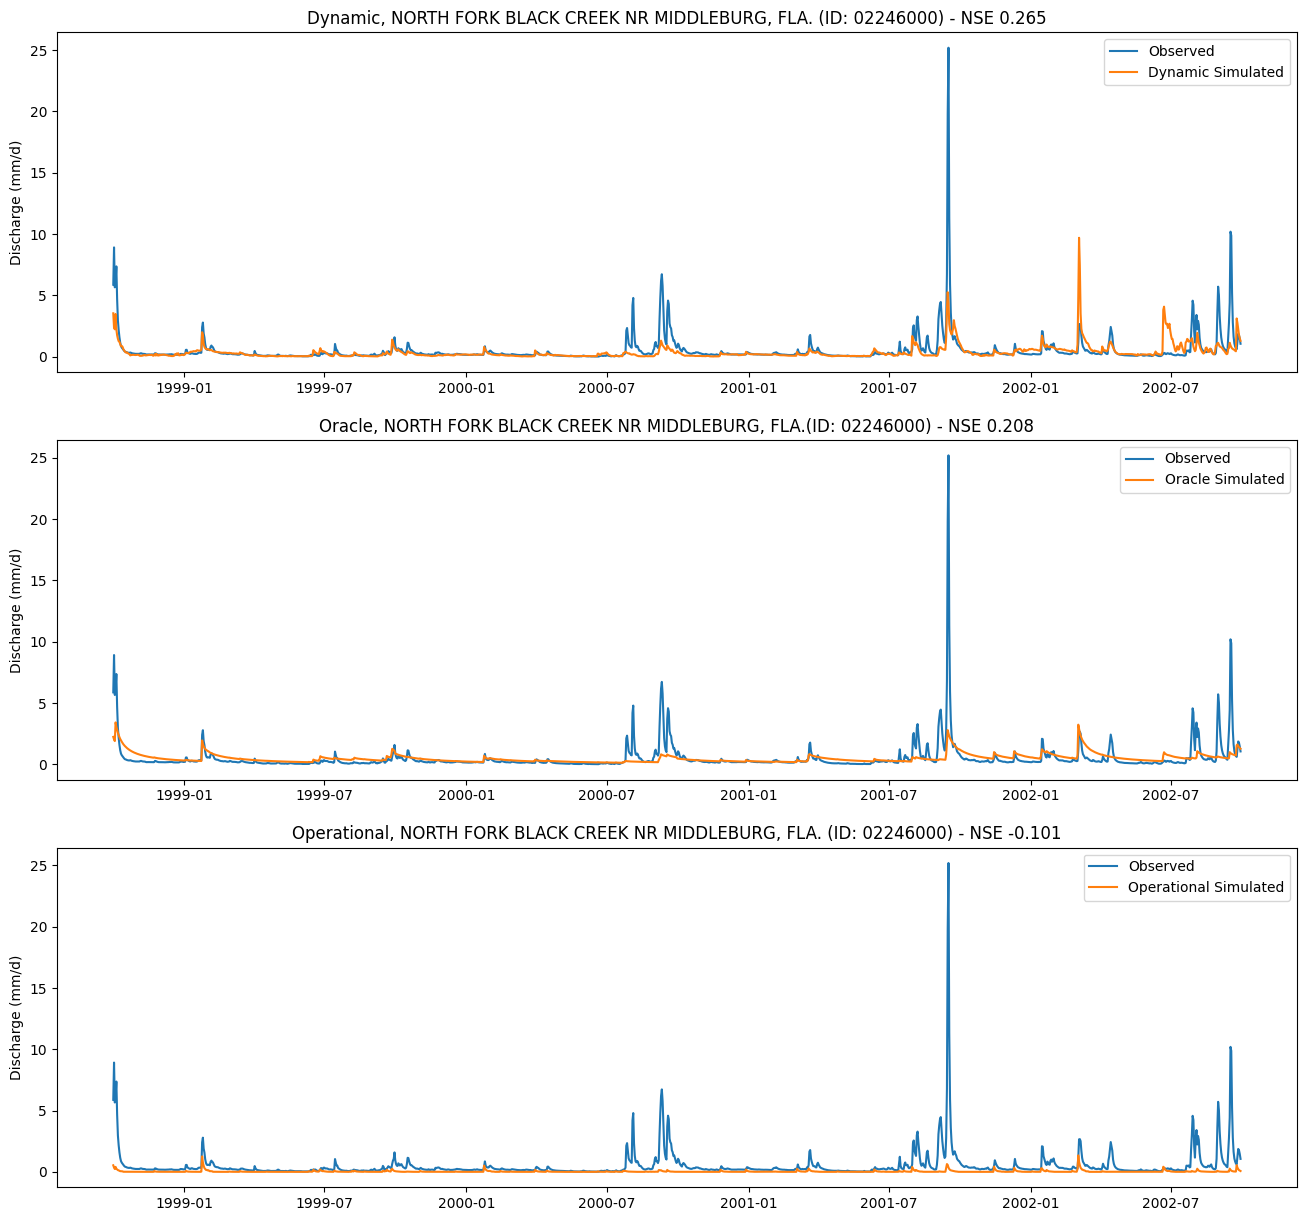

In [ ]:
basin = '02246000' # Tchefuncta River near Folsom, LA

# dynamic
dynamic_agg_sim = xr.DataArray(
    np.hstack(
        [dynamic_results[basin]['1D']['xr']['QObs(mm/d)_sim'][0], 
         dynamic_results[basin]['1D']['xr']['QObs(mm/d)_sim'][365],
         dynamic_results[basin]['1D']['xr']['QObs(mm/d)_sim'][365*2],
         dynamic_results[basin]['1D']['xr']['QObs(mm/d)_sim'][365*3]]
        )
)
dynamic_agg_obs = xr.DataArray(
    np.hstack(
        [dynamic_results[basin]['1D']['xr']['QObs(mm/d)_obs'][0],
         dynamic_results[basin]['1D']['xr']['QObs(mm/d)_obs'][365],
         dynamic_results[basin]['1D']['xr']['QObs(mm/d)_obs'][365*2],
         dynamic_results[basin]['1D']['xr']['QObs(mm/d)_obs'][365*3]]
        )
)
# oracle
oracle_agg_sim = xr.DataArray(
    np.hstack(
        [oracle_results[basin]['1D']['xr']['QObs(mm/d)_sim'][0], 
         oracle_results[basin]['1D']['xr']['QObs(mm/d)_sim'][365],
         oracle_results[basin]['1D']['xr']['QObs(mm/d)_sim'][365*2],
         oracle_results[basin]['1D']['xr']['QObs(mm/d)_sim'][365*3]]
        )
)
# operational
operational_agg_sim = xr.DataArray(
    np.hstack(
        [operational_results[basin]['1D']['xr']['QObs(mm/d)_sim'][0], 
         operational_results[basin]['1D']['xr']['QObs(mm/d)_sim'][365],
         operational_results[basin]['1D']['xr']['QObs(mm/d)_sim'][365*2],
         operational_results[basin]['1D']['xr']['QObs(mm/d)_sim'][365*3]]
        )
)
dates = pd.date_range(start='1998-10-01', periods=len(oracle_agg_obs), freq='D')

fig, ax = plt.subplots(3, 1, figsize=(16,15))
ax[0].plot(dates, dynamic_agg_obs, label='Observed')
ax[0].plot(dates, dynamic_agg_sim, label='Dynamic Simulated')
ax[0].set_title(f"Dynamic, NORTH FORK BLACK CREEK NR MIDDLEBURG, FLA. (ID: {basin}) - NSE {corrected_nse_df['dynamic_nse'][basin]:.3f}")
ax[0].legend()
ax[0].set_ylabel("Discharge (mm/d)")

ax[1].plot(dates, dynamic_agg_obs, label='Observed')
ax[1].plot(dates, oracle_agg_sim, label='Oracle Simulated')
ax[1].set_title(f"Oracle, NORTH FORK BLACK CREEK NR MIDDLEBURG, FLA.(ID: {basin}) - NSE {corrected_nse_df['oracle_nse'][basin]:.3f}")
ax[1].legend()
ax[1].set_ylabel("Discharge (mm/d)")

ax[2].plot(dates, dynamic_agg_obs, label='Observed')
ax[2].plot(dates, operational_agg_sim, label='Operational Simulated')
ax[2].set_title(f"Operational, NORTH FORK BLACK CREEK NR MIDDLEBURG, FLA. (ID: {basin}) - NSE {corrected_nse_df['operational_nse'][basin]:.3f}")
ax[2].legend()
ax[2].set_ylabel("Discharge (mm/d)")

## Other Metrics & Comparison

In [12]:
from neuralhydrology.evaluation.metrics import rmse, kge

In [34]:
basin_keys = list(dynamic_results.keys())

# Create dictionary to store results
rmse_results = {'basin': [], 'dynamic_rmse': [], 'oracle_rmse': [], 'operational_rmse': []}

# Dynamic Mode
for basin in basin_keys:
    dynamic_agg_sim = np.hstack([dynamic_results[basin]['1D']['xr']['QObs(mm/d)_sim'][0], 
             dynamic_results[basin]['1D']['xr']['QObs(mm/d)_sim'][365],
             dynamic_results[basin]['1D']['xr']['QObs(mm/d)_sim'][365*2],
             dynamic_results[basin]['1D']['xr']['QObs(mm/d)_sim'][365*3]])
    dynamic_agg_obs = np.hstack([dynamic_results[basin]['1D']['xr']['QObs(mm/d)_obs'][0],
                dynamic_results[basin]['1D']['xr']['QObs(mm/d)_obs'][365],
                dynamic_results[basin]['1D']['xr']['QObs(mm/d)_obs'][365*2],
                dynamic_results[basin]['1D']['xr']['QObs(mm/d)_obs'][365*3]])
    dynamic_rmse = rmse(xr.DataArray(dynamic_agg_obs), xr.DataArray(dynamic_agg_sim))
    
    # Oracle Mode
    oracle_agg_sim = np.hstack([oracle_results[basin]['1D']['xr']['QObs(mm/d)_sim'][0], 
             oracle_results[basin]['1D']['xr']['QObs(mm/d)_sim'][365],
             oracle_results[basin]['1D']['xr']['QObs(mm/d)_sim'][365*2],
             oracle_results[basin]['1D']['xr']['QObs(mm/d)_sim'][365*3]])
    oracle_agg_obs = np.hstack([oracle_results[basin]['1D']['xr']['QObs(mm/d)_obs'][0],
                oracle_results[basin]['1D']['xr']['QObs(mm/d)_obs'][365],
                oracle_results[basin]['1D']['xr']['QObs(mm/d)_obs'][365*2],
                oracle_results[basin]['1D']['xr']['QObs(mm/d)_obs'][365*3]])
    oracle_rmse = rmse(xr.DataArray(oracle_agg_obs), xr.DataArray(oracle_agg_sim))
    
    # Operational Mode
    operational_agg_sim = np.hstack([operational_results[basin]['1D']['xr']['QObs(mm/d)_sim'][0], 
             operational_results[basin]['1D']['xr']['QObs(mm/d)_sim'][365],
             operational_results[basin]['1D']['xr']['QObs(mm/d)_sim'][365*2],
             operational_results[basin]['1D']['xr']['QObs(mm/d)_sim'][365*3]])
    operational_agg_obs = np.hstack([operational_results[basin]['1D']['xr']['QObs(mm/d)_obs'][0],
                operational_results[basin]['1D']['xr']['QObs(mm/d)_obs'][365],
                operational_results[basin]['1D']['xr']['QObs(mm/d)_obs'][365*2],
                operational_results[basin]['1D']['xr']['QObs(mm/d)_obs'][365*3]])
    operational_rmse = rmse(xr.DataArray(operational_agg_obs), xr.DataArray(operational_agg_sim))
    
    # Append to results dictionary
    rmse_results['basin'].append(basin)
    rmse_results['dynamic_rmse'].append(float(dynamic_rmse))
    rmse_results['oracle_rmse'].append(float(oracle_rmse))
    rmse_results['operational_rmse'].append(float(operational_rmse))

# Convert to DataFrame with basin as index
rmse_df = pd.DataFrame(rmse_results).set_index('basin')
rmse_df

,dynamic_rmse,oracle_rmse,operational_rmse
basin,,,
02092500,2.579421,2.810222,2.670029
02102908,0.770063,0.715624,0.750214
02108000,2.354926,2.470067,2.268886
02193340,1.128721,1.166130,1.195947
02196000,0.494810,0.561972,0.536961
...,...,...,...
14305500,5.302262,6.039435,6.057701
14306340,3.624660,3.694817,3.738896
14306500,2.097770,2.127893,2.149019


In [35]:
# Create dictionary to store results
kge_results = {'basin': [], 'dynamic_kge': [], 'oracle_kge': [], 'operational_kge': []}

# Dynamic Mode
for basin in basin_keys:
    dynamic_agg_sim = np.hstack([dynamic_results[basin]['1D']['xr']['QObs(mm/d)_sim'][0], 
             dynamic_results[basin]['1D']['xr']['QObs(mm/d)_sim'][365],
             dynamic_results[basin]['1D']['xr']['QObs(mm/d)_sim'][365*2],
             dynamic_results[basin]['1D']['xr']['QObs(mm/d)_sim'][365*3]])
    dynamic_agg_obs = np.hstack([dynamic_results[basin]['1D']['xr']['QObs(mm/d)_obs'][0],
                dynamic_results[basin]['1D']['xr']['QObs(mm/d)_obs'][365],
                dynamic_results[basin]['1D']['xr']['QObs(mm/d)_obs'][365*2],
                dynamic_results[basin]['1D']['xr']['QObs(mm/d)_obs'][365*3]])
    dynamic_kge = kge(xr.DataArray(dynamic_agg_obs), xr.DataArray(dynamic_agg_sim))
    
    # Oracle Mode
    oracle_agg_sim = np.hstack([oracle_results[basin]['1D']['xr']['QObs(mm/d)_sim'][0], 
             oracle_results[basin]['1D']['xr']['QObs(mm/d)_sim'][365],
             oracle_results[basin]['1D']['xr']['QObs(mm/d)_sim'][365*2],
             oracle_results[basin]['1D']['xr']['QObs(mm/d)_sim'][365*3]])
    oracle_agg_obs = np.hstack([oracle_results[basin]['1D']['xr']['QObs(mm/d)_obs'][0],
                oracle_results[basin]['1D']['xr']['QObs(mm/d)_obs'][365],
                oracle_results[basin]['1D']['xr']['QObs(mm/d)_obs'][365*2],
                oracle_results[basin]['1D']['xr']['QObs(mm/d)_obs'][365*3]])
    oracle_kge = kge(xr.DataArray(oracle_agg_obs), xr.DataArray(oracle_agg_sim))
    
    # Operational Mode
    operational_agg_sim = np.hstack([operational_results[basin]['1D']['xr']['QObs(mm/d)_sim'][0], 
             operational_results[basin]['1D']['xr']['QObs(mm/d)_sim'][365],
             operational_results[basin]['1D']['xr']['QObs(mm/d)_sim'][365*2],
             operational_results[basin]['1D']['xr']['QObs(mm/d)_sim'][365*3]])
    operational_agg_obs = np.hstack([operational_results[basin]['1D']['xr']['QObs(mm/d)_obs'][0],
                operational_results[basin]['1D']['xr']['QObs(mm/d)_obs'][365],
                operational_results[basin]['1D']['xr']['QObs(mm/d)_obs'][365*2],
                operational_results[basin]['1D']['xr']['QObs(mm/d)_obs'][365*3]])
    operational_kge = kge(xr.DataArray(operational_agg_obs), xr.DataArray(operational_agg_sim))
    
    # Append to results dictionary
    kge_results['basin'].append(basin)
    kge_results['dynamic_kge'].append(float(dynamic_kge))
    kge_results['oracle_kge'].append(float(oracle_kge))
    kge_results['operational_kge'].append(float(operational_kge))

# Convert to DataFrame with basin as index
kge_df = pd.DataFrame(kge_results).set_index('basin')
kge_df

,dynamic_kge,oracle_kge,operational_kge
basin,,,
02092500,0.287846,0.027944,0.193093
02102908,0.560819,0.409208,0.598203
02108000,0.169755,0.021438,0.182645
02193340,0.260391,0.409539,0.312249
02196000,0.392883,0.190524,0.513181
...,...,...,...
14305500,0.867154,0.790861,0.775077
14306340,0.836103,0.783548,0.767716
14306500,0.916702,0.930276,0.945039


## Compare all 3 metrics

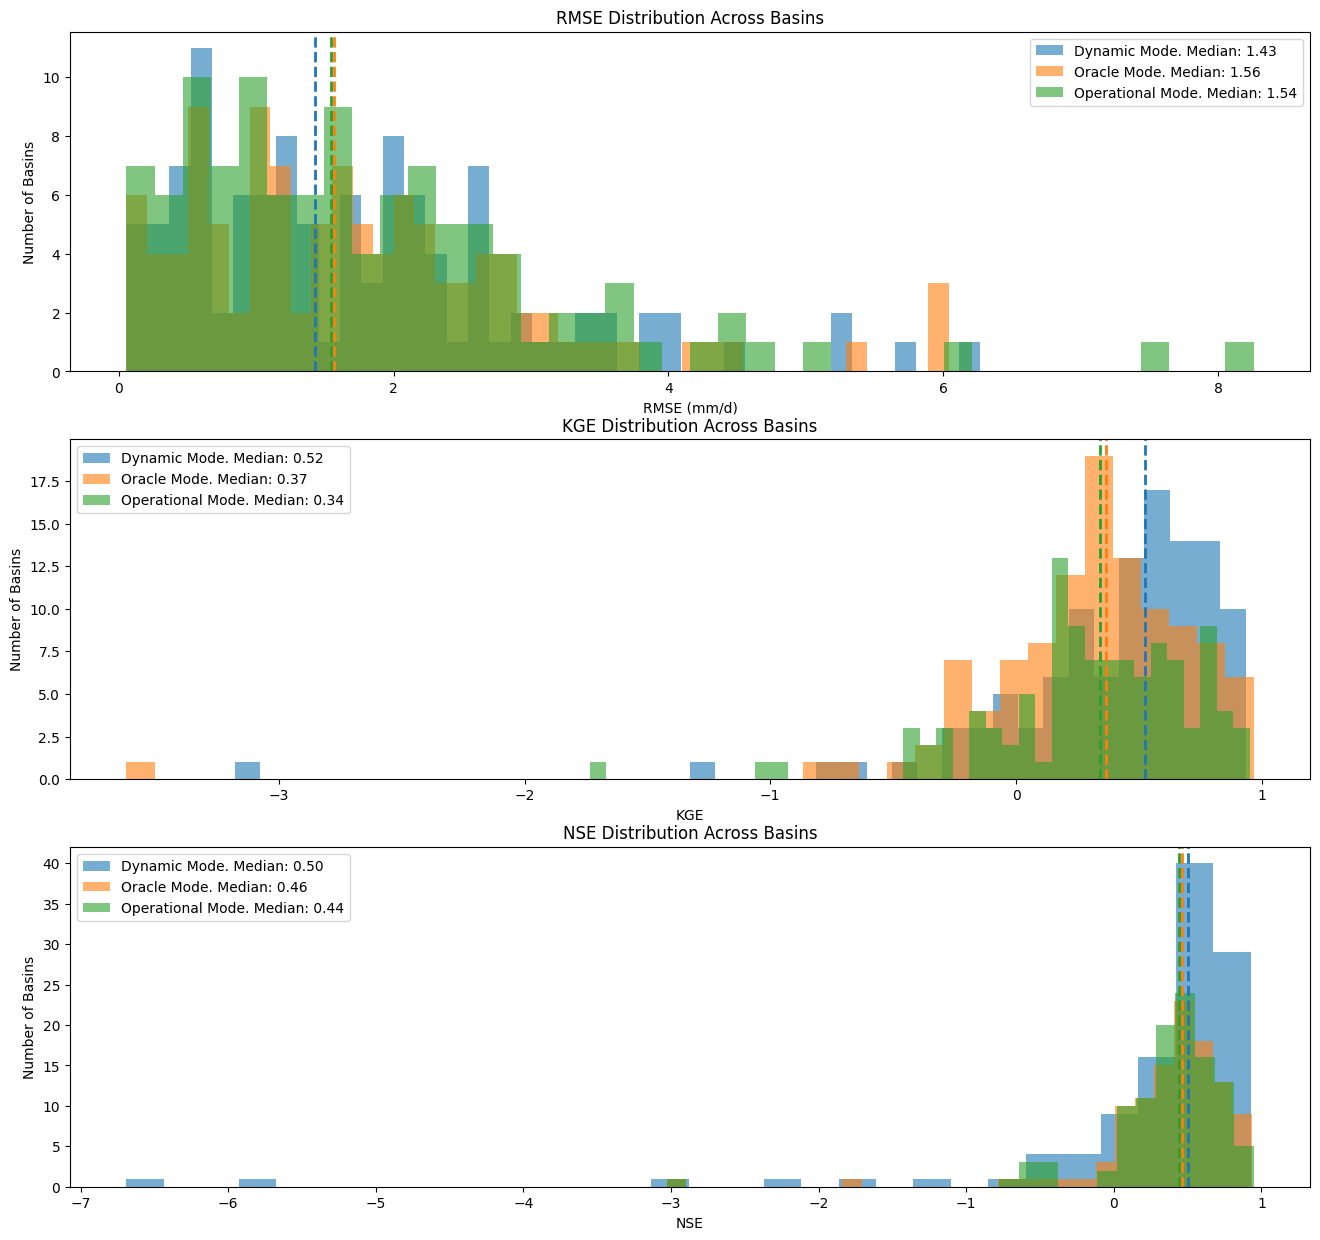

In [24]:
num_bins = 40
a = 0.6

fig, ax = plt.subplots(3, 1, figsize=(16,15))
ax[0].hist(rmse_df['dynamic_rmse'], bins=num_bins, alpha=a, label='Dynamic Mode. Median: {:.2f}'.format(rmse_df['dynamic_rmse'].median()))
ax[0].axvline(rmse_df['dynamic_rmse'].median(), color='tab:blue', linestyle='dashed', linewidth=2)
ax[0].hist(rmse_df['oracle_rmse'], bins=num_bins, alpha=a, label='Oracle Mode. Median: {:.2f}'.format(rmse_df['oracle_rmse'].median()))
ax[0].axvline(rmse_df['oracle_rmse'].median(), color='tab:orange', linestyle='dashed', linewidth=2)
ax[0].hist(rmse_df['operational_rmse'], bins=num_bins, alpha=a, label='Operational Mode. Median: {:.2f}'.format(rmse_df['operational_rmse'].median()))
ax[0].axvline(rmse_df['operational_rmse'].median(), color='tab:green', linestyle='dashed', linewidth=2)
ax[0].set_title("RMSE Distribution Across Basins")
ax[0].set_xlabel("RMSE (mm/d)")
ax[0].set_ylabel("Number of Basins")
ax[0].legend() 

ax[1].hist(kge_df['dynamic_kge'], bins=num_bins, alpha=a, label='Dynamic Mode. Median: {:.2f}'.format(kge_df['dynamic_kge'].median()))
ax[1].axvline(kge_df['dynamic_kge'].median(), color='tab:blue', linestyle='dashed', linewidth=2)
ax[1].hist(kge_df['oracle_kge'], bins=num_bins, alpha=a, label='Oracle Mode. Median: {:.2f}'.format(kge_df['oracle_kge'].median()))
ax[1].axvline(kge_df['oracle_kge'].median(), color='tab:orange', linestyle='dashed', linewidth=2)
ax[1].hist(kge_df['operational_kge'], bins=num_bins, alpha=a, label='Operational Mode. Median: {:.2f}'.format(kge_df['operational_kge'].median()))
ax[1].axvline(kge_df['operational_kge'].median(), color='tab:green', linestyle='dashed', linewidth=2)
ax[1].set_title("KGE Distribution Across Basins")
ax[1].set_xlabel("KGE")
ax[1].set_ylabel("Number of Basins")
ax[1].legend() 

ax[2].hist(corrected_nse_df['dynamic_nse'], bins=30, alpha=a, label='Dynamic Mode. Median: {:.2f}'.format(corrected_nse_df['dynamic_nse'].median()))
ax[2].axvline(corrected_nse_df['dynamic_nse'].median(), color='tab:blue', linestyle='dashed', linewidth=2)
ax[2].hist(corrected_nse_df['oracle_nse'], bins=30, alpha=a, label='Oracle Mode. Median: {:.2f}'.format(corrected_nse_df['oracle_nse'].median()))
ax[2].axvline(corrected_nse_df['oracle_nse'].median(), color='tab:orange', linestyle='dashed', linewidth=2)
ax[2].hist(corrected_nse_df['operational_nse'], bins=30, alpha=a, label='Operational Mode. Median: {:.2f}'.format(corrected_nse_df['operational_nse'].median()))
ax[2].axvline(corrected_nse_df['operational_nse'].median(), color='tab:green', linestyle='dashed', linewidth=2)
ax[2].set_title("NSE Distribution Across Basins")
ax[2].set_xlabel("NSE")
ax[2].set_ylabel("Number of Basins")
ax[2].legend()

## Grab cocneptual prameters (Need Work)

In [ ]:
basin = '02246000' # Tchefuncta River near Folsom, LA
oracle_results[basin]

{'1D': {'xr': <xarray.Dataset> Size: 3MB
  Dimensions:         (date: 1097, time_step: 365)
  Coordinates:
    * date            (date) datetime64[ns] 9kB 1999-09-30 ... 2002-09-30
    * time_step       (time_step) int64 3kB -364 -363 -362 -361 ... -3 -2 -1 0
  Data variables:
      QObs(mm/d)_obs  (date, time_step) float32 2MB 5.873 8.916 ... 1.057 0.8222
      QObs(mm/d)_sim  (date, time_step) float32 2MB 2.242 2.041 ... 1.276 1.231,
  'NSE': 0.16945642232894897}}

# SHM (Need Fixing)
Same configuration adapted for SHM model. 
## Metrics Comparison: NSE, RMSE, KGE

In [1]:
import pickle
from pathlib import Path
import pandas as pd
import numpy as np
import torch.nn as nn

from neuralhydrology.utils.config import Config

import matplotlib.pyplot as plt
import torch
from neuralhydrology.evaluation import metrics
from neuralhydrology.nh_run import start_run, eval_run

from neuralhydrology.evaluation.metrics import nse, rmse, kge
import xarray as xr

In [36]:
shm_dynamic_path = Path("runs/EXP1_SHM_CAMELS_noSnow_Dynamic_2901_143452")
shm_oracle_path = Path("runs/EXP1_SHM_CAMELS_noSnow_OracleAvg_2901_153236")
shm_operational_path = Path("runs/EXP1_SHM_CAMELS_noSnow_OperationalAvg_2901_163450")

with open(shm_dynamic_path / "test" / "model_epoch030" / "test_results.p", "rb") as fp:
    shm_dynamic_results = pickle.load(fp)
with open(shm_oracle_path / "test" / "model_epoch030" / "test_results.p", "rb") as fp:
    shm_oracle_results = pickle.load(fp)
with open(shm_operational_path / "test" / "model_epoch030" / "test_results.p", "rb") as fp:
    shm_operational_results = pickle.load(fp)


In [37]:
basin_keys = list(shm_dynamic_results.keys())

# Create dictionary to store results
shm_metric_results = {'basin': [], 'dynamic_nse': [], 'oracle_nse': [], 'operational_nse': [],
                      'dynamic_rmse': [], 'oracle_rmse': [], 'operational_rmse': [],
                     'dynamic_kge': [], 'oracle_kge': [], 'operational_kge': []}

# Dynamic Mode
for basin in basin_keys:
    dynamic_agg_sim = np.hstack([shm_dynamic_results[basin]['1D']['xr']['QObs(mm/d)_sim'][0], 
             shm_dynamic_results[basin]['1D']['xr']['QObs(mm/d)_sim'][365],
             shm_dynamic_results[basin]['1D']['xr']['QObs(mm/d)_sim'][365*2],
             shm_dynamic_results[basin]['1D']['xr']['QObs(mm/d)_sim'][365*3]])
    dynamic_agg_obs = np.hstack([shm_dynamic_results[basin]['1D']['xr']['QObs(mm/d)_obs'][0],
                shm_dynamic_results[basin]['1D']['xr']['QObs(mm/d)_obs'][365],
                shm_dynamic_results[basin]['1D']['xr']['QObs(mm/d)_obs'][365*2],
                shm_dynamic_results[basin]['1D']['xr']['QObs(mm/d)_obs'][365*3]])
    dynamic_nse = nse(xr.DataArray(dynamic_agg_obs), xr.DataArray(dynamic_agg_sim))
    dynamic_rmse = rmse(xr.DataArray(dynamic_agg_obs), xr.DataArray(dynamic_agg_sim))
    dynamic_kge = kge(xr.DataArray(dynamic_agg_obs), xr.DataArray(dynamic_agg_sim))
    
    # Oracle Mode
    oracle_agg_sim = np.hstack([shm_oracle_results[basin]['1D']['xr']['QObs(mm/d)_sim'][0], 
             shm_oracle_results[basin]['1D']['xr']['QObs(mm/d)_sim'][365],
             shm_oracle_results[basin]['1D']['xr']['QObs(mm/d)_sim'][365*2],
             shm_oracle_results[basin]['1D']['xr']['QObs(mm/d)_sim'][365*3]])
    oracle_agg_obs = np.hstack([shm_oracle_results[basin]['1D']['xr']['QObs(mm/d)_obs'][0],
                shm_oracle_results[basin]['1D']['xr']['QObs(mm/d)_obs'][365],
                shm_oracle_results[basin]['1D']['xr']['QObs(mm/d)_obs'][365*2],
                shm_oracle_results[basin]['1D']['xr']['QObs(mm/d)_obs'][365*3]])
    oracle_nse = nse(xr.DataArray(oracle_agg_obs), xr.DataArray(oracle_agg_sim))
    oracle_rmse = rmse(xr.DataArray(oracle_agg_obs), xr.DataArray(oracle_agg_sim))
    oracle_kge = kge(xr.DataArray(oracle_agg_obs), xr.DataArray(oracle_agg_sim))
    
    # Operational Mode
    operational_agg_sim = np.hstack([shm_operational_results[basin]['1D']['xr']['QObs(mm/d)_sim'][0], 
             shm_operational_results[basin]['1D']['xr']['QObs(mm/d)_sim'][365],
             shm_operational_results[basin]['1D']['xr']['QObs(mm/d)_sim'][365*2],
             shm_operational_results[basin]['1D']['xr']['QObs(mm/d)_sim'][365*3]])
    operational_agg_obs = np.hstack([shm_operational_results[basin]['1D']['xr']['QObs(mm/d)_obs'][0],
                shm_operational_results[basin]['1D']['xr']['QObs(mm/d)_obs'][365],
                shm_operational_results[basin]['1D']['xr']['QObs(mm/d)_obs'][365*2],
                shm_operational_results[basin]['1D']['xr']['QObs(mm/d)_obs'][365*3]])
    operational_nse = nse(xr.DataArray(operational_agg_obs), xr.DataArray(operational_agg_sim))
    operational_rmse = rmse(xr.DataArray(operational_agg_obs), xr.DataArray(operational_agg_sim))
    operational_kge = kge(xr.DataArray(operational_agg_obs), xr.DataArray(operational_agg_sim))
    
    # Append to results dictionary
    shm_metric_results['basin'].append(basin)
    shm_metric_results['dynamic_nse'].append(float(dynamic_nse))
    shm_metric_results['dynamic_rmse'].append(float(dynamic_rmse))
    shm_metric_results['dynamic_kge'].append(float(dynamic_kge))
    shm_metric_results['oracle_nse'].append(float(oracle_nse))
    shm_metric_results['oracle_rmse'].append(float(oracle_rmse))
    shm_metric_results['oracle_kge'].append(float(oracle_kge))
    shm_metric_results['operational_nse'].append(float(operational_nse))
    shm_metric_results['operational_rmse'].append(float(operational_rmse))
    shm_metric_results['operational_kge'].append(float(operational_kge))

# Convert to DataFrame with basin as index
shm_metrics = pd.DataFrame(shm_metric_results).set_index('basin')
shm_metrics

,dynamic_nse,oracle_nse,operational_nse,dynamic_rmse,oracle_rmse,operational_rmse,dynamic_kge,oracle_kge,operational_kge
basin,,,,,,,,,
02092500,0.332014,0.357529,0.264915,2.570072,2.520509,2.696065,0.227260,0.293872,0.176374
02102908,0.422426,0.203211,0.240603,0.628728,0.738466,0.720930,0.640455,0.554475,0.621468
02108000,0.370521,0.283814,0.300992,2.197533,2.344001,2.315719,0.239605,0.111817,0.144523
02193340,0.441583,0.453177,0.469404,1.104614,1.093087,1.076746,0.362482,0.315765,0.345984
02196000,0.410462,0.562826,0.525458,0.563222,0.485011,0.505314,-0.116887,0.502898,0.384749
...,...,...,...,...,...,...,...,...,...
14305500,0.769218,0.722305,0.714238,5.879767,6.449748,6.542761,0.831709,0.717035,0.743527
14306340,0.824433,0.813991,0.824452,3.473097,3.574892,3.472912,0.820995,0.769993,0.780809
14306500,0.886268,0.889642,0.887072,2.206092,2.173118,2.198277,0.881981,0.931985,0.927828


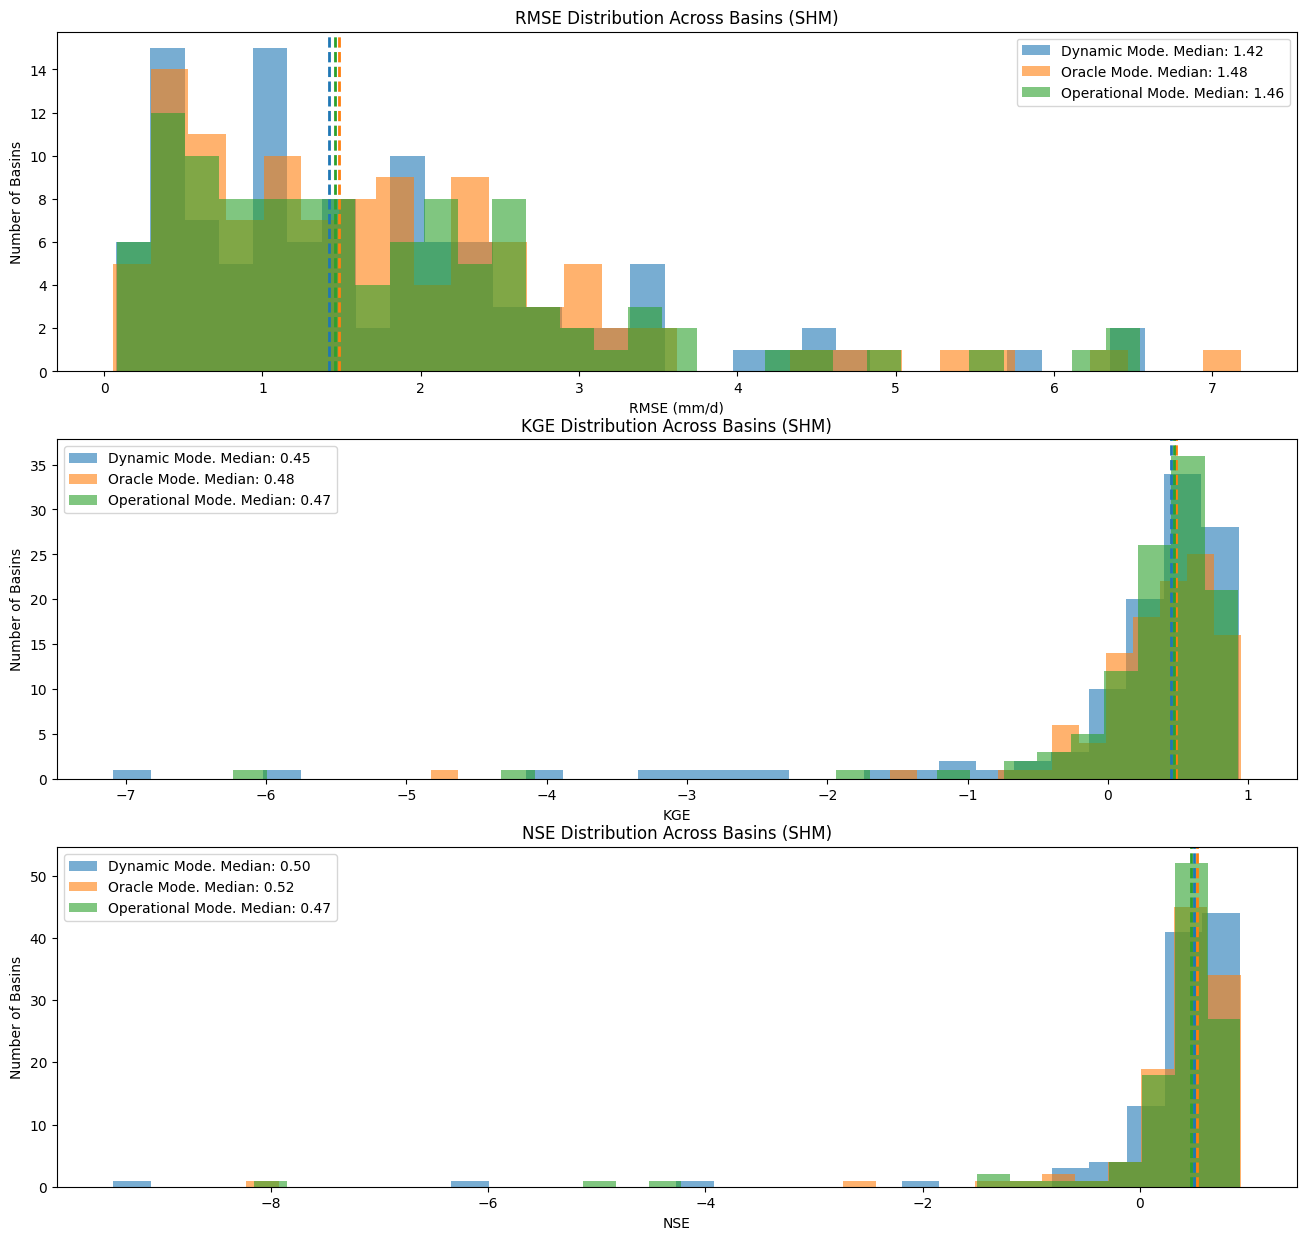

In [4]:
num_bins = 30
a = 0.6

fig, ax = plt.subplots(3, 1, figsize=(16,15))
ax[0].hist(shm_metrics['dynamic_rmse'], bins=num_bins, alpha=a, label='Dynamic Mode. Median: {:.2f}'.format(shm_metrics['dynamic_rmse'].median()))
ax[0].axvline(shm_metrics['dynamic_rmse'].median(), color='tab:blue', linestyle='dashed', linewidth=2)
ax[0].hist(shm_metrics['oracle_rmse'], bins=num_bins, alpha=a, label='Oracle Mode. Median: {:.2f}'.format(shm_metrics['oracle_rmse'].median()))
ax[0].axvline(shm_metrics['oracle_rmse'].median(), color='tab:orange', linestyle='dashed', linewidth=2)
ax[0].hist(shm_metrics['operational_rmse'], bins=num_bins, alpha=a, label='Operational Mode. Median: {:.2f}'.format(shm_metrics['operational_rmse'].median()))
ax[0].axvline(shm_metrics['operational_rmse'].median(), color='tab:green', linestyle='dashed', linewidth=2)
ax[0].set_title("RMSE Distribution Across Basins (SHM)")
ax[0].set_xlabel("RMSE (mm/d)")
ax[0].set_ylabel("Number of Basins")
ax[0].legend() 

ax[1].hist(shm_metrics['dynamic_kge'], bins=num_bins, alpha=a, label='Dynamic Mode. Median: {:.2f}'.format(shm_metrics['dynamic_kge'].median()))
ax[1].axvline(shm_metrics['dynamic_kge'].median(), color='tab:blue', linestyle='dashed', linewidth=2)
ax[1].hist(shm_metrics['oracle_kge'], bins=num_bins, alpha=a, label='Oracle Mode. Median: {:.2f}'.format(shm_metrics['oracle_kge'].median()))
ax[1].axvline(shm_metrics['oracle_kge'].median(), color='tab:orange', linestyle='dashed', linewidth=2)
ax[1].hist(shm_metrics['operational_kge'], bins=num_bins, alpha=a, label='Operational Mode. Median: {:.2f}'.format(shm_metrics['operational_kge'].median()))
ax[1].axvline(shm_metrics['operational_kge'].median(), color='tab:green', linestyle='dashed', linewidth=2)
ax[1].set_title("KGE Distribution Across Basins (SHM)")
ax[1].set_xlabel("KGE")
ax[1].set_ylabel("Number of Basins")
ax[1].legend() 

ax[2].hist(shm_metrics['dynamic_nse'], bins=30, alpha=a, label='Dynamic Mode. Median: {:.2f}'.format(shm_metrics['dynamic_nse'].median()))
ax[2].axvline(shm_metrics['dynamic_nse'].median(), color='tab:blue', linestyle='dashed', linewidth=2)
ax[2].hist(shm_metrics['oracle_nse'], bins=30, alpha=a, label='Oracle Mode. Median: {:.2f}'.format(shm_metrics['oracle_nse'].median()))
ax[2].axvline(shm_metrics['oracle_nse'].median(), color='tab:orange', linestyle='dashed', linewidth=2)
ax[2].hist(shm_metrics['operational_nse'], bins=30, alpha=a, label='Operational Mode. Median: {:.2f}'.format(shm_metrics['operational_nse'].median()))
ax[2].axvline(shm_metrics['operational_nse'].median(), color='tab:green', linestyle='dashed', linewidth=2)
ax[2].set_title("NSE Distribution Across Basins (SHM)")
ax[2].set_xlabel("NSE")
ax[2].set_ylabel("Number of Basins")
ax[2].legend()

## Training Modes Comparison for NSE

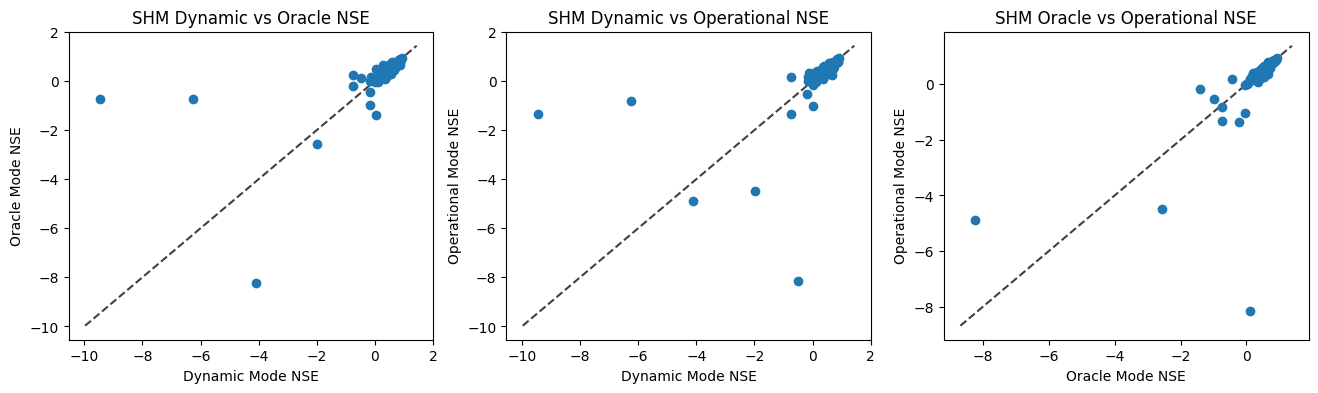

In [6]:
fig, ax = plt.subplots(1, 3, figsize=(16,4))
ax[0].plot(shm_metrics['dynamic_nse'], shm_metrics['oracle_nse'], 'o')
ax[0].set_title("SHM Dynamic vs Oracle NSE")
ax[0].set_xlabel("Dynamic Mode NSE")
ax[0].set_ylabel("Oracle Mode NSE")
lims0 = [np.min([ax[0].get_xlim(), ax[0].get_ylim()]), np.max([ax[0].get_xlim(), ax[0].get_ylim()])]
ax[0].plot(lims0, lims0, 'k--', alpha=0.75, zorder=0)

ax[1].plot(shm_metrics['dynamic_nse'], shm_metrics['operational_nse'], 'o')
ax[1].set_title("SHM Dynamic vs Operational NSE")
ax[1].set_xlabel("Dynamic Mode NSE")
ax[1].set_ylabel("Operational Mode NSE")
lims1 = [np.min([ax[1].get_xlim(), ax[1].get_ylim()]), np.max([ax[1].get_xlim(), ax[1].get_ylim()])]
ax[1].plot(lims1, lims1, 'k--', alpha=0.75, zorder=0)

ax[2].plot(shm_metrics['oracle_nse'], shm_metrics['operational_nse'], 'o')
ax[2].set_title("SHM Oracle vs Operational NSE")
ax[2].set_xlabel("Oracle Mode NSE")
ax[2].set_ylabel("Operational Mode NSE")
lims2 = [np.min([ax[2].get_xlim(), ax[2].get_ylim()]), np.max([ax[2].get_xlim(), ax[2].get_ylim()])]
ax[2].plot(lims2, lims2, 'k--', alpha=0.75, zorder=0)

# LSTM Benchmark (Need Fixing)

In [7]:
import pickle
from pathlib import Path
import pandas as pd
import numpy as np
import torch.nn as nn

from neuralhydrology.utils.config import Config

import matplotlib.pyplot as plt
import torch
from neuralhydrology.evaluation import metrics
from neuralhydrology.nh_run import start_run, eval_run

from neuralhydrology.evaluation.metrics import nse, kge, rmse
import xarray as xr

In [3]:
lstm_path = Path("runs/EXP1_LSTM_CAMELS_Benchmark_0602_153355")
with open(lstm_path / "test" / "model_epoch030" / "test_results.p", "rb") as fp:
    lstm_results = pickle.load(fp)

## Verify metircs calculated correctly

In [ ]:
basin = '08202700' #'02231000' #'08202700'
nse(xr.DataArray(lstm_results[basin]['1D']['xr']['QObs(mm/d)_obs'].squeeze(drop=True)), 
    xr.DataArray(lstm_results[basin]['1D']['xr']['QObs(mm/d)_sim'].squeeze(drop=True)))

0.5881643891334534

In [19]:
lstm_results[basin]['1D']['NSE']

0.5895776152610779

It is pretty confusing why they don't match up exactly. Should bring this up to team.

## Metrics Comparison: NSE, RMSE, KGE

In [39]:
lstm_metric = {'basin': [], 'nse': [], 'rmse': [], 'kge': []}
basin_keys = list(lstm_results.keys())

# Dynamic Mode
for basin in basin_keys:
    lstm_nse = nse(xr.DataArray(lstm_results[basin]['1D']['xr']['QObs(mm/d)_obs'].squeeze(drop=True)),
                     xr.DataArray(lstm_results[basin]['1D']['xr']['QObs(mm/d)_sim'].squeeze(drop=True)))
    lstm_rmse = rmse(xr.DataArray(lstm_results[basin]['1D']['xr']['QObs(mm/d)_obs'].squeeze(drop=True)),
                        xr.DataArray(lstm_results[basin]['1D']['xr']['QObs(mm/d)_sim'].squeeze(drop=True)))
    lstm_kge = kge(xr.DataArray(lstm_results[basin]['1D']['xr']['QObs(mm/d)_obs'].squeeze(drop=True)),
                        xr.DataArray(lstm_results[basin]['1D']['xr']['QObs(mm/d)_sim'].squeeze(drop=True)))
    
    # Append to results dictionary
    lstm_metric['basin'].append(basin)
    lstm_metric['nse'].append(float(lstm_nse))
    lstm_metric['rmse'].append(float(lstm_rmse))
    lstm_metric['kge'].append(float(lstm_kge))
    
lstm_metric = pd.DataFrame(lstm_metric).set_index('basin')

In [40]:
print(f"LSTM's Median RMSE: {lstm_metric['rmse'].median():.3f}, KGE : {np.median(lstm_metric['kge']):.3f},NSE : {np.median(lstm_metric['nse']):.3f}")


LSTM's Median RMSE: 1.342, KGE : 0.476,NSE : 0.550


## Comparison to Dynamic of dCFE and SHM

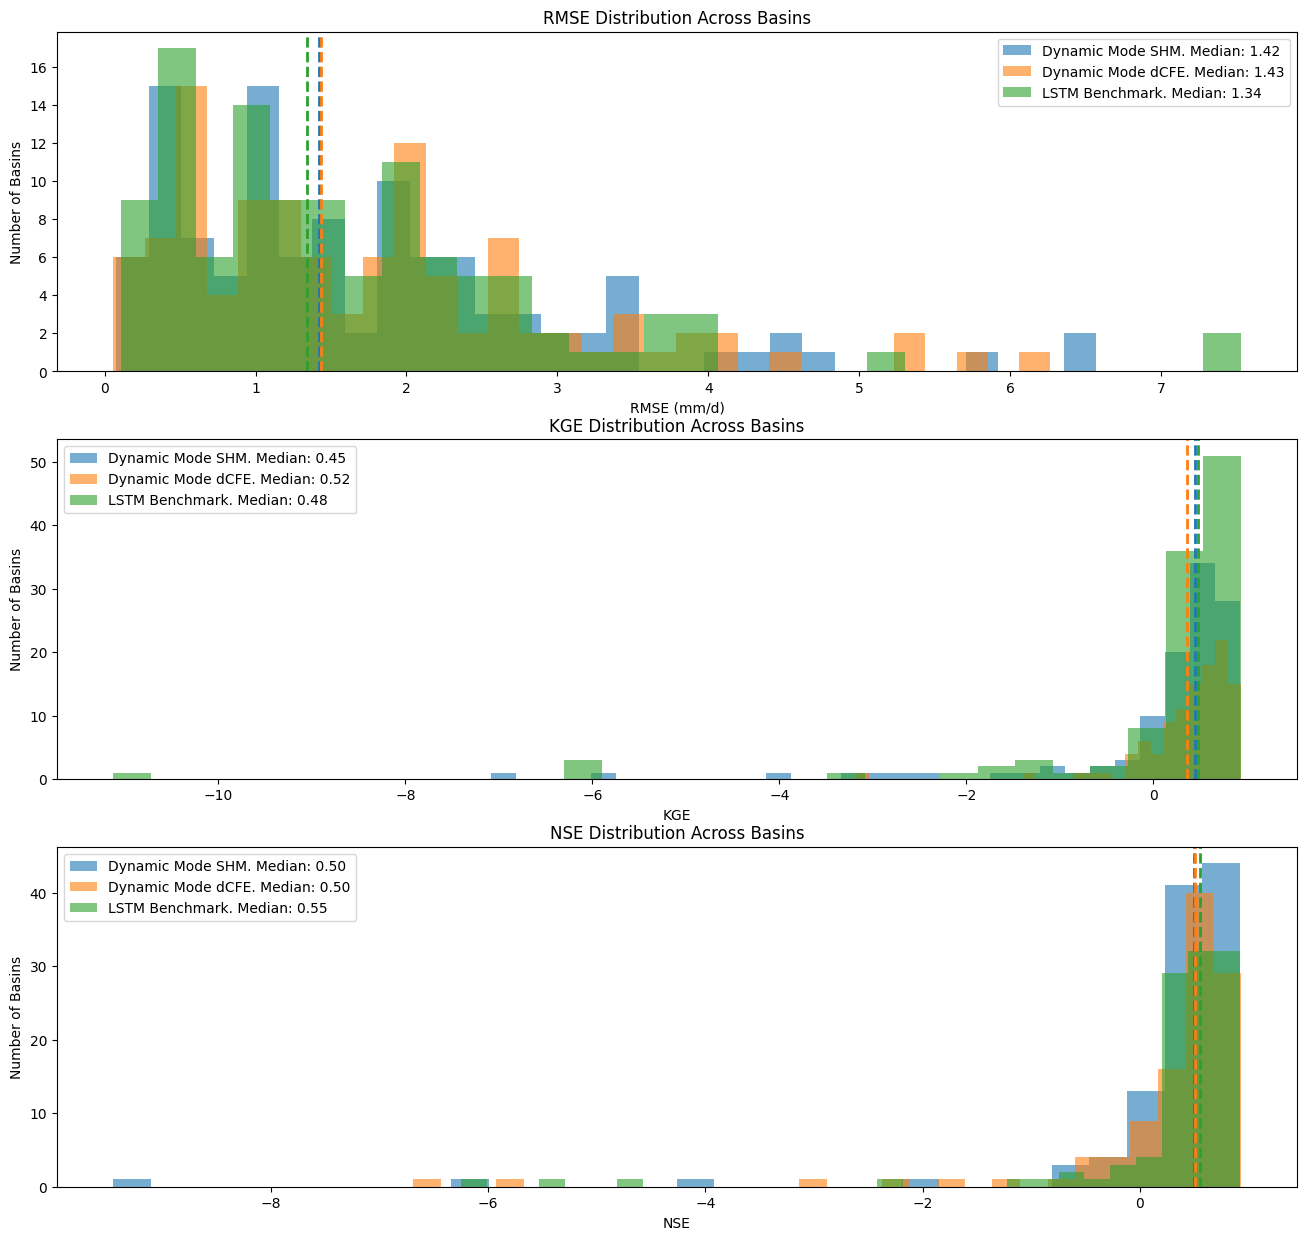

In [47]:
num_bins = 30
a = 0.6

fig, ax = plt.subplots(3, 1, figsize=(16,15))
ax[0].hist(shm_metrics['dynamic_rmse'], bins=num_bins, alpha=a, label='Dynamic Mode SHM. Median: {:.2f}'.format(shm_metrics['dynamic_rmse'].median()))
ax[0].axvline(shm_metrics['dynamic_rmse'].median(), color='tab:blue', linestyle='dashed', linewidth=2)
ax[0].hist(rmse_results['dynamic_rmse'], bins=num_bins, alpha=a, label='Dynamic Mode dCFE. Median: {:.2f}'.format(np.median(rmse_results['dynamic_rmse'])))
ax[0].axvline(np.median(rmse_results['dynamic_rmse']), color='tab:orange', linestyle='dashed', linewidth=2)
ax[0].hist(lstm_metric['rmse'], bins=num_bins, alpha=a, label='LSTM Benchmark. Median: {:.2f}'.format(lstm_metric['rmse'].median()))
ax[0].axvline(lstm_metric['rmse'].median(), color='tab:green', linestyle='dashed', linewidth=2)
ax[0].set_title("RMSE Distribution Across Basins")
ax[0].set_xlabel("RMSE (mm/d)")
ax[0].set_ylabel("Number of Basins")
ax[0].legend() 

ax[1].hist(shm_metrics['dynamic_kge'], bins=num_bins, alpha=a, label='Dynamic Mode SHM. Median: {:.2f}'.format(shm_metrics['dynamic_kge'].median()))
ax[1].axvline(shm_metrics['dynamic_kge'].median(), color='tab:blue', linestyle='dashed', linewidth=2)
ax[1].hist(kge_results['dynamic_kge'], bins=num_bins, alpha=a, label='Dynamic Mode dCFE. Median: {:.2f}'.format(np.median(kge_results['dynamic_kge'])))
ax[1].axvline(np.median(kge_results['oracle_kge']), color='tab:orange', linestyle='dashed', linewidth=2)
ax[1].hist(lstm_metric['kge'], bins=num_bins, alpha=a, label='LSTM Benchmark. Median: {:.2f}'.format(lstm_metric['kge'].median()))
ax[1].axvline(lstm_metric['kge'].median(), color='tab:green', linestyle='dashed', linewidth=2)
ax[1].set_title("KGE Distribution Across Basins")
ax[1].set_xlabel("KGE")
ax[1].set_ylabel("Number of Basins")
ax[1].legend() 

ax[2].hist(shm_metrics['dynamic_nse'], bins=30, alpha=a, label='Dynamic Mode SHM. Median: {:.2f}'.format(shm_metrics['dynamic_nse'].median()))
ax[2].axvline(shm_metrics['dynamic_nse'].median(), color='tab:blue', linestyle='dashed', linewidth=2)
ax[2].hist(nse_results['dynamic_nse'], bins=30, alpha=a, label='Dynamic Mode dCFE. Median: {:.2f}'.format(np.median(nse_results['dynamic_nse'])))
ax[2].axvline(np.median(nse_results['dynamic_nse']), color='tab:orange', linestyle='dashed', linewidth=2)
ax[2].hist(lstm_metric['nse'], bins=30, alpha=a, label='LSTM Benchmark. Median: {:.2f}'.format(lstm_metric['nse'].median()))
ax[2].axvline(lstm_metric['nse'].median(), color='tab:green', linestyle='dashed', linewidth=2)
ax[2].set_title("NSE Distribution Across Basins")
ax[2].set_xlabel("NSE")
ax[2].set_ylabel("Number of Basins")
ax[2].legend()

# 516 Basin Model Comparison: Snow-dCFE, SHM, LSTM

In [174]:
import pickle
from pathlib import Path
import pandas as pd
import numpy as np
import torch.nn as nn

from neuralhydrology.utils.config import Config

import matplotlib.pyplot as plt
import torch
from neuralhydrology.evaluation import metrics
from neuralhydrology.nh_run import start_run, eval_run

from neuralhydrology.evaluation.metrics import nse, rmse, kge
import xarray as xr

In [175]:
full_basin_lstm_benchmark_path = Path("runs/full_basin_lstm_benchmark_2104_113951")
with open(full_basin_lstm_benchmark_path / "test" / "model_epoch030" / "test_results.p", "rb") as fp:
    full_basin_lstm_benchmark_results = pickle.load(fp)
full_basin_shm_dynamic_path = Path("runs/full_basin_shm_dynamic_0704_132346")
with open(full_basin_shm_dynamic_path / "test" / "model_epoch030" / "test_results.p", "rb") as fp:
    full_basin_shm_dynamic_results = pickle.load(fp)
full_basin_shm_oracle_path = Path("runs/full_basin_shm_oracle_0804_111444")
with open(full_basin_shm_oracle_path / "test" / "model_epoch030" / "test_results.p", "rb") as fp:
    full_basin_shm_oracle_results = pickle.load(fp)
full_basin_shm_operational_path = Path("runs/full_basin_shm_operational_0704_184439")
with open(full_basin_shm_operational_path / "test" / "model_epoch030" / "test_results.p", "rb") as fp:
    full_basin_shm_operational_results = pickle.load(fp)
full_basin_snow_dcfe_dynamic_path = Path("runs/full_basin_snow_dcfe_dynamic_0304_175915")
with open(full_basin_snow_dcfe_dynamic_path / "test" / "model_epoch030" / "test_results.p", "rb") as fp:
    full_basin_snow_dcfe_dynamic_results = pickle.load(fp)
full_basin_snow_dcfe_oracle_path = Path("runs/full_basin_snow_dcfe_oracle_1704_143814")
with open(full_basin_snow_dcfe_oracle_path / "test" / "model_epoch030" / "test_results.p", "rb") as fp:
    full_basin_snow_dcfe_oracle_results = pickle.load(fp)
full_basin_snow_dcfe_operational_path = Path("runs/full_basin_snow_dcfe_operational_0704_111017")
with open(full_basin_snow_dcfe_operational_path / "test" / "model_epoch030" / "test_results.p", "rb") as fp:
    full_basin_snow_dcfe_operational_results = pickle.load(fp)
basin_keys = list(full_basin_shm_dynamic_results.keys())

## Select Basin Comparison

<xarray.DataArray 'date' (date: 1461)> Size: 12kB
array(['1998-10-01T00:00:00.000000000', '1998-10-02T00:00:00.000000000',
       '1998-10-03T00:00:00.000000000', ..., '2002-09-28T00:00:00.000000000',
       '2002-09-29T00:00:00.000000000', '2002-09-30T00:00:00.000000000'],
      dtype='datetime64[ns]')
Coordinates:
  * date     (date) datetime64[ns] 12kB 1998-10-01 1998-10-02 ... 2002-09-30

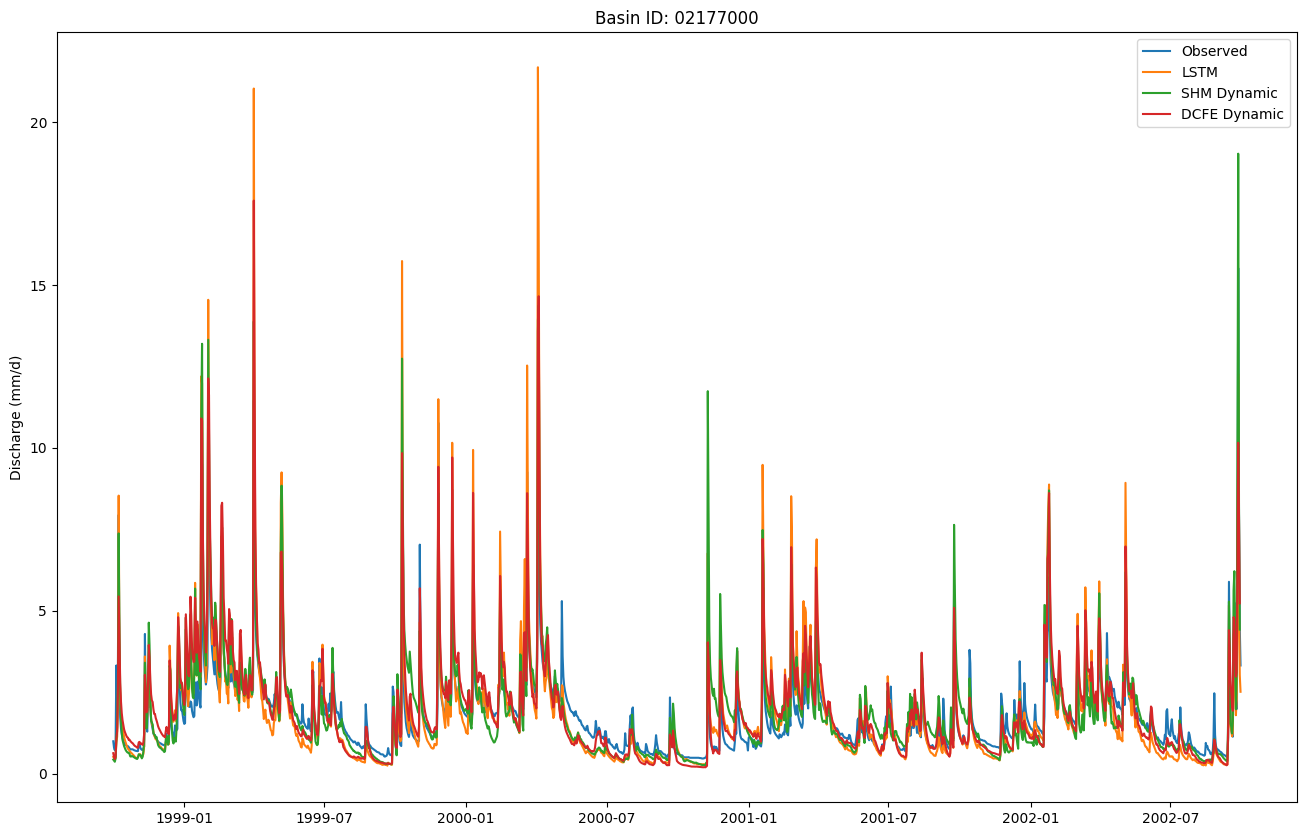

In [176]:
basin_id = '02177000'
date_lstm = full_basin_lstm_benchmark_results[basin_id]['1D']['xr'].coords['date']
observed = full_basin_lstm_benchmark_results[basin_id]['1D']['xr']['QObs(mm/d)_obs']
lstm_simulated = full_basin_lstm_benchmark_results[basin_id]['1D']['xr']['QObs(mm/d)_sim']
date_conceptual = full_basin_shm_dynamic_results['02177000']['1D']['xr'].coords['datetime']
shm_dynamic_simulated = full_basin_shm_dynamic_results[basin_id]['1D']['xr']['QObs(mm/d)_sim']
dcfe_dynamic_simulated = full_basin_snow_dcfe_dynamic_results[basin_id]['1D']['xr']['QObs(mm/d)_sim']

fig, ax = plt.subplots(figsize=(16,10))
ax.plot(date_lstm, observed, label='Observed')
ax.plot(date_lstm, lstm_simulated, label='LSTM')
ax.plot(date_conceptual, shm_dynamic_simulated, label='SHM Dynamic')
ax.plot(date_conceptual, dcfe_dynamic_simulated, label='DCFE Dynamic')
ax.set_ylabel("Discharge (mm/d)")
ax.set_title(f"Basin ID: {basin_id}")
ax.legend()
full_basin_lstm_benchmark_results[basin_keys[0]]['1D']['xr'].coords['date']

## Runoff
First, calcualte metrics for each of them. 

In [20]:
## NO NOT RUN

full_basin_metrics = {}

for basin in basin_keys:
    full_basin_metrics[basin] = {
        "lstm": {
            "nse": nse(xr.DataArray(full_basin_lstm_benchmark_results[basin]['1D']['xr']['QObs(mm/d)_obs'].squeeze(drop=True)),
                        xr.DataArray(full_basin_lstm_benchmark_results[basin]['1D']['xr']['QObs(mm/d)_sim'].squeeze(drop=True))),
            "rmse": rmse(xr.DataArray(full_basin_lstm_benchmark_results[basin]['1D']['xr']['QObs(mm/d)_obs'].squeeze(drop=True)),
                         xr.DataArray(full_basin_lstm_benchmark_results[basin]['1D']['xr']['QObs(mm/d)_sim'].squeeze(drop=True))),
            "kge": kge(xr.DataArray(full_basin_lstm_benchmark_results[basin]['1D']['xr']['QObs(mm/d)_obs'].squeeze(drop=True)),
                       xr.DataArray(full_basin_lstm_benchmark_results[basin]['1D']['xr']['QObs(mm/d)_sim'].squeeze(drop=True)))
        },
        "shm_dynamic": {
            "nse": nse(xr.DataArray(full_basin_shm_dynamic_results[basin]['1D']['xr']['QObs(mm/d)_obs'].squeeze(drop=True)),
                        xr.DataArray(full_basin_shm_dynamic_results[basin]['1D']['xr']['QObs(mm/d)_sim'].squeeze(drop=True))),
            "rmse": rmse(xr.DataArray(full_basin_shm_dynamic_results[basin]['1D']['xr']['QObs(mm/d)_obs'].squeeze(drop=True)),
                         xr.DataArray(full_basin_shm_dynamic_results[basin]['1D']['xr']['QObs(mm/d)_sim'].squeeze(drop=True))),
            "kge": kge(xr.DataArray(full_basin_shm_dynamic_results[basin]['1D']['xr']['QObs(mm/d)_obs'].squeeze(drop=True)),
                       xr.DataArray(full_basin_shm_dynamic_results[basin]['1D']['xr']['QObs(mm/d)_sim'].squeeze(drop=True)))
        },
        "shm_operational": {
            "nse": nse(xr.DataArray(full_basin_shm_operational_results[basin]['1D']['xr']['QObs(mm/d)_obs'].squeeze(drop=True)),
                        xr.DataArray(full_basin_shm_operational_results[basin]['1D']['xr']['QObs(mm/d)_sim'].squeeze(drop=True))),
            "rmse": rmse(xr.DataArray(full_basin_shm_operational_results[basin]['1D']['xr']['QObs(mm/d)_obs'].squeeze(drop=True)),
                         xr.DataArray(full_basin_shm_operational_results[basin]['1D']['xr']['QObs(mm/d)_sim'].squeeze(drop=True))),
            "kge": kge(xr.DataArray(full_basin_shm_operational_results[basin]['1D']['xr']['QObs(mm/d)_obs'].squeeze(drop=True)),
                       xr.DataArray(full_basin_shm_operational_results[basin]['1D']['xr']['QObs(mm/d)_sim'].squeeze(drop=True)))
        },
        "shm_oracle": {
            "nse": nse(xr.DataArray(full_basin_shm_oracle_results[basin]['1D']['xr']['QObs(mm/d)_obs'].squeeze(drop=True)),
                        xr.DataArray(full_basin_shm_oracle_results[basin]['1D']['xr']['QObs(mm/d)_sim'].squeeze(drop=True))),
            "rmse": rmse(xr.DataArray(full_basin_shm_oracle_results[basin]['1D']['xr']['QObs(mm/d)_obs'].squeeze(drop=True)),
                         xr.DataArray(full_basin_shm_oracle_results[basin]['1D']['xr']['QObs(mm/d)_sim'].squeeze(drop=True))),
            "kge": kge(xr.DataArray(full_basin_shm_oracle_results[basin]['1D']['xr']['QObs(mm/d)_obs'].squeeze(drop=True)),
                       xr.DataArray(full_basin_shm_oracle_results[basin]['1D']['xr']['QObs(mm/d)_sim'].squeeze(drop=True)))
        },
        "snow_dcfe_dynamic": {
            "nse": nse(xr.DataArray(full_basin_snow_dcfe_dynamic_results[basin]['1D']['xr']['QObs(mm/d)_obs'].squeeze(drop=True)),
                        xr.DataArray(full_basin_snow_dcfe_dynamic_results[basin]['1D']['xr']['QObs(mm/d)_sim'].squeeze(drop=True))),
            "rmse": rmse(xr.DataArray(full_basin_snow_dcfe_dynamic_results[basin]['1D']['xr']['QObs(mm/d)_obs'].squeeze(drop=True)),
                         xr.DataArray(full_basin_snow_dcfe_dynamic_results[basin]['1D']['xr']['QObs(mm/d)_sim'].squeeze(drop=True))),
            "kge": kge(xr.DataArray(full_basin_snow_dcfe_dynamic_results[basin]['1D']['xr']['QObs(mm/d)_obs'].squeeze(drop=True)),
                       xr.DataArray(full_basin_snow_dcfe_dynamic_results[basin]['1D']['xr']['QObs(mm/d)_sim'].squeeze(drop=True)))
        },
        "snow_dcfe_operational": {
            "nse": nse(xr.DataArray(full_basin_snow_dcfe_operational_results[basin]['1D']['xr']['QObs(mm/d)_obs'].squeeze(drop=True)),
                        xr.DataArray(full_basin_snow_dcfe_operational_results[basin]['1D']['xr']['QObs(mm/d)_sim'].squeeze(drop=True))),
            "rmse": rmse(xr.DataArray(full_basin_snow_dcfe_operational_results[basin]['1D']['xr']['QObs(mm/d)_obs'].squeeze(drop=True)),
                         xr.DataArray(full_basin_snow_dcfe_operational_results[basin]['1D']['xr']['QObs(mm/d)_sim'].squeeze(drop=True))),
            "kge": kge(xr.DataArray(full_basin_snow_dcfe_operational_results[basin]['1D']['xr']['QObs(mm/d)_obs'].squeeze(drop=True)),
                       xr.DataArray(full_basin_snow_dcfe_operational_results[basin]['1D']['xr']['QObs(mm/d)_sim'].squeeze(drop=True)))
        },
        "snow_dcfe_oracle": {
            "nse": nse(xr.DataArray(full_basin_snow_dcfe_oracle_results[basin]['1D']['xr']['QObs(mm/d)_obs'].squeeze(drop=True)),
                        xr.DataArray(full_basin_snow_dcfe_oracle_results[basin]['1D']['xr']['QObs(mm/d)_sim'].squeeze(drop=True))),
            "rmse": rmse(xr.DataArray(full_basin_snow_dcfe_oracle_results[basin]['1D']['xr']['QObs(mm/d)_obs'].squeeze(drop=True)),
                         xr.DataArray(full_basin_snow_dcfe_oracle_results[basin]['1D']['xr']['QObs(mm/d)_sim'].squeeze(drop=True))),
            "kge": kge(xr.DataArray(full_basin_snow_dcfe_oracle_results[basin]['1D']['xr']['QObs(mm/d)_obs'].squeeze(drop=True)),
                       xr.DataArray(full_basin_snow_dcfe_oracle_results[basin]['1D']['xr']['QObs(mm/d)_sim'].squeeze(drop=True)))
        }
    }

with open("full_basin_metrics.pkl", "wb") as f:
    pickle.dump(full_basin_metrics, f)

In [177]:
with open("full_basin_metrics.pkl", "rb") as f:
    full_basin_metrics = pickle.load(f)

### Dynamic Hybrid vs. LSTM
Comparing each modes of the models to LSTM benchmark.

In [178]:
# Compile dynamic metrics into dataframe for easier analysis
dynamic_metrics_df = pd.DataFrame({
    "basin": basin_keys,
    "lstm_nse": [full_basin_metrics[basin]['lstm']['nse'] for basin in basin_keys],
    "lstm_rmse": [full_basin_metrics[basin]['lstm']['rmse'] for basin in basin_keys],
    "lstm_kge": [full_basin_metrics[basin]['lstm']['kge'] for basin in basin_keys],
    "shm_dynamic_nse": [full_basin_metrics[basin]['shm_dynamic']['nse'] for basin in basin_keys],
    "shm_dynamic_rmse": [full_basin_metrics[basin]['shm_dynamic']['rmse'] for basin in basin_keys],
    "shm_dynamic_kge": [full_basin_metrics[basin]['shm_dynamic']['kge'] for basin in basin_keys],
    "snow_dcfe_dynamic_nse": [full_basin_metrics[basin]['snow_dcfe_dynamic']['nse'] for basin in basin_keys],
    "snow_dcfe_dynamic_rmse": [full_basin_metrics[basin]['snow_dcfe_dynamic']['rmse'] for basin in basin_keys],
    "snow_dcfe_dynamic_kge": [full_basin_metrics[basin]['snow_dcfe_dynamic']['kge'] for basin in basin_keys]
}).set_index("basin")

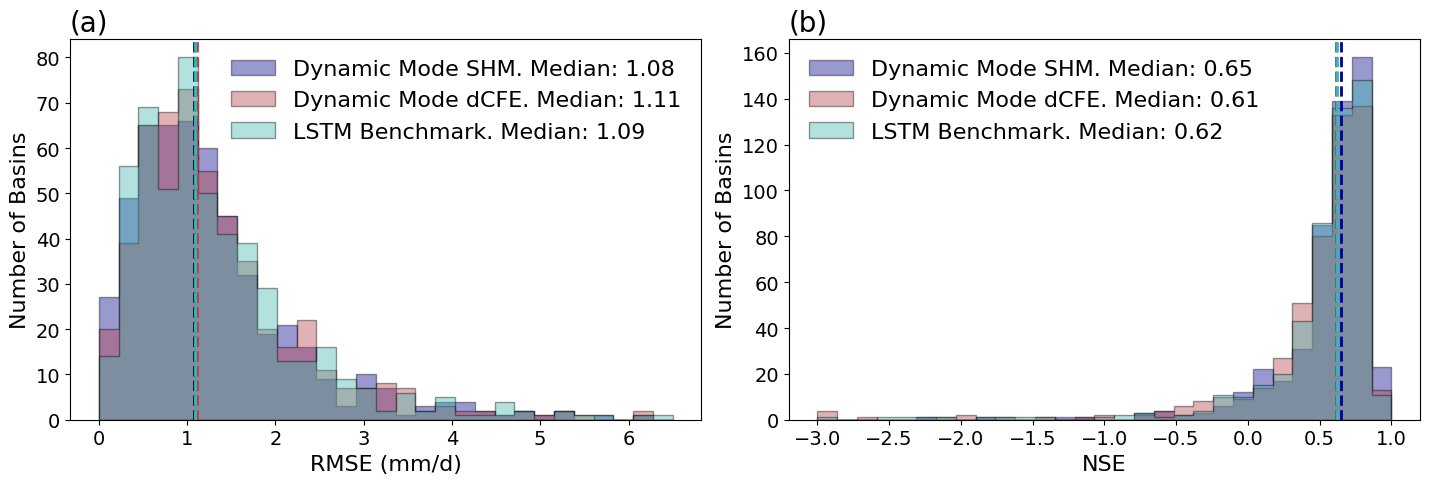

In [185]:
## DO NOT RUN - This is for plotting for EGU Poster
num_bins = 30
a = 0.4
brownish_red = '#B54048'
dark_blue = '#00008B'
teal = '#40B5AD'

fig, ax = plt.subplots(1, 2, figsize=(16,6))
bins_0 = np.linspace(0, 6.5, num_bins)
ax[0].hist(dynamic_metrics_df['shm_dynamic_rmse'], bins=bins_0, alpha=a, color=dark_blue,histtype='stepfilled', edgecolor='black',
           label='Dynamic Mode SHM. Median: {:.2f}'.format(dynamic_metrics_df['shm_dynamic_rmse'].median()))
ax[0].axvline(dynamic_metrics_df['shm_dynamic_rmse'].median(), color=dark_blue, linestyle='dashed', linewidth=2)
ax[0].hist(dynamic_metrics_df['snow_dcfe_dynamic_rmse'], bins=bins_0, alpha=a, color=brownish_red, histtype='stepfilled', edgecolor='black',
           label='Dynamic Mode dCFE. Median: {:.2f}'.format(dynamic_metrics_df['snow_dcfe_dynamic_rmse'].median()))
ax[0].axvline(dynamic_metrics_df['snow_dcfe_dynamic_rmse'].median(), color=brownish_red, linestyle='dashed', linewidth=2)
ax[0].hist(dynamic_metrics_df['lstm_rmse'], bins=bins_0, alpha=a, color=teal, histtype='stepfilled', edgecolor='black',
           label='LSTM Benchmark. Median: {:.2f}'.format(dynamic_metrics_df['lstm_rmse'].median()))
ax[0].axvline(dynamic_metrics_df['lstm_rmse'].median(), color=teal, linestyle='dashed', linewidth=2)
ax[0].set_title("(a)", loc='left', fontsize = 20)
ax[0].set_xlabel("RMSE (mm/d)")
ax[0].set_ylabel("Number of Basins")
ax[0].legend() 

bins_2 = np.linspace(-3, 1, num_bins)
ax[1].hist(dynamic_metrics_df['shm_dynamic_nse'], bins=bins_2, alpha=a, color=dark_blue, histtype='stepfilled', edgecolor='black',
           label='Dynamic Mode SHM. Median: {:.2f}'.format(dynamic_metrics_df['shm_dynamic_nse'].median()))
ax[1].axvline(dynamic_metrics_df['shm_dynamic_nse'].median(), color=dark_blue, linestyle='dashed', linewidth=2)
ax[1].hist(dynamic_metrics_df['snow_dcfe_dynamic_nse'], bins=bins_2, alpha=a, color=brownish_red, histtype='stepfilled', edgecolor='black',
           label='Dynamic Mode dCFE. Median: {:.2f}'.format(dynamic_metrics_df['snow_dcfe_dynamic_nse'].median()))
ax[1].axvline(dynamic_metrics_df['snow_dcfe_dynamic_nse'].median(), color=brownish_red, linestyle='dashed', linewidth=2)
ax[1].hist(dynamic_metrics_df['lstm_nse'], bins=bins_2, alpha=a, color=teal, histtype='stepfilled', edgecolor='black',
           label='LSTM Benchmark. Median: {:.2f}'.format(dynamic_metrics_df['lstm_nse'].median()))
ax[1].axvline(dynamic_metrics_df['lstm_nse'].median(), color=teal, linestyle='dashed', linewidth=2)
ax[1].set_title("(b)", loc='left', fontsize = 20)
ax[1].set_xlabel("NSE")
ax[1].set_ylabel("Number of Basins")
ax[1].legend()

for a in ax:
    a.set_xlabel(a.get_xlabel(), fontsize=16)
    a.set_ylabel(a.get_ylabel(), fontsize=16)
    a.tick_params(axis='both', labelsize=14)
    a.legend(fontsize=16, frameon=False)

plt.tight_layout(rect=[0, 0.075, 0.9, 0.9])
plt.savefig(r"/Users/ziyu/Library/CloudStorage/OneDrive-ColoradoSchoolofMines/Documents/College/ResearchStuff/NextGen/Conference/EGU2026/Poster/Images/LSTM_Comparison.pdf",
            bbox_inches="tight")

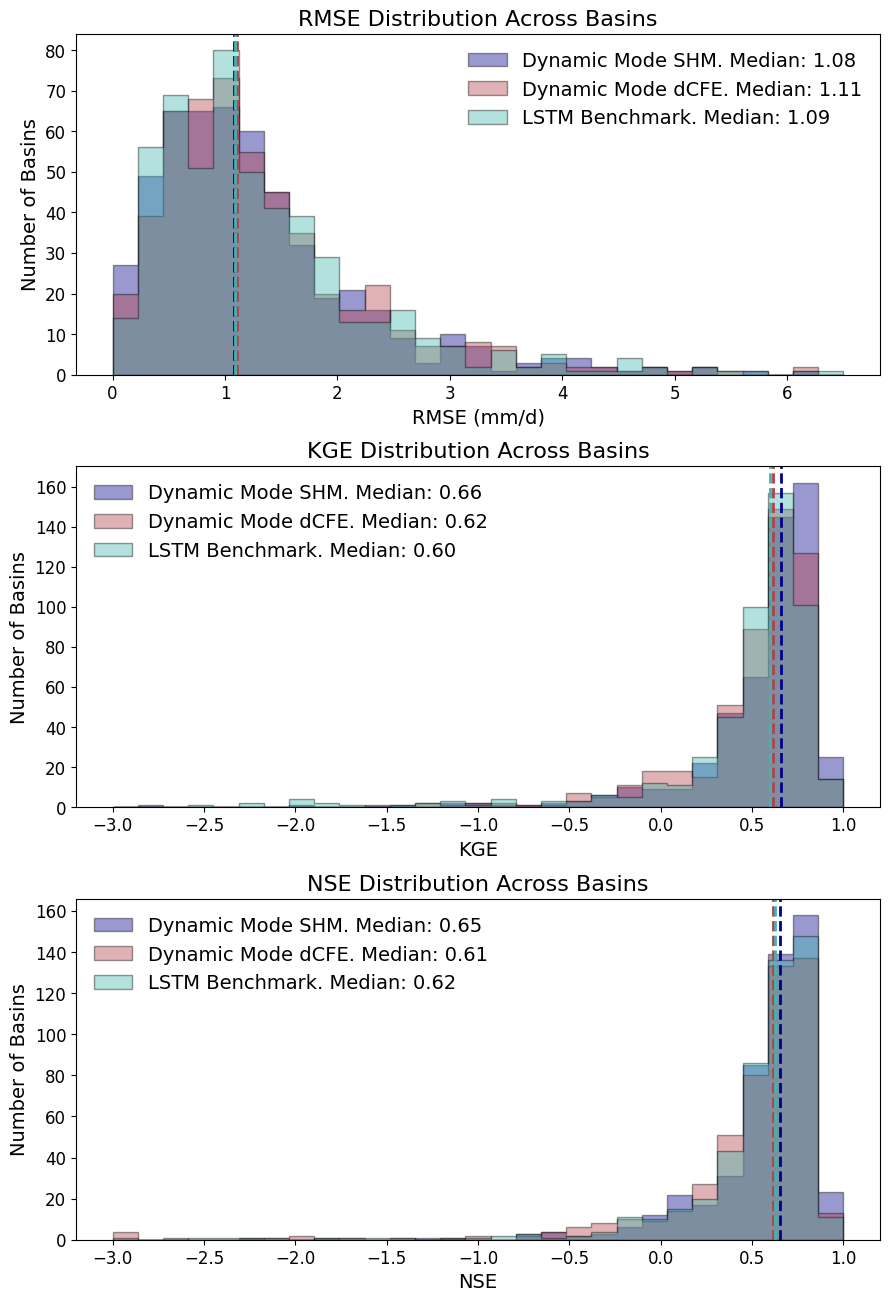

In [ ]:
num_bins = 30
a = 0.4
brownish_red = '#B54048'
dark_blue = '#00008B'
teal = '#40B5AD'

fig, ax = plt.subplots(3, 1, figsize=(10,15))
bins_0 = np.linspace(0, 6.5, num_bins)
ax[0].hist(dynamic_metrics_df['shm_dynamic_rmse'], bins=bins_0, alpha=a, color=dark_blue,histtype='stepfilled', edgecolor='black',
           label='Dynamic Mode SHM. Median: {:.2f}'.format(dynamic_metrics_df['shm_dynamic_rmse'].median()))
ax[0].axvline(dynamic_metrics_df['shm_dynamic_rmse'].median(), color=dark_blue, linestyle='dashed', linewidth=2)
ax[0].hist(dynamic_metrics_df['snow_dcfe_dynamic_rmse'], bins=bins_0, alpha=a, color=brownish_red, histtype='stepfilled', edgecolor='black',
           label='Dynamic Mode dCFE. Median: {:.2f}'.format(dynamic_metrics_df['snow_dcfe_dynamic_rmse'].median()))
ax[0].axvline(dynamic_metrics_df['snow_dcfe_dynamic_rmse'].median(), color=brownish_red, linestyle='dashed', linewidth=2)
ax[0].hist(dynamic_metrics_df['lstm_rmse'], bins=bins_0, alpha=a, color=teal, histtype='stepfilled', edgecolor='black',
           label='LSTM Benchmark. Median: {:.2f}'.format(dynamic_metrics_df['lstm_rmse'].median()))
ax[0].axvline(dynamic_metrics_df['lstm_rmse'].median(), color=teal, linestyle='dashed', linewidth=2)
ax[0].set_title("RMSE Distribution Across Basins")
ax[0].set_xlabel("RMSE (mm/d)")
ax[0].set_ylabel("Number of Basins")
ax[0].legend() 

bins_1 = np.linspace(-3, 1, num_bins)
ax[1].hist(dynamic_metrics_df['shm_dynamic_kge'], bins=bins_1, alpha=a, color=dark_blue, histtype='stepfilled', edgecolor='black',
           label='Dynamic Mode SHM. Median: {:.2f}'.format(dynamic_metrics_df['shm_dynamic_kge'].median()))
ax[1].axvline(dynamic_metrics_df['shm_dynamic_kge'].median(), color=dark_blue, linestyle='dashed', linewidth=2)
ax[1].hist(dynamic_metrics_df['snow_dcfe_dynamic_kge'], bins=bins_1, alpha=a, color=brownish_red, histtype='stepfilled', edgecolor='black',
           label='Dynamic Mode dCFE. Median: {:.2f}'.format(dynamic_metrics_df['snow_dcfe_dynamic_kge'].median()))
ax[1].axvline(dynamic_metrics_df['snow_dcfe_dynamic_kge'].median(), color=brownish_red, linestyle='dashed', linewidth=2)
ax[1].hist(dynamic_metrics_df['lstm_kge'], bins=bins_1, alpha=a, color=teal, histtype='stepfilled', edgecolor='black',
           label='LSTM Benchmark. Median: {:.2f}'.format(dynamic_metrics_df['lstm_kge'].median()))
ax[1].axvline(dynamic_metrics_df['lstm_kge'].median(), color=teal, linestyle='dashed', linewidth=2)
ax[1].set_title("KGE Distribution Across Basins")
ax[1].set_xlabel("KGE")
ax[1].set_ylabel("Number of Basins")
ax[1].legend() 

bins_2 = np.linspace(-3, 1, num_bins)
ax[2].hist(dynamic_metrics_df['shm_dynamic_nse'], bins=bins_2, alpha=a, color=dark_blue, histtype='stepfilled', edgecolor='black',
           label='Dynamic Mode SHM. Median: {:.2f}'.format(dynamic_metrics_df['shm_dynamic_nse'].median()))
ax[2].axvline(dynamic_metrics_df['shm_dynamic_nse'].median(), color=dark_blue, linestyle='dashed', linewidth=2)
ax[2].hist(dynamic_metrics_df['snow_dcfe_dynamic_nse'], bins=bins_2, alpha=a, color=brownish_red, histtype='stepfilled', edgecolor='black',
           label='Dynamic Mode dCFE. Median: {:.2f}'.format(dynamic_metrics_df['snow_dcfe_dynamic_nse'].median()))
ax[2].axvline(dynamic_metrics_df['snow_dcfe_dynamic_nse'].median(), color=brownish_red, linestyle='dashed', linewidth=2)
ax[2].hist(dynamic_metrics_df['lstm_nse'], bins=bins_2, alpha=a, color=teal, histtype='stepfilled', edgecolor='black',
           label='LSTM Benchmark. Median: {:.2f}'.format(dynamic_metrics_df['lstm_nse'].median()))
ax[2].axvline(dynamic_metrics_df['lstm_nse'].median(), color=teal, linestyle='dashed', linewidth=2)
ax[2].set_title("NSE Distribution Across Basins")
ax[2].set_xlabel("NSE")
ax[2].set_ylabel("Number of Basins")
ax[2].legend()

for a in ax:
    a.set_title(a.get_title(), fontsize=16)
    a.set_xlabel(a.get_xlabel(), fontsize=14)
    a.set_ylabel(a.get_ylabel(), fontsize=14)
    a.tick_params(axis='both', labelsize=12)
    a.legend(fontsize=14, frameon=False)

plt.tight_layout(rect=[0, 0.075, 0.9, 0.95])


### Averaging vs. Dynamic
Compare the modes of SHM and dCFE

In [186]:
# Compile oracle metrics into dataframe for easier analysis
oracle_metrics_df = pd.DataFrame({
    "basin": basin_keys,
    "shm_oracle_nse": [full_basin_metrics[basin]['shm_oracle']['nse'] for basin in basin_keys],
    "shm_oracle_rmse": [full_basin_metrics[basin]['shm_oracle']['rmse'] for basin in basin_keys],
    "shm_oracle_kge": [full_basin_metrics[basin]['shm_oracle']['kge'] for basin in basin_keys],
    "snow_dcfe_oracle_nse": [full_basin_metrics[basin]['snow_dcfe_oracle']['nse'] for basin in basin_keys],
    "snow_dcfe_oracle_rmse": [full_basin_metrics[basin]['snow_dcfe_oracle']['rmse'] for basin in basin_keys],
    "snow_dcfe_oracle_kge": [full_basin_metrics[basin]['snow_dcfe_oracle']['kge'] for basin in basin_keys]
}).set_index("basin")

operational_metrics_df = pd.DataFrame({
    "basin": basin_keys,
    "shm_operational_nse": [full_basin_metrics[basin]['shm_operational']['nse'] for basin in basin_keys],
    "shm_operational_rmse": [full_basin_metrics[basin]['shm_operational']['rmse'] for basin in basin_keys],
    "shm_operational_kge": [full_basin_metrics[basin]['shm_operational']['kge'] for basin in basin_keys],
    "snow_dcfe_operational_nse": [full_basin_metrics[basin]['snow_dcfe_operational']['nse'] for basin in basin_keys],
    "snow_dcfe_operational_rmse": [full_basin_metrics[basin]['snow_dcfe_operational']['rmse'] for basin in basin_keys],
    "snow_dcfe_operational_kge": [full_basin_metrics[basin]['snow_dcfe_operational']['kge'] for basin in basin_keys]
}).set_index("basin")

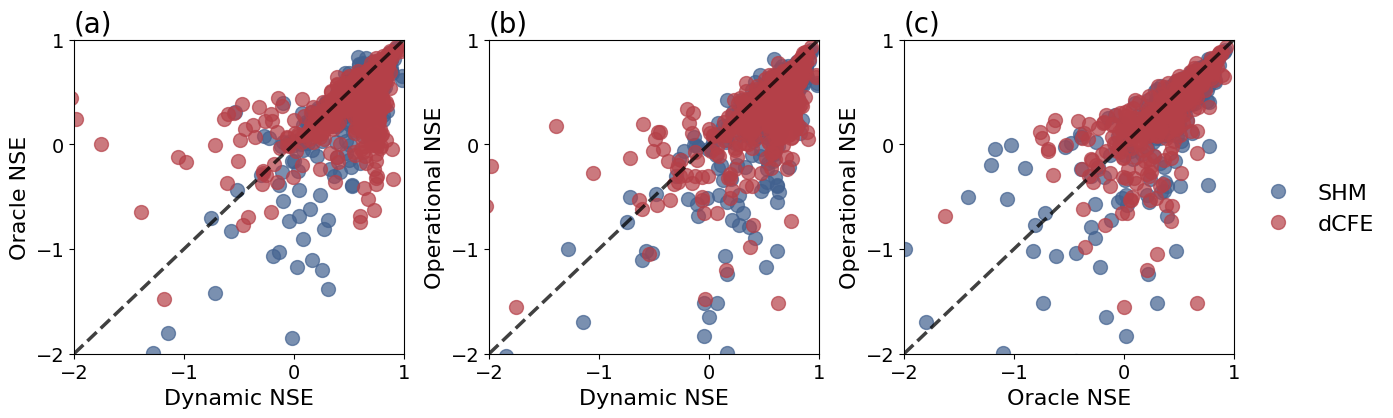

In [277]:
a = 0.7
lwd = 2.5
brownish_red = '#B54048'
dark_blue = '#42618F'

fig, ax = plt.subplots(1, 3, figsize=(14,4.9))
ax[0].plot(dynamic_metrics_df['shm_dynamic_nse'], oracle_metrics_df['shm_oracle_nse'], 'o',
           alpha = a, color=dark_blue, markersize=10, label='SHM')
ax[0].plot(dynamic_metrics_df['snow_dcfe_dynamic_nse'], oracle_metrics_df['snow_dcfe_oracle_nse'], 
           'o', alpha = a, color=brownish_red, markersize=10, label='dCFE')
ax[0].set_title("(a)", loc='left', fontsize = 20)
ax[0].set_xlabel("Dynamic NSE")
ax[0].set_ylabel("Oracle NSE")
ax[0].set_xlim(-2, 1)
ax[0].set_ylim(-2, 1)
ax[0].plot((-2, 1),(-2,1),'k--', alpha=0.75, zorder=5, linewidth = lwd)

ax[1].plot(dynamic_metrics_df['shm_dynamic_nse'], operational_metrics_df['shm_operational_nse'], 'o',
           alpha = a, color=dark_blue, markersize=10)
ax[1].plot(dynamic_metrics_df['snow_dcfe_dynamic_nse'], operational_metrics_df['snow_dcfe_operational_nse'], 
           'o', alpha = a, color=brownish_red, markersize=10)
ax[1].set_title("(b)", loc='left', fontsize = 20)
ax[1].set_xlabel("Dynamic NSE")
ax[1].set_ylabel("Operational NSE")
ax[1].set_xlim(-2, 1)
ax[1].set_ylim(-2, 1)
ax[1].plot((-2, 1),(-2,1),'k--', alpha=0.75, zorder=5, linewidth = lwd)

ax[2].plot(oracle_metrics_df['shm_oracle_nse'], operational_metrics_df['shm_operational_nse'], 'o',
           alpha = a, color=dark_blue, markersize=10)
ax[2].plot(oracle_metrics_df['snow_dcfe_oracle_nse'], operational_metrics_df['snow_dcfe_operational_nse'], 
           'o', alpha = a, color=brownish_red, markersize=10)
ax[2].set_title("(c)", loc='left', fontsize = 20)
ax[2].set_xlabel("Oracle NSE")
ax[2].set_ylabel("Operational NSE")
ax[2].set_xlim(-2, 1)
ax[2].set_ylim(-2, 1)
ax[2].plot((-2, 1),(-2,1),'k--', alpha=0.75, zorder=5, linewidth = lwd)

ticks = [-2, -1, 0, 1]
for a in ax:
    a.set_xlabel(a.get_xlabel(), fontsize=16)
    a.set_ylabel(a.get_ylabel(), fontsize=16)
    a.set_xticks(ticks)
    a.set_yticks(ticks)
    a.tick_params(axis='both', labelsize=14)
    
fig.legend(loc='right', ncol = 1, fontsize=16, frameon=False)
plt.tight_layout(rect=[0, 0.075, 0.9, 0.95])

plt.savefig(r"/Users/ziyu/Library/CloudStorage/OneDrive-ColoradoSchoolofMines/Documents/College/ResearchStuff/NextGen/Conference/EGU2026/Poster/Images/AvgModes_Comparison.pdf",
            bbox_inches="tight")

## SHM Param & States

In [18]:
with open(full_basin_shm_dynamic_path / "test" / "model_epoch030" / "test_all_output.p", "rb") as fp:
    full_dynamic_shm_all_results = pickle.load(fp)
with open(full_basin_shm_oracle_path / "test" / "model_epoch030" / "test_all_output.p", "rb") as fp:
    full_oracle_shm_all_results = pickle.load(fp)
with open(full_basin_shm_operational_path / "test" / "model_epoch030" / "test_all_output.p", "rb") as fp:
    full_operational_shm_all_results = pickle.load(fp)
    
# grab keys of parmeters and internal states
param_keys = list(full_dynamic_shm_all_results[basin_keys[0]]["spinup_parameters"].keys())
state_keys = list(full_dynamic_shm_all_results[basin_keys[0]]["spinup_internal_states"].keys())

### SHM Parameters


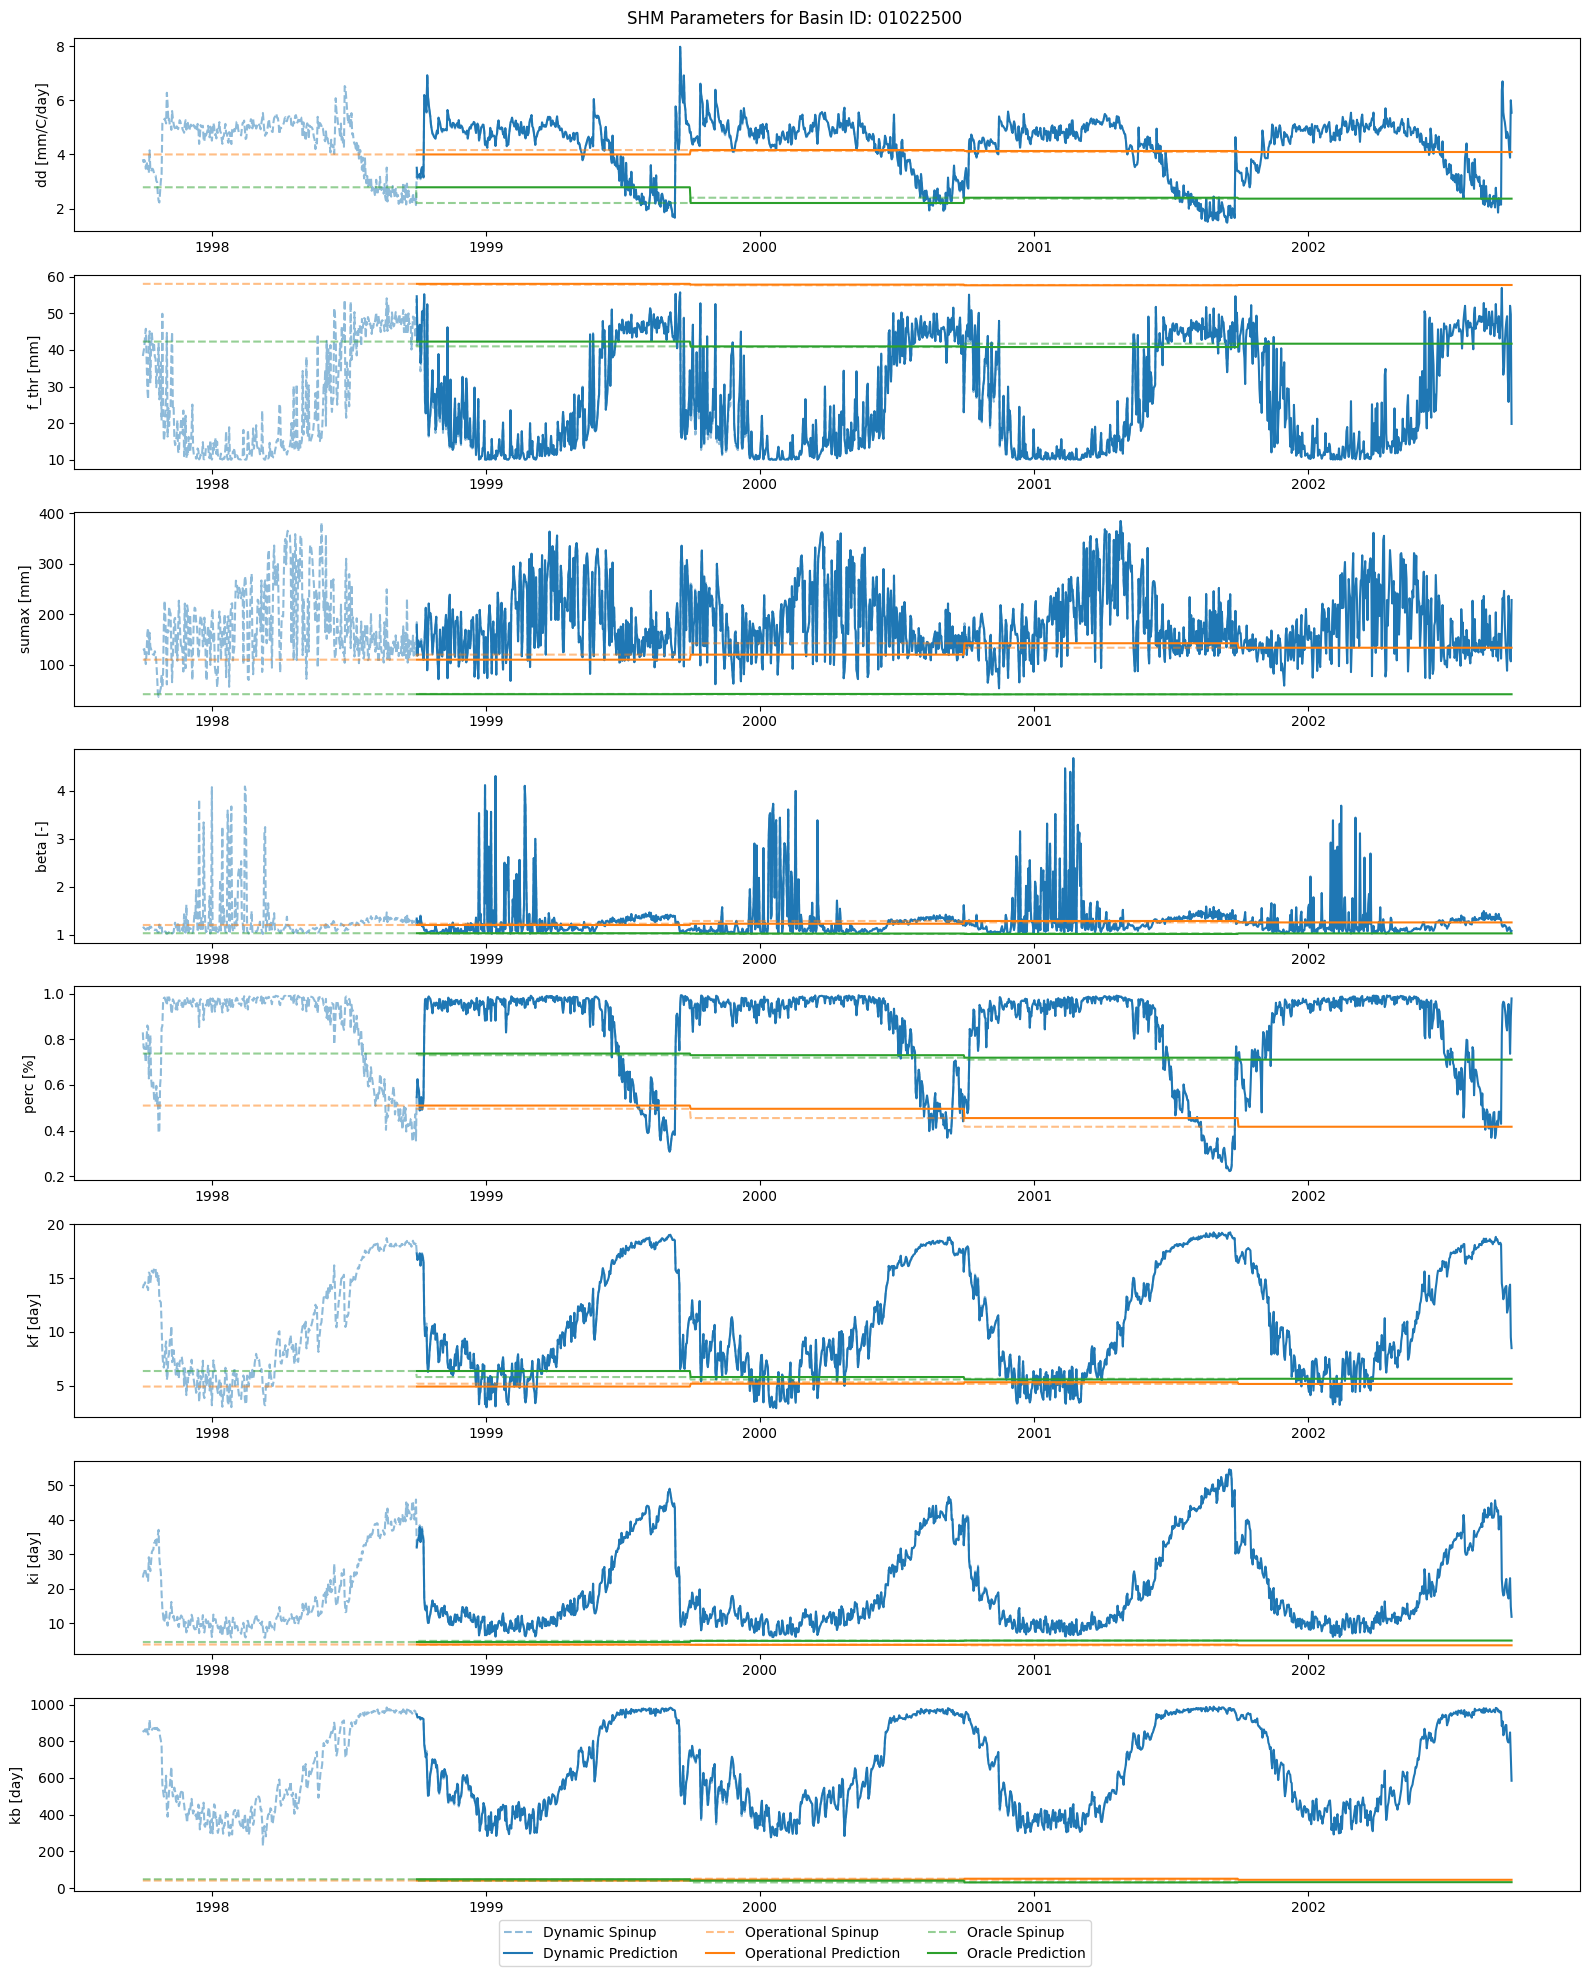

In [67]:
param_unit_keys = ['[mm/C/day]', '[mm]', '[mm]', '[-]', '[%]', '[day]', '[day]', '[day]']
basin = '01022500' #'02177000' #basin_keys[3]
param_dates = full_dynamic_shm_all_results['datetime']

fig, ax = plt.subplots(figsize=(16,2.5*len(param_keys)), nrows=len(param_keys), ncols=1)
for i, param_interest in enumerate(param_keys):
    label_dynamic_spinup = "Dynamic Spinup" if i == 0 else None
    label_dynamic_prediction = "Dynamic Prediction" if i == 0 else None
    label_operational_spinup = "Operational Spinup" if i == 0 else None
    label_operational_prediction = "Operational Prediction" if i == 0 else None
    label_oracle_spinup = "Oracle Spinup" if i == 0 else None
    label_oracle_prediction = "Oracle Prediction" if i == 0 else None
    ax[i].plot(param_dates, full_dynamic_shm_all_results[basin]["spinup_parameters"][param_interest], 
               color="tab:blue", label=label_dynamic_spinup, linestyle='--', alpha = 0.5)
    ax[i].plot(param_dates, full_dynamic_shm_all_results[basin]["prediction_parameters"][param_interest], 
               color="tab:blue", label=label_dynamic_prediction, linestyle='-')
    ax[i].plot(param_dates, full_operational_shm_all_results[basin]["spinup_parameters"][param_interest],
               color="tab:orange", label=label_operational_spinup, linestyle='--', alpha = 0.5)
    ax[i].plot(param_dates, full_operational_shm_all_results[basin]["prediction_parameters"][param_interest],
               color="tab:orange", label=label_operational_prediction, linestyle='-')
    ax[i].plot(param_dates, full_oracle_shm_all_results[basin]["spinup_parameters"][param_interest],
               color="tab:green", label=label_oracle_spinup, linestyle='--', alpha = 0.5)
    ax[i].plot(param_dates, full_oracle_shm_all_results[basin]["prediction_parameters"][param_interest],
               color="tab:green", label=label_oracle_prediction, linestyle='-')
    ax[i].set_ylabel(f"{param_interest} {param_unit_keys[i]}")
fig.legend(loc="lower center", ncol=3)
fig.suptitle(f"SHM Parameters for Basin ID: {basin}")
plt.tight_layout(rect=[0, 0.02, 1, 0.99])

### SHM Internal States

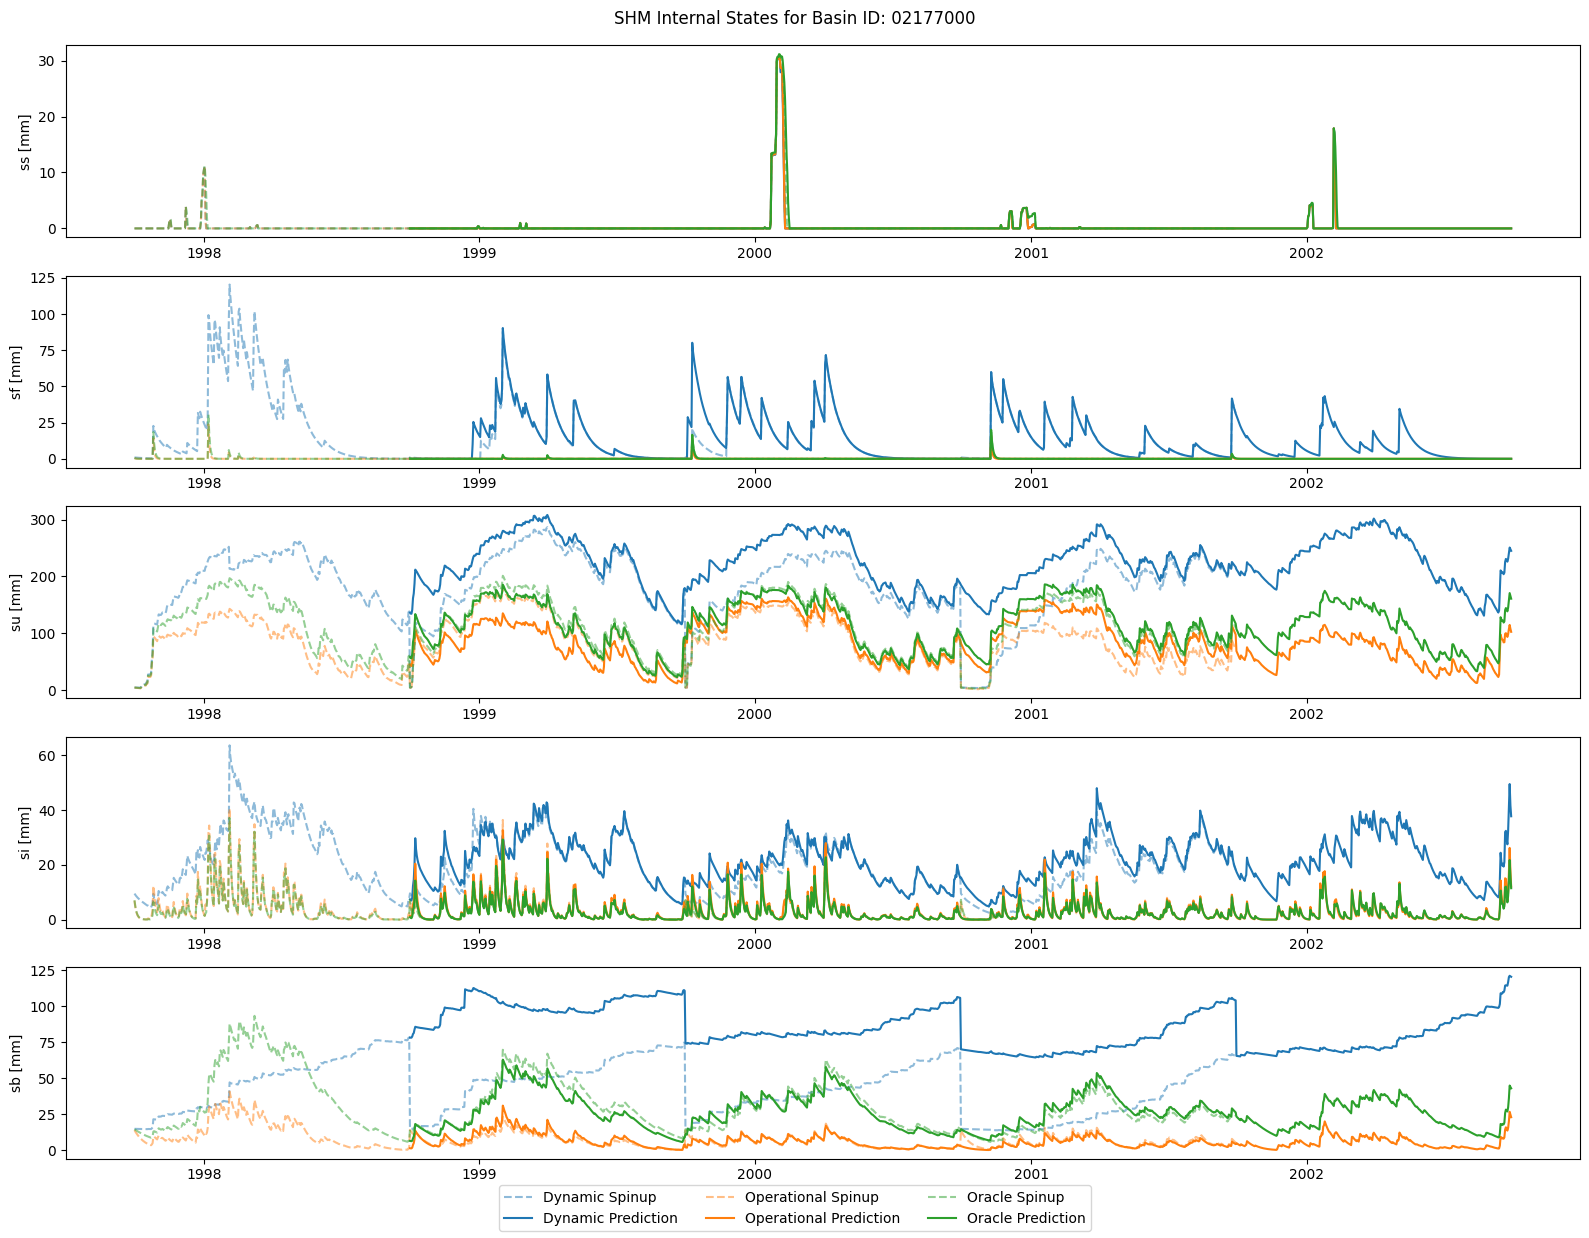

In [59]:
basin = '02177000' #basin_keys[3]
state_dates =full_dynamic_shm_all_results['datetime']
fig, ax = plt.subplots(figsize=(16,2.5*len(state_keys)), nrows=len(state_keys), ncols=1)
for i, state_interest in enumerate(state_keys):
    label_dynamic_spinup = "Dynamic Spinup" if i == 0 else None
    label_dynamic_prediction = "Dynamic Prediction" if i == 0 else None
    label_operational_spinup = "Operational Spinup" if i == 0 else None
    label_operational_prediction = "Operational Prediction" if i == 0 else None
    label_oracle_spinup = "Oracle Spinup" if i == 0 else None
    label_oracle_prediction = "Oracle Prediction" if i == 0 else None
    ax[i].plot(param_dates, full_dynamic_shm_all_results[basin]["spinup_internal_states"][state_interest], 
               color="tab:blue", label=label_dynamic_spinup, linestyle='--', alpha = 0.5)
    ax[i].plot(param_dates, full_dynamic_shm_all_results[basin]["prediction_internal_states"][state_interest], 
               color="tab:blue", label=label_dynamic_prediction, linestyle='-')
    ax[i].plot(param_dates, full_operational_shm_all_results[basin]["spinup_internal_states"][state_interest],
               color="tab:orange", label=label_operational_spinup, linestyle='--', alpha = 0.5)
    ax[i].plot(param_dates, full_operational_shm_all_results[basin]["prediction_internal_states"][state_interest],
               color="tab:orange", label=label_operational_prediction, linestyle='-')
    ax[i].plot(param_dates, full_oracle_shm_all_results[basin]["spinup_internal_states"][state_interest],
               color="tab:green", label=label_oracle_spinup, linestyle='--', alpha = 0.5)
    ax[i].plot(param_dates, full_oracle_shm_all_results[basin]["prediction_internal_states"][state_interest],
               color="tab:green", label=label_oracle_prediction, linestyle='-')
    ax[i].set_ylabel(f"{state_interest} [mm]")
fig.legend(loc="lower center", ncol=3)
fig.suptitle(f"SHM Internal States for Basin ID: {basin}")
plt.tight_layout(rect=[0, 0.03, 1, 0.99])


## Snow-dCFE Params & States
First, load the full output information.

In [349]:
with open(full_basin_snow_dcfe_dynamic_path / "test" / "model_epoch030" / "test_all_output.p", "rb") as fp:
    full_dynamic_dcfe_all_results = pickle.load(fp)
with open(full_basin_snow_dcfe_operational_path / "test" / "model_epoch030" / "test_all_output.p", "rb") as fp:
    full_operational_dcfe_all_results = pickle.load(fp)
with open(full_basin_snow_dcfe_oracle_path / "test" / "model_epoch030" / "test_all_output.p", "rb") as fp:
    full_oracle_dcfe_all_results = pickle.load(fp)
    
dcfe_param_keys = list(full_dynamic_dcfe_all_results[basin_keys[0]]["spinup_parameters"].keys())
dcfe_state_keys = list(full_dynamic_dcfe_all_results[basin_keys[0]]["spinup_internal_states"].keys())

### dCFE Parameters

The Snow-dCFE parameters are
* satdk: Saturated hydraulic conductivity [m/hr]
* Cgw: Primary groundwater reservoir constant [m/hr]
* bb: exponent on Clapp-Hornberg functin [-]
* smcmax: Max soil moisture content [m3/hr3]
* slop: slope coefficient [-]
* max_gw_storage: [m]
* expon: A primary groundwater nonlinear reservoir exponential constant [-]
* K_lf: Lateral flow coefficient [-]
* K_nash: Nash cascade discharge coefficient [-]
* satpsi: saturated capillary head [m]
* dd: degree day factor for snowmelt [mm °C−1 d−1]

In [22]:
len(full_dynamic_dcfe_all_results.keys())

517

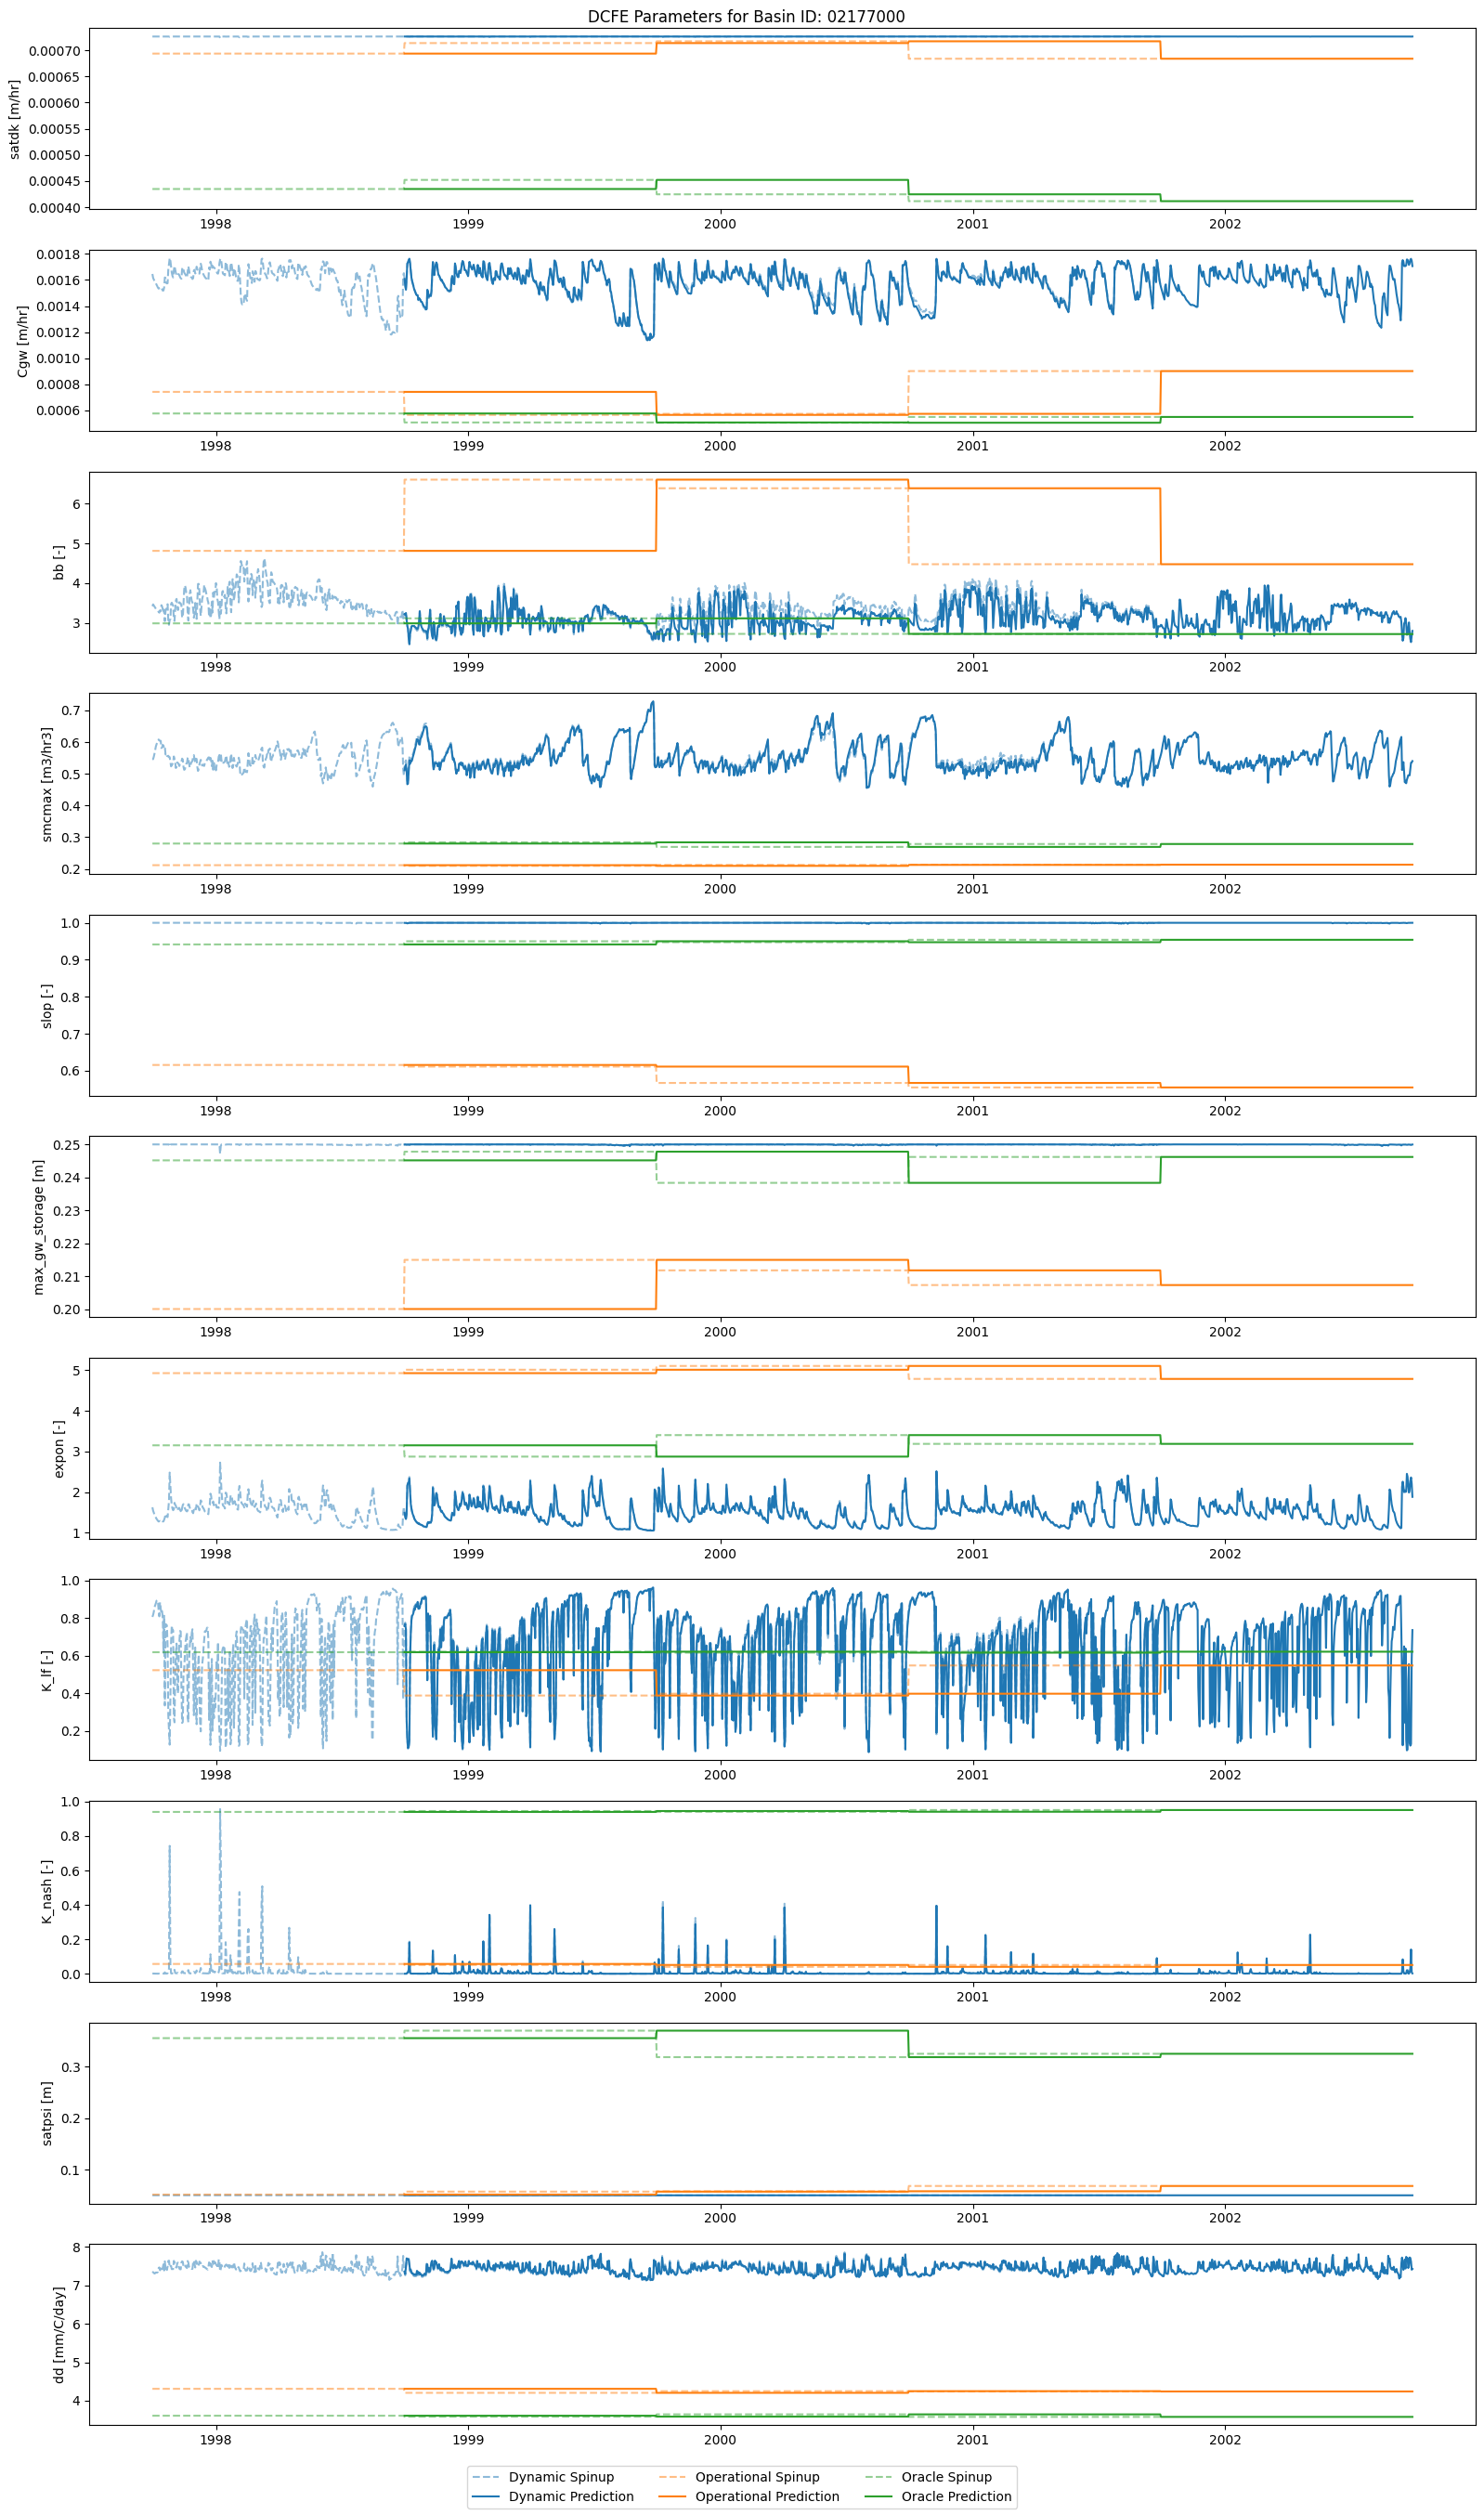

In [351]:
dcfe_param_unit_keys = ['[m/hr]', '[m/hr]', '[-]', '[m3/hr3]', '[-]', '[m]', '[-]', 
                        '[-]', '[-]', '[m]', '[mm/C/day]']
basin = '02177000'  # '02177000' #basin_keys[3]
dcfe_param_dates = full_dynamic_dcfe_all_results['datetime']

fig, ax = plt.subplots(figsize=(16,2.5*len(dcfe_param_keys)), nrows=len(dcfe_param_keys), ncols=1)
for i, param_interest in enumerate(dcfe_param_keys):
    label_dynamic_spinup = "Dynamic Spinup" if i == 0 else None
    label_dynamic_prediction = "Dynamic Prediction" if i == 0 else None
    label_operational_spinup = "Operational Spinup" if i == 0 else None
    label_operational_prediction = "Operational Prediction" if i == 0 else None
    label_oracle_spinup = "Oracle Spinup" if i == 0 else None
    label_oracle_prediction = "Oracle Prediction" if i == 0 else None
    ax[i].plot(dcfe_param_dates, full_dynamic_dcfe_all_results[basin]["spinup_parameters"][param_interest], 
               color="tab:blue", label=label_dynamic_spinup, linestyle='--', alpha = 0.5)
    ax[i].plot(dcfe_param_dates, full_dynamic_dcfe_all_results[basin]["prediction_parameters"][param_interest], 
               color="tab:blue", label=label_dynamic_prediction, linestyle='-')
    ax[i].plot(dcfe_param_dates, full_operational_dcfe_all_results[basin]["spinup_parameters"][param_interest],
               color="tab:orange", label=label_operational_spinup, linestyle='--', alpha = 0.5)
    ax[i].plot(dcfe_param_dates, full_operational_dcfe_all_results[basin]["prediction_parameters"][param_interest],
               color="tab:orange", label=label_operational_prediction, linestyle='-')
    ax[i].plot(dcfe_param_dates, full_oracle_dcfe_all_results[basin]["spinup_parameters"][param_interest],
               color="tab:green", label=label_oracle_spinup, linestyle='--', alpha = 0.5)
    ax[i].plot(dcfe_param_dates, full_oracle_dcfe_all_results[basin]["prediction_parameters"][param_interest],
               color="tab:green", label=label_oracle_prediction, linestyle='-')
    ax[i].set_ylabel(f"{param_interest} {dcfe_param_unit_keys[i]}")
fig.legend(loc="lower center", ncol=3)
fig.suptitle(f"DCFE Parameters for Basin ID: {basin}")
plt.tight_layout(rect=[0, 0.02, 1, 0.99])

In [366]:
dcfe_param_keys[10]

'dd'

### Internal States

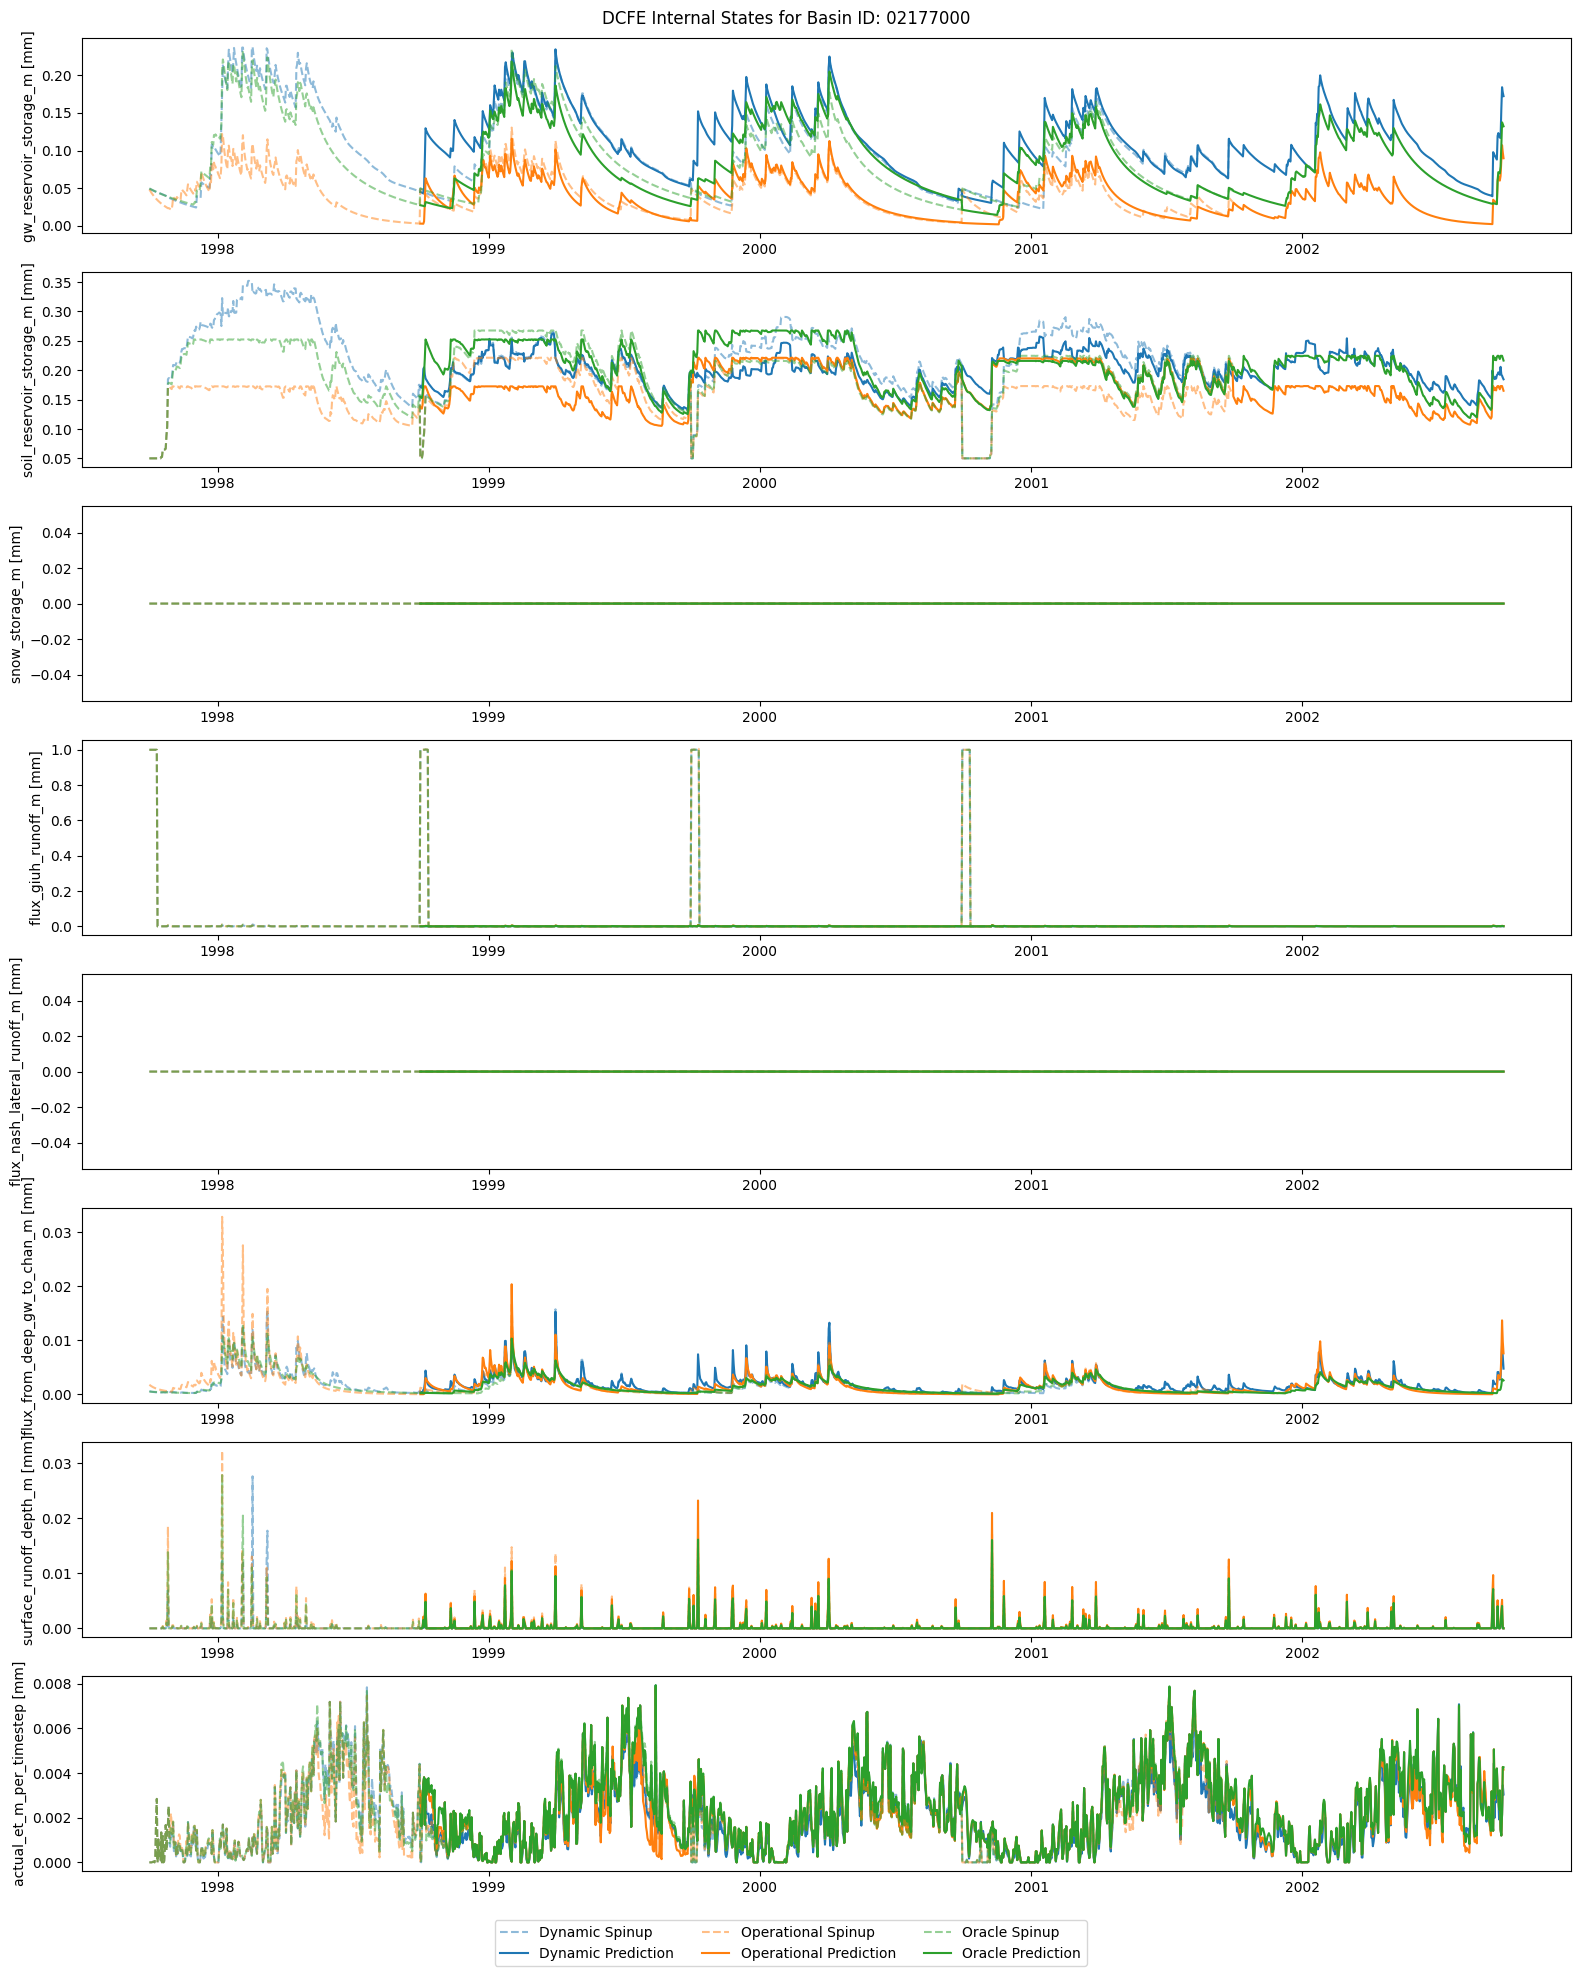

In [374]:
basin = '02177000' #basin_keys[3]
dcfe_state_dates =full_dynamic_dcfe_all_results['datetime']
fig, ax = plt.subplots(figsize=(16,2.5*len(dcfe_state_keys)), nrows=len(dcfe_state_keys), ncols=1)
for i, state_interest in enumerate(dcfe_state_keys):
    label_dynamic_spinup = "Dynamic Spinup" if i == 0 else None
    label_dynamic_prediction = "Dynamic Prediction" if i == 0 else None
    label_operational_spinup = "Operational Spinup" if i == 0 else None
    label_operational_prediction = "Operational Prediction" if i == 0 else None
    label_oracle_spinup = "Oracle Spinup" if i == 0 else None
    label_oracle_prediction = "Oracle Prediction" if i == 0 else None
    ax[i].plot(dcfe_state_dates, full_dynamic_dcfe_all_results[basin]["spinup_internal_states"][state_interest], 
               color="tab:blue", label=label_dynamic_spinup, linestyle='--', alpha = 0.5)
    ax[i].plot(dcfe_state_dates, full_dynamic_dcfe_all_results[basin]["prediction_internal_states"][state_interest], 
               color="tab:blue", label=label_dynamic_prediction, linestyle='-')
    ax[i].plot(dcfe_state_dates, full_operational_dcfe_all_results[basin]["spinup_internal_states"][state_interest],
               color="tab:orange", label=label_operational_spinup, linestyle='--', alpha = 0.5)
    ax[i].plot(dcfe_state_dates, full_operational_dcfe_all_results[basin]["prediction_internal_states"][state_interest],
               color="tab:orange", label=label_operational_prediction, linestyle='-')
    ax[i].plot(dcfe_state_dates, full_oracle_dcfe_all_results[basin]["spinup_internal_states"][state_interest],
               color="tab:green", label=label_oracle_spinup, linestyle='--', alpha = 0.5)
    ax[i].plot(dcfe_state_dates, full_oracle_dcfe_all_results[basin]["prediction_internal_states"][state_interest],
               color="tab:green", label=label_oracle_prediction, linestyle='-')
    ax[i].set_ylabel(f"{state_interest} [mm]")
fig.legend(loc="lower center", ncol=3)
fig.suptitle(f"DCFE Internal States for Basin ID: {basin}")
plt.tight_layout(rect=[0, 0.03, 1, 0.99])

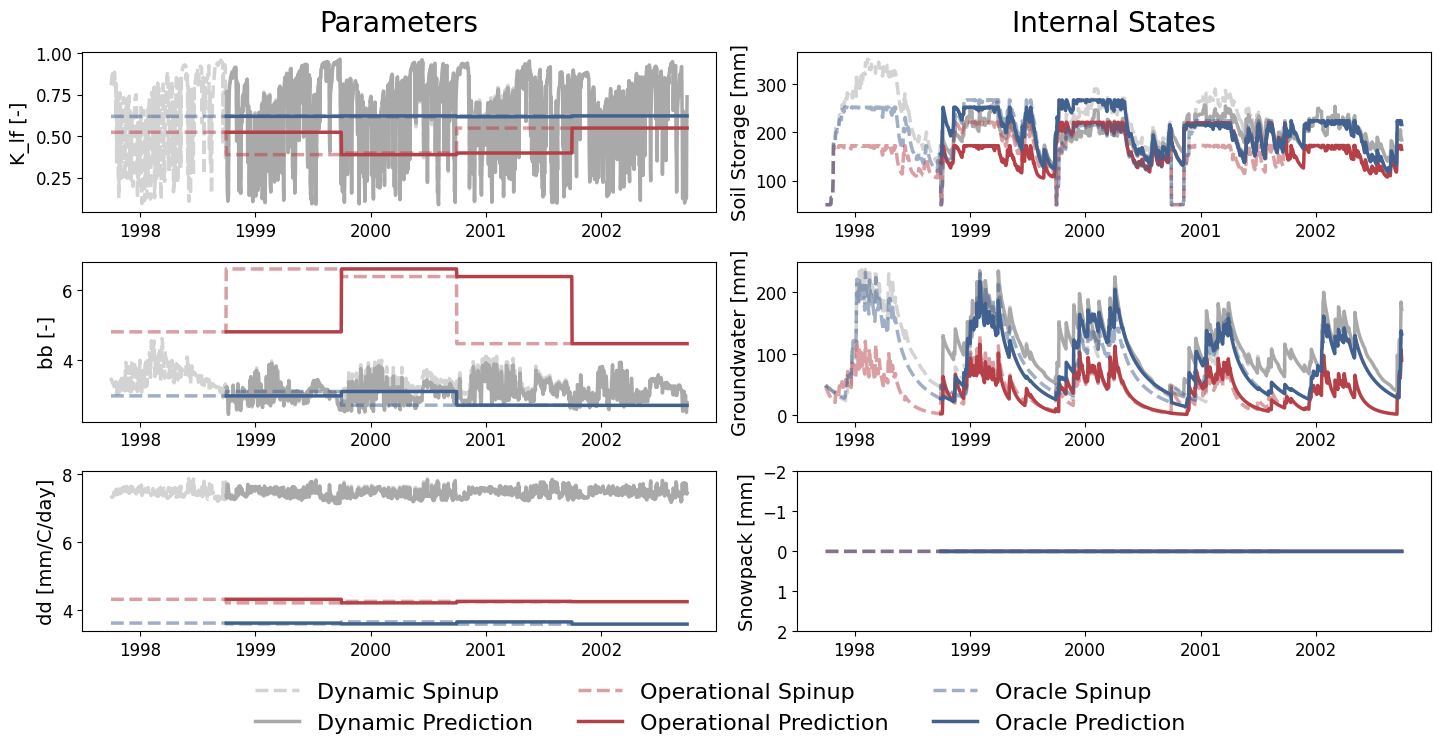

In [408]:
## Plotting EGU
brownish_red = '#B54048'
dark_blue = '#42618F'
teal = '#40B5AD'
a = 0.5
lwd = 2.5
label_dynamic_spinup = "Dynamic Spinup"
label_dynamic_prediction = "Dynamic Prediction"
label_operational_spinup = "Operational Spinup"
label_operational_prediction = "Operational Prediction"
label_oracle_spinup = "Oracle Spinup"
label_oracle_prediction = "Oracle Prediction"
    
j1 = 7
param_interest = dcfe_param_keys[j1]
fig, ax = plt.subplots(figsize=(16,8), nrows=3, ncols=2)
ax[0,0].plot(dcfe_param_dates, full_dynamic_dcfe_all_results[basin]["spinup_parameters"][param_interest], 
               color="darkgray", label=label_dynamic_spinup, linestyle='--', alpha = a, linewidth = lwd)
ax[0,0].plot(dcfe_param_dates, full_dynamic_dcfe_all_results[basin]["prediction_parameters"][param_interest], 
               color="darkgray", label=label_dynamic_prediction, linestyle='-', linewidth = lwd)
ax[0,0].plot(dcfe_param_dates, full_operational_dcfe_all_results[basin]["spinup_parameters"][param_interest],
               color=brownish_red, label=label_operational_spinup, linestyle='--', alpha = a, linewidth = lwd)
ax[0,0].plot(dcfe_param_dates, full_operational_dcfe_all_results[basin]["prediction_parameters"][param_interest],
               color=brownish_red, label=label_operational_prediction, linestyle='-', linewidth = lwd)
ax[0,0].plot(dcfe_param_dates, full_oracle_dcfe_all_results[basin]["spinup_parameters"][param_interest],
               color=dark_blue, label=label_oracle_spinup, linestyle='--', alpha = a, linewidth = lwd)
ax[0,0].plot(dcfe_param_dates, full_oracle_dcfe_all_results[basin]["prediction_parameters"][param_interest],
               color=dark_blue, label=label_oracle_prediction, linestyle='-', linewidth = lwd)
ax[0,0].set_ylabel(f"{param_interest} {dcfe_param_unit_keys[j1]}")

j2 = 2
param_interest = dcfe_param_keys[j2]
ax[1,0].plot(dcfe_param_dates, full_dynamic_dcfe_all_results[basin]["spinup_parameters"][param_interest], 
               color="darkgray", linestyle='--', alpha = a, linewidth = lwd)
ax[1,0].plot(dcfe_param_dates, full_dynamic_dcfe_all_results[basin]["prediction_parameters"][param_interest], 
               color="darkgray", linestyle='-', linewidth = lwd)
ax[1,0].plot(dcfe_param_dates, full_operational_dcfe_all_results[basin]["spinup_parameters"][param_interest],
               color=brownish_red, linestyle='--', alpha = a, linewidth = lwd)
ax[1,0].plot(dcfe_param_dates, full_operational_dcfe_all_results[basin]["prediction_parameters"][param_interest],
               color=brownish_red, linestyle='-', linewidth = lwd)
ax[1,0].plot(dcfe_param_dates, full_oracle_dcfe_all_results[basin]["spinup_parameters"][param_interest],
               color=dark_blue, linestyle='--', alpha = a, linewidth = lwd)
ax[1,0].plot(dcfe_param_dates, full_oracle_dcfe_all_results[basin]["prediction_parameters"][param_interest],
               color=dark_blue, linestyle='-', linewidth = lwd)
ax[1,0].set_ylabel(f"{param_interest} {dcfe_param_unit_keys[j2]}")

j3 = 10
param_interest = dcfe_param_keys[j3]
ax[2,0].plot(dcfe_param_dates, full_dynamic_dcfe_all_results[basin]["spinup_parameters"][param_interest], 
               color="darkgray", linestyle='--', alpha = a, linewidth = lwd)
ax[2,0].plot(dcfe_param_dates, full_dynamic_dcfe_all_results[basin]["prediction_parameters"][param_interest], 
               color="darkgray", linestyle='-', linewidth = lwd)
ax[2,0].plot(dcfe_param_dates, full_operational_dcfe_all_results[basin]["spinup_parameters"][param_interest],
               color=brownish_red, linestyle='--', alpha = a, linewidth = lwd)
ax[2,0].plot(dcfe_param_dates, full_operational_dcfe_all_results[basin]["prediction_parameters"][param_interest],
               color=brownish_red, linestyle='-', linewidth = lwd)
ax[2,0].plot(dcfe_param_dates, full_oracle_dcfe_all_results[basin]["spinup_parameters"][param_interest],
               color=dark_blue, linestyle='--', alpha = a, linewidth = lwd)
ax[2,0].plot(dcfe_param_dates, full_oracle_dcfe_all_results[basin]["prediction_parameters"][param_interest],
               color=dark_blue, linestyle='-', linewidth = lwd)
ax[2,0].set_ylabel(f"{param_interest} {dcfe_param_unit_keys[j3]}")

k1 = 1
state_interest = dcfe_state_keys[k1]
ax[0,1].plot(dcfe_state_dates, full_dynamic_dcfe_all_results[basin]["spinup_internal_states"][state_interest] * 1000, 
               color="darkgray", linestyle='--', alpha = a, linewidth = lwd)
ax[0,1].plot(dcfe_state_dates, full_dynamic_dcfe_all_results[basin]["prediction_internal_states"][state_interest] * 1000, 
               color="darkgray", linestyle='-', linewidth = lwd)
ax[0,1].plot(dcfe_state_dates, full_operational_dcfe_all_results[basin]["spinup_internal_states"][state_interest] * 1000,
               color=brownish_red, linestyle='--', alpha = a, linewidth = lwd)
ax[0,1].plot(dcfe_state_dates, full_operational_dcfe_all_results[basin]["prediction_internal_states"][state_interest] * 1000,
               color=brownish_red, linestyle='-', linewidth = lwd)
ax[0,1].plot(dcfe_state_dates, full_oracle_dcfe_all_results[basin]["spinup_internal_states"][state_interest] * 1000,
               color=dark_blue, linestyle='--', alpha = a, linewidth = lwd)
ax[0,1].plot(dcfe_state_dates, full_oracle_dcfe_all_results[basin]["prediction_internal_states"][state_interest] * 1000,
               color=dark_blue, linestyle='-', linewidth = lwd)
ax[0,1].set_ylabel("Soil Storage [mm]")

k2 = 0
state_interest = dcfe_state_keys[k2]
ax[1,1].plot(dcfe_state_dates, full_dynamic_dcfe_all_results[basin]["spinup_internal_states"][state_interest] * 1000, 
               color="darkgray", linestyle='--', alpha = a, linewidth = lwd)
ax[1,1].plot(dcfe_state_dates, full_dynamic_dcfe_all_results[basin]["prediction_internal_states"][state_interest] * 1000, 
               color="darkgray",  linestyle='-', linewidth = lwd)
ax[1,1].plot(dcfe_state_dates, full_operational_dcfe_all_results[basin]["spinup_internal_states"][state_interest] * 1000,
               color=brownish_red, linestyle='--', alpha = a, linewidth = lwd)
ax[1,1].plot(dcfe_state_dates, full_operational_dcfe_all_results[basin]["prediction_internal_states"][state_interest] * 1000,
               color=brownish_red, linestyle='-', linewidth = lwd)
ax[1,1].plot(dcfe_state_dates, full_oracle_dcfe_all_results[basin]["spinup_internal_states"][state_interest] * 1000,
               color=dark_blue, linestyle='--', alpha = a, linewidth = lwd)
ax[1,1].plot(dcfe_state_dates, full_oracle_dcfe_all_results[basin]["prediction_internal_states"][state_interest] * 1000,
               color=dark_blue, linestyle='-', linewidth = lwd)
ax[1,1].set_ylabel("Groundwater [mm]")

k3 = 2
state_interest = dcfe_state_keys[k3]
ax[2,1].plot(dcfe_state_dates, full_dynamic_dcfe_all_results[basin]["spinup_internal_states"][state_interest] * 1000, 
               color="darkgray", linestyle='--', alpha = a, linewidth = lwd)
ax[2,1].plot(dcfe_state_dates, full_dynamic_dcfe_all_results[basin]["prediction_internal_states"][state_interest] * 1000, 
               color="darkgray", linestyle='-', linewidth = lwd)
ax[2,1].plot(dcfe_state_dates, full_operational_dcfe_all_results[basin]["spinup_internal_states"][state_interest] * 1000,
               color=brownish_red, linestyle='--', alpha = a, linewidth = lwd)
ax[2,1].plot(dcfe_state_dates, full_operational_dcfe_all_results[basin]["prediction_internal_states"][state_interest] * 1000,
               color=brownish_red, linestyle='-', linewidth = lwd)
ax[2,1].plot(dcfe_state_dates, full_oracle_dcfe_all_results[basin]["spinup_internal_states"][state_interest] * 1000,
               color=dark_blue, linestyle='--', alpha = a, linewidth = lwd)
ax[2,1].plot(dcfe_state_dates, full_oracle_dcfe_all_results[basin]["prediction_internal_states"][state_interest] * 1000,
               color=dark_blue, linestyle='-', linewidth = lwd)
ax[2,1].set_ylim(2, -2)
ax[2,1].set_ylabel("Snowpack [mm]")

ax[0,0].set_title("Parameters", fontsize=20, pad=15)
ax[0,1].set_title("Internal States", fontsize=20, pad=15)

for a in ax.flat:
    a.set_xlabel(a.get_xlabel(), fontsize=14)
    a.set_ylabel(a.get_ylabel(), fontsize=14)
    a.tick_params(axis='both', labelsize=12)
    
fig.legend(loc="lower center", ncol=3, fontsize = 16, frameon = False)
plt.tight_layout(rect=[0, 0.1, 0.9, 0.95]) 

plt.savefig(r"/Users/ziyu/Library/CloudStorage/OneDrive-ColoradoSchoolofMines/Documents/College/ResearchStuff/NextGen/Conference/EGU2026/Poster/Images/Parameter_States.pdf",
            bbox_inches="tight")

# Comparison to Parameters from Araki

In [ ]:
from pathlib import Path
import pickle

import matplotlib.pyplot as plt
import numpy as np
import torch
import xarray as xr
from torch.utils.data import DataLoader

from pathlib import Path
from neuralhydrology.utils.config import Config
from neuralhydrology.evaluation.tester import BaseTester
from torch.utils.data import DataLoader
from neuralhydrology.evaluation.metrics import nse

In [ ]:
run_dir = Path("runs/noSnow_basin_dcfe_operational_2704_135841")
with open(run_dir / "test" / "model_epoch030" / "test_results.p", "rb") as fp:
    noSnow_dcfe_operational_result = pickle.load(fp)
    
cfg = Config(run_dir / "analysis_config.yml")

tester = BaseTester(cfg=cfg, run_dir=run_dir, period="test")

data_by_basin = {}

for basin in tester.basins:
    ds = tester._get_dataset(basin)

    loader = DataLoader(
        ds,
        batch_size=tester.cfg.batch_size,
        num_workers=0,
        collate_fn=ds.collate_fn
    )

    data_by_basin[basin] = list(loader)

noSnow_basins = tester.basins

## Compare all of noSnow

In [ ]:
from neuralhydrology.modelzoo.cfe_modules.cfe_dataclasses import ( 
    GroundwaterStates, 
    RoutingInfo, SoilConfig, 
    SoilStates, 
    get_constants, 
    ) 
from neuralhydrology.modelzoo.cfe_modules.get_default_params import get_default_params 
from neuralhydrology.modelzoo.cfe_modules.timestep_cfe import timestep_cfe

In [ ]:
rows = []

for basin in noSnow_basins:
    
    dates_noSnow_test = np.hstack([
        data_by_basin[basin][0]['date'][0, -730:],
        data_by_basin[basin][0]['date'][365*2, -730:],
        data_by_basin[basin][0]['date'][365*3, -365:]
    ])
    precip_noSnow_test = np.hstack([
        data_by_basin[basin][0]['x_d']['PRCP(mm/day)_nldas_copy1'][0, -730:, 0],
        data_by_basin[basin][0]['x_d']['PRCP(mm/day)_nldas_copy1'][365*2, -730:, 0],
        data_by_basin[basin][0]['x_d']['PRCP(mm/day)_nldas_copy1'][365*3, -365:, 0]
    ])
    srad_noSnow_test = np.hstack([
        data_by_basin[basin][0]['x_d']['SRAD(W/m2)_nldas_copy1'][0, -730:, 0],
        data_by_basin[basin][0]['x_d']['SRAD(W/m2)_nldas_copy1'][365*2, -730:, 0],
        data_by_basin[basin][0]['x_d']['SRAD(W/m2)_nldas_copy1'][365*3, -365:, 0]
    ])
    tmin_noSnow_test = np.hstack([
        data_by_basin[basin][0]['x_d']['Tmin(C)_nldas_copy1'][0, -730:, 0],
        data_by_basin[basin][0]['x_d']['Tmin(C)_nldas_copy1'][365*2, -730:, 0],
        data_by_basin[basin][0]['x_d']['Tmin(C)_nldas_copy1'][365*3, -365:, 0]
    ])
    tmax_noSnow_test = np.hstack([
        data_by_basin[basin][0]['x_d']['Tmax(C)_nldas_copy1'][0, -730:, 0],
        data_by_basin[basin][0]['x_d']['Tmax(C)_nldas_copy1'][365*2, -730:, 0],
        data_by_basin[basin][0]['x_d']['Tmax(C)_nldas_copy1'][365*3, -365:, 0]
    ])
    forcing_noSnow_test = torch.tensor(
        np.stack([
            precip_noSnow_test,
            srad_noSnow_test,
            tmin_noSnow_test,
            tmax_noSnow_test
        ], axis=-1),
        dtype=torch.float32
    ) # time x forcing

    device = cfg.device
    batch_size = len(data_by_basin[basin][0]['static_conceptual_params']['bb'])
    T, F = forcing_noSnow_test.shape
    forcing_noSnow_ready = torch.zeros((batch_size, T, F), dtype=torch.float32, device=device)
    forcing_noSnow_ready[0] = forcing_noSnow_test
    
    # run CFE
    cfe_params = get_default_params(cfg, data_by_basin[basin][0]['static_conceptual_params'], device)
    constants = get_constants(cfg.dcfe_hourly)

    # initialize model states/reservoirs.
    gw_reservoir = GroundwaterStates(device=device, batch_size=batch_size, cfe_params=cfe_params)
    soil_config = SoilConfig(cfe_params=cfe_params, device=device, batch_size=batch_size, constants=constants)
    soil_reservoir = SoilStates(
        device=device,
        batch_size=batch_size,
        cfe_params=cfe_params,
        soil_config=soil_config,
        constants=constants,
    )
    routing_info = RoutingInfo(device=device, batch_size=batch_size, cfe_params=cfe_params)

    # empty vector to store output
    Discharge = torch.zeros(forcing_noSnow_ready.shape[1], 8)
    
    for i in range(forcing_noSnow_ready.shape[1]):
        cfe_params, gw_reservoir, soil_reservoir, routing_info, flux = timestep_cfe(
            x_conceptual_timestep=forcing_noSnow_ready[:, i, :],
            cfe_params=cfe_params,
            timestep_params=None,
            gw_reservoir=gw_reservoir,
            soil_reservoir=soil_reservoir,
            soil_config=soil_config,
            routing_info=routing_info,
            constants=constants,
        )
    
        Discharge[i, 0] = flux.Qout_m[0]  # total discharge
        Discharge[i, 1] = flux.giuh_runoff_m[0]
        Discharge[i, 2] = flux.nash_lateral_runoff_m[0]
        Discharge[i, 3] = flux.from_deep_gw_to_chan_m[0]
        Discharge[i, 4] = flux.surface_runoff_depth_m[0]
        Discharge[i, 5] = flux.actual_et_m_per_timestep[0]  # total ET
        Discharge[i, 6] = soil_reservoir.storage_m[0]  # soil water storage
        Discharge[i, 7] = gw_reservoir.storage_m[0]  # gw storage
    
    
    obs_runoff_temp = noSnow_dcfe_operational_result[basin]['1D']['xr']['QObs(mm/d)_obs']
    sim_operational_temp = noSnow_dcfe_operational_result[basin]['1D']['xr']['QObs(mm/d)_sim']
    
    sim_araki_temp = xr.DataArray(
        Discharge[365:, 0].detach().cpu().numpy() * 1000,
        coords=obs_runoff_temp.coords,
        dims=obs_runoff_temp.dims,
    )
    
    # compute NSEs
    nse_operational = nse(obs_runoff_temp, sim_operational_temp)
    nse_araki = nse(obs_runoff_temp, sim_araki_temp)

    rows.append({
        "basin": basin,
        "araki nse": nse_araki,
        "operational nse": nse_operational
    })

noSnow_metrics = pd.DataFrame(rows)

## Individual Runoff Comparison

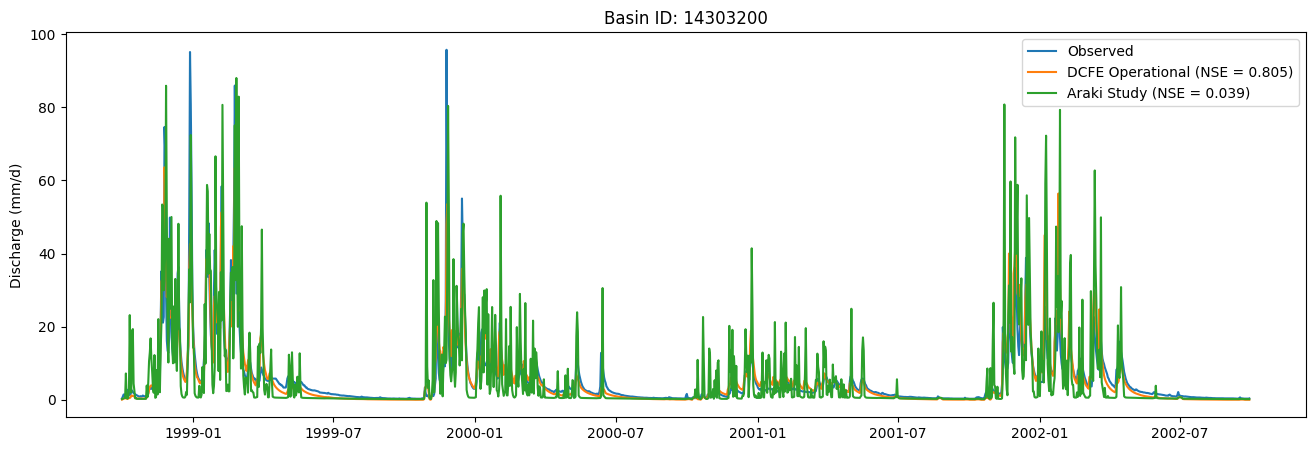

In [315]:
i1 = 103 #103, 23 Basins where dcfe better
basin_id = noSnow_basins[i1] 
dates_noSnow_test = np.hstack([
    data_by_basin[basin_id][0]['date'][0, -730:],
    data_by_basin[basin_id][0]['date'][365*2, -730:],
    data_by_basin[basin_id][0]['date'][365*3, -365:]
])
precip_noSnow_test = np.hstack([
    data_by_basin[basin_id][0]['x_d']['PRCP(mm/day)_nldas_copy1'][0, -730:, 0],
    data_by_basin[basin_id][0]['x_d']['PRCP(mm/day)_nldas_copy1'][365*2, -730:, 0],
    data_by_basin[basin_id][0]['x_d']['PRCP(mm/day)_nldas_copy1'][365*3, -365:, 0]
])
srad_noSnow_test = np.hstack([
    data_by_basin[basin_id][0]['x_d']['SRAD(W/m2)_nldas_copy1'][0, -730:, 0],
    data_by_basin[basin_id][0]['x_d']['SRAD(W/m2)_nldas_copy1'][365*2, -730:, 0],
    data_by_basin[basin_id][0]['x_d']['SRAD(W/m2)_nldas_copy1'][365*3, -365:, 0]
])
tmin_noSnow_test = np.hstack([
    data_by_basin[basin_id][0]['x_d']['Tmin(C)_nldas_copy1'][0, -730:, 0],
    data_by_basin[basin_id][0]['x_d']['Tmin(C)_nldas_copy1'][365*2, -730:, 0],
    data_by_basin[basin_id][0]['x_d']['Tmin(C)_nldas_copy1'][365*3, -365:, 0]
])
tmax_noSnow_test = np.hstack([
    data_by_basin[basin_id][0]['x_d']['Tmax(C)_nldas_copy1'][0, -730:, 0],
    data_by_basin[basin_id][0]['x_d']['Tmax(C)_nldas_copy1'][365*2, -730:, 0],
    data_by_basin[basin_id][0]['x_d']['Tmax(C)_nldas_copy1'][365*3, -365:, 0]
])
forcing_noSnow_test = torch.tensor(
    np.stack([
        precip_noSnow_test,
        srad_noSnow_test,
        tmin_noSnow_test,
        tmax_noSnow_test
    ], axis=-1),
    dtype=torch.float32
) # time x forcing

device = cfg.device
batch_size = len(data_by_basin[basin_id][0]['static_conceptual_params']['bb'])

T, F = forcing_noSnow_test.shape

forcing_noSnow_ready = torch.zeros((batch_size, T, F), dtype=torch.float32, device=device)
forcing_noSnow_ready[0] = forcing_noSnow_test

cfe_params = get_default_params(cfg, data_by_basin[basin_id][0]['static_conceptual_params'], device)
constants = get_constants(cfg.dcfe_hourly)

# initialize model states/reservoirs.
gw_reservoir = GroundwaterStates(device=device, batch_size=batch_size, cfe_params=cfe_params)
soil_config = SoilConfig(cfe_params=cfe_params, device=device, batch_size=batch_size, constants=constants)
soil_reservoir = SoilStates(
    device=device,
    batch_size=batch_size,
    cfe_params=cfe_params,
    soil_config=soil_config,
    constants=constants,
)
routing_info = RoutingInfo(device=device, batch_size=batch_size, cfe_params=cfe_params)

# empty vector to store output
Discharge = torch.zeros(forcing_noSnow_ready.shape[1], 8)
    
for i in range(forcing_noSnow_ready.shape[1]):
    cfe_params, gw_reservoir, soil_reservoir, routing_info, flux = timestep_cfe(
        x_conceptual_timestep=forcing_noSnow_ready[:, i, :],
        cfe_params=cfe_params,
        timestep_params=None,
        gw_reservoir=gw_reservoir,
        soil_reservoir=soil_reservoir,
        soil_config=soil_config,
        routing_info=routing_info,
        constants=constants,
    )
    
    Discharge[i, 0] = flux.Qout_m[0]  # total discharge
    Discharge[i, 1] = flux.giuh_runoff_m[0]
    Discharge[i, 2] = flux.nash_lateral_runoff_m[0]
    Discharge[i, 3] = flux.from_deep_gw_to_chan_m[0]
    Discharge[i, 4] = flux.surface_runoff_depth_m[0]
    Discharge[i, 5] = flux.actual_et_m_per_timestep[0]  # total ET
    Discharge[i, 6] = soil_reservoir.storage_m[0]  # soil water storage
    Discharge[i, 7] = gw_reservoir.storage_m[0]  # gw storage

plotting_basin_1 = basin_id
date_plotting_1 = noSnow_dcfe_operational_result[basin_id]['1D']['xr'].datetime
observed_runoff_1 = noSnow_dcfe_operational_result[basin_id]['1D']['xr']['QObs(mm/d)_obs']
simulated_operational_1 = noSnow_dcfe_operational_result[basin_id]['1D']['xr']['QObs(mm/d)_sim']
nse_operational_1 = nse(observed_runoff_1, simulated_operational_1)
simulated_araki_1 = xr.DataArray(
    Discharge[365:, 0].detach().cpu().numpy() * 1000,
    coords=observed_runoff_1.coords,
    dims=observed_runoff_1.dims,
)
nse_araki_1 = nse(observed_runoff_1, simulated_araki_1)

fig, ax = plt.subplots(figsize=(16,5))
ax.plot(date_plotting_1, observed_runoff_1, label='Observed')
ax.plot(date_plotting_1, simulated_operational_1, label=f'DCFE Operational (NSE = {nse_operational_1:.3f})')
ax.plot(date_plotting_1, simulated_araki_1, label=f'Araki Study (NSE = {nse_araki_1:.3f})')
ax.set_ylabel("Discharge (mm/d)")
ax.set_title(f"Basin ID: {plotting_basin_1}")
ax.legend()

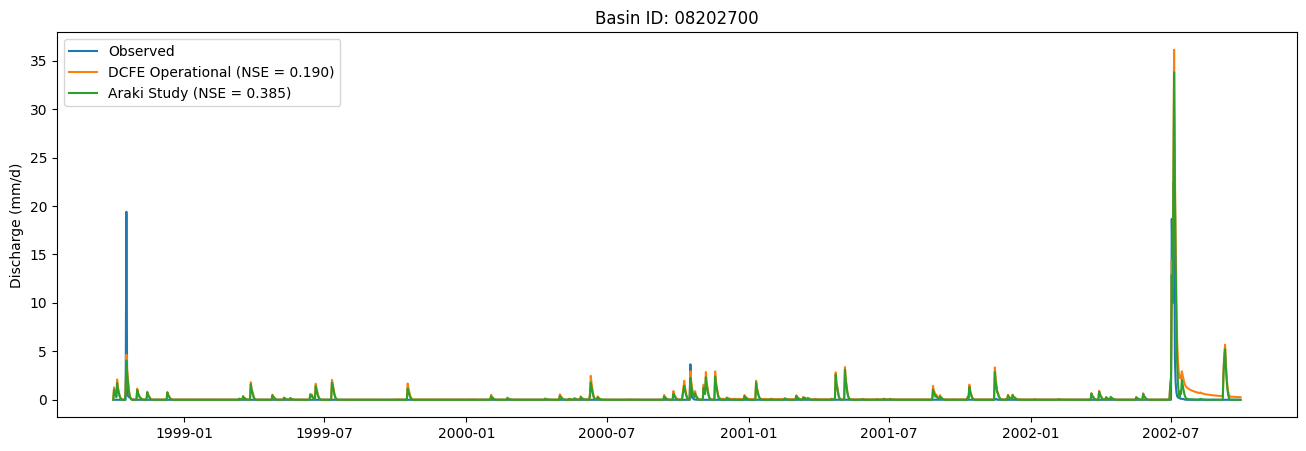

In [335]:
i2 = 75 #33, 45, 50, 53, 65, 71, 72, 75, Where araki is better
basin_id = noSnow_basins[i2] 
dates_noSnow_test = np.hstack([
    data_by_basin[basin_id][0]['date'][0, -730:],
    data_by_basin[basin_id][0]['date'][365*2, -730:],
    data_by_basin[basin_id][0]['date'][365*3, -365:]
])
precip_noSnow_test = np.hstack([
    data_by_basin[basin_id][0]['x_d']['PRCP(mm/day)_nldas_copy1'][0, -730:, 0],
    data_by_basin[basin_id][0]['x_d']['PRCP(mm/day)_nldas_copy1'][365*2, -730:, 0],
    data_by_basin[basin_id][0]['x_d']['PRCP(mm/day)_nldas_copy1'][365*3, -365:, 0]
])
srad_noSnow_test = np.hstack([
    data_by_basin[basin_id][0]['x_d']['SRAD(W/m2)_nldas_copy1'][0, -730:, 0],
    data_by_basin[basin_id][0]['x_d']['SRAD(W/m2)_nldas_copy1'][365*2, -730:, 0],
    data_by_basin[basin_id][0]['x_d']['SRAD(W/m2)_nldas_copy1'][365*3, -365:, 0]
])
tmin_noSnow_test = np.hstack([
    data_by_basin[basin_id][0]['x_d']['Tmin(C)_nldas_copy1'][0, -730:, 0],
    data_by_basin[basin_id][0]['x_d']['Tmin(C)_nldas_copy1'][365*2, -730:, 0],
    data_by_basin[basin_id][0]['x_d']['Tmin(C)_nldas_copy1'][365*3, -365:, 0]
])
tmax_noSnow_test = np.hstack([
    data_by_basin[basin_id][0]['x_d']['Tmax(C)_nldas_copy1'][0, -730:, 0],
    data_by_basin[basin_id][0]['x_d']['Tmax(C)_nldas_copy1'][365*2, -730:, 0],
    data_by_basin[basin_id][0]['x_d']['Tmax(C)_nldas_copy1'][365*3, -365:, 0]
])
forcing_noSnow_test = torch.tensor(
    np.stack([
        precip_noSnow_test,
        srad_noSnow_test,
        tmin_noSnow_test,
        tmax_noSnow_test
    ], axis=-1),
    dtype=torch.float32
) # time x forcing

device = cfg.device
batch_size = len(data_by_basin[basin_id][0]['static_conceptual_params']['bb'])

T, F = forcing_noSnow_test.shape

forcing_noSnow_ready = torch.zeros((batch_size, T, F), dtype=torch.float32, device=device)
forcing_noSnow_ready[0] = forcing_noSnow_test

cfe_params = get_default_params(cfg, data_by_basin[basin_id][0]['static_conceptual_params'], device)
constants = get_constants(cfg.dcfe_hourly)

# initialize model states/reservoirs.
gw_reservoir = GroundwaterStates(device=device, batch_size=batch_size, cfe_params=cfe_params)
soil_config = SoilConfig(cfe_params=cfe_params, device=device, batch_size=batch_size, constants=constants)
soil_reservoir = SoilStates(
    device=device,
    batch_size=batch_size,
    cfe_params=cfe_params,
    soil_config=soil_config,
    constants=constants,
)
routing_info = RoutingInfo(device=device, batch_size=batch_size, cfe_params=cfe_params)

# empty vector to store output
Discharge = torch.zeros(forcing_noSnow_ready.shape[1], 8)
    
for i in range(forcing_noSnow_ready.shape[1]):
    cfe_params, gw_reservoir, soil_reservoir, routing_info, flux = timestep_cfe(
        x_conceptual_timestep=forcing_noSnow_ready[:, i, :],
        cfe_params=cfe_params,
        timestep_params=None,
        gw_reservoir=gw_reservoir,
        soil_reservoir=soil_reservoir,
        soil_config=soil_config,
        routing_info=routing_info,
        constants=constants,
    )
    
    Discharge[i, 0] = flux.Qout_m[0]  # total discharge
    Discharge[i, 1] = flux.giuh_runoff_m[0]
    Discharge[i, 2] = flux.nash_lateral_runoff_m[0]
    Discharge[i, 3] = flux.from_deep_gw_to_chan_m[0]
    Discharge[i, 4] = flux.surface_runoff_depth_m[0]
    Discharge[i, 5] = flux.actual_et_m_per_timestep[0]  # total ET
    Discharge[i, 6] = soil_reservoir.storage_m[0]  # soil water storage
    Discharge[i, 7] = gw_reservoir.storage_m[0]  # gw storage

plotting_basin_2 = basin_id
date_plotting_2 = noSnow_dcfe_operational_result[basin_id]['1D']['xr'].datetime
observed_runoff_2 = noSnow_dcfe_operational_result[basin_id]['1D']['xr']['QObs(mm/d)_obs']
simulated_operational_2 = noSnow_dcfe_operational_result[basin_id]['1D']['xr']['QObs(mm/d)_sim']
nse_operational_2 = nse(observed_runoff_2, simulated_operational_2)
simulated_araki_2 = xr.DataArray(
    Discharge[365:, 0].detach().cpu().numpy() * 1000,
    coords=observed_runoff_2.coords,
    dims=observed_runoff_2.dims,
)
nse_araki_2 = nse(observed_runoff_2, simulated_araki_2)

fig, ax = plt.subplots(figsize=(16,5))
ax.plot(date_plotting_2, observed_runoff_2, label='Observed')
ax.plot(date_plotting_2, simulated_operational_2, label=f'DCFE Operational (NSE = {nse_operational_2:.3f})')
ax.plot(date_plotting_2, simulated_araki_2, label=f'Araki Study (NSE = {nse_araki_2:.3f})')
ax.set_ylabel("Discharge (mm/d)")
ax.set_title(f"Basin ID: {plotting_basin_2}")
ax.legend()

/var/folders/s8/cykprlyd0fs_zdnnd5zv0wdr0000gn/T/ipykernel_58027/722642383.py:70: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout(rect=[0, 0.075, 0.9, 0.9])


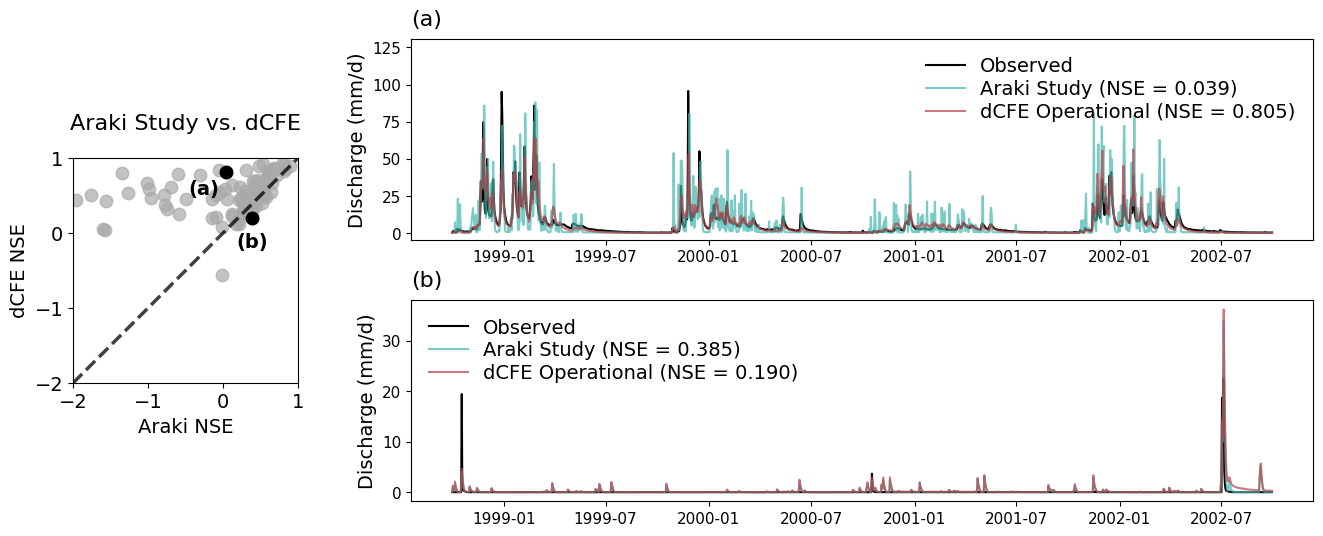

In [417]:
# DO NOT RUN, EGU Graphics

a = 0.7
lwd = 2.5
lwd_line = 1.5
brownish_red = '#B54048'
dark_blue = '#42618F'
teal = '#40B5AD'

fig = plt.figure(figsize=(16,6))
gs = fig.add_gridspec(2, 2, width_ratios=[1, 4], hspace=0.3)

ax_left = fig.add_subplot(gs[:, 0])   # spans both rows
ax_top = fig.add_subplot(gs[0, 1])    # top right
ax_bottom = fig.add_subplot(gs[1, 1]) # bottom right

ax_left.plot(noSnow_metrics['araki nse'], noSnow_metrics['operational nse'], 'o',
             markersize = 9, alpha = a, color = "darkgray")
# fist dot that shows dcfe better
x1 = noSnow_metrics['araki nse'].iloc[i1]
y1 = noSnow_metrics['operational nse'].iloc[i1]
# highlight it
ax_left.plot(x1, y1, 'o', color='black', markersize=9, zorder=10)
# label it "(a)"
ax_left.annotate('(a)', (x1, y1),
                 xytext=(-5, -5), textcoords='offset points',
                 fontsize=14, weight='bold',
                 ha='right', va='top')
# 2nd dot thst shows araki better
x2 = noSnow_metrics['araki nse'].iloc[i2]
y2 = noSnow_metrics['operational nse'].iloc[i2]
ax_left.plot(x2, y2, 'o', color='black', markersize=9, zorder=10)
ax_left.annotate('(b)', (x2, y2),
                 xytext=(0, -10), textcoords='offset points',
                 fontsize=14, weight='bold',
                 ha='center', va='top')
ax_left.set_xlabel("Araki NSE", fontsize = 14)
ax_left.set_ylabel("dCFE NSE", fontsize = 14)
ax_left.set_aspect('equal')
ax_left.set_xlim(-2, 1)
ax_left.set_ylim(-2, 1)
ax_left.set_title("Araki Study vs. dCFE", fontsize = 16, pad = 20)
ax_left.tick_params(axis='both', labelsize=14)
ax_left.plot((-2, 1),(-2,1),'k--', alpha=0.75, zorder=5, linewidth = 2.5)

ax_top.plot(date_plotting_1, observed_runoff_1, label='Observed', color = "black", linewidth = lwd_line)
ax_top.plot(date_plotting_1, simulated_araki_1, color = teal, alpha = a, linewidth = lwd_line,
            label=f'Araki Study (NSE = {nse_araki_1:.3f})')
ax_top.plot(date_plotting_1, simulated_operational_1, color = brownish_red, alpha = a, linewidth = lwd_line,
            label=f'dCFE Operational (NSE = {nse_operational_1:.3f})')
ax_top.set_ylabel("Discharge (mm/d)", fontsize = 14)
ymin, ymax = ax_top.get_ylim()
ax_top.set_ylim(ymin, ymax + 30)
#ax_top.set_title(f"Basin ID: {plotting_basin_1}")
ax_top.set_title("(a)", loc='left', fontsize = 16, pad=10)
ax_top.tick_params(axis='both', labelsize=11)
ax_top.legend(fontsize=14, frameon=False, loc='upper right', labelspacing=0.2)

ax_bottom.plot(date_plotting_2, observed_runoff_2, label='Observed', color = "black", linewidth = lwd_line)
ax_bottom.plot(date_plotting_2, simulated_araki_2, color = teal, alpha = a, linewidth = lwd_line,
               label=f'Araki Study (NSE = {nse_araki_2:.3f})')
ax_bottom.plot(date_plotting_2, simulated_operational_2, color = brownish_red, alpha = a, linewidth = lwd_line,
               label=f'dCFE Operational (NSE = {nse_operational_2:.3f})')
ax_bottom.set_ylabel("Discharge (mm/d)", fontsize = 14)
#ax_bottom.set_title(f"Basin ID: {plotting_basin_2}")
ax_bottom.set_title("(b)", loc='left', fontsize = 16, pad=10)
ax_bottom.tick_params(axis='both', labelsize=11)
ax_bottom.legend(fontsize=14, frameon=False, labelspacing=0.2)

plt.tight_layout(rect=[0, 0.075, 0.9, 0.9])
plt.savefig(r"/Users/ziyu/Library/CloudStorage/OneDrive-ColoradoSchoolofMines/Documents/College/ResearchStuff/NextGen/Conference/EGU2026/Poster/Images/Araki_Comparison.pdf",
            bbox_inches="tight")